# Bay of Bengal Mixed Layer Depth: Complete Analysis

Long-term variability and physical drivers of MLD in the Bay of Bengal, 1993–2020.

**Objectives**
1. Spatial, seasonal, interannual and long-term structure of MLD
2. Contribution of wind stress, Ekman pumping, heat flux, freshwater flux, salinity, SST, EKE and SLA
3. Whether the dominant driver differs between northern, central and southern sub-basins
4. Nonlinear responses and predictor interactions
5. Validation of reanalysis MLD against independent profiles

**Before running.** Sections 1–5 build the analysis cube; 6–11 analyse it. Every
section checks its inputs and skips cleanly if something is missing, so you can
run top to bottom even with a partial dataset.

Two results this notebook is designed to protect you from:
- a **step at 2015** from the ORAS5 consolidated→operational join being mistaken
  for a climate signal
- **inflated skill** from random k-fold cross-validation on spatially correlated data

## 0. Setup

In [2]:
import sys, os, gzip, json, shutil, tempfile, zipfile, tarfile, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
matplotlib.rcParams.update({"font.size": 9, "figure.dpi": 500,
                            "axes.grid": True, "grid.alpha": .3})

def have(mod):
    try:
        __import__(mod); return True
    except ImportError:
        return False

OPTIONAL = {m: have(m) for m in
            ("sklearn", "gsw", "cfgrib", "cartopy", "statsmodels", "argopy")}
print("core: numpy", np.__version__, "| pandas", pd.__version__,
      "| xarray", xr.__version__)
for m, ok in OPTIONAL.items():
    print(f"  {m:<10} {'yes' if ok else 'NO   -> pip install ' + m}")

core: numpy 2.5.3 | pandas 2.3.3 | xarray 2025.9.0
  sklearn    yes
  gsw        yes
  cfgrib     yes
  cartopy    yes
  statsmodels yes
  argopy     yes


In [194]:
# =================== NATURE-STYLE FIGURES + COLOURMAP ===================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Nature: sans-serif, 5-7 pt text, single column 89 mm, double column 183 mm.
MM = 1/25.4
SCALE = 1.3
COL1, COL2 = 89*MM * SCALE, 183*MM

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "lines.linewidth": 0.9, "lines.markersize": 2.5,
    "axes.grid": False,                      # no grid anywhere
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "savefig.dpi": 600, "figure.dpi": 150,
    "figure.autolayout": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # editable text in EPS/PDF
    "text.usetex": False,
})

# ---- colourmap sampled from red_yellow_cyan_blue_gradient.png ----
_RYCB = [
    (0.0000, 0.0000, 1.0000), (0.0000, 0.0275, 1.0000), (0.0000, 0.0588, 1.0000), (0.0000, 0.0902, 1.0000),
    (0.0000, 0.1216, 1.0000), (0.0000, 0.1529, 1.0000), (0.0000, 0.1843, 1.0000), (0.0000, 0.2157, 1.0000),
    (0.0000, 0.2471, 1.0000), (0.0000, 0.2784, 1.0000), (0.0000, 0.3098, 1.0000), (0.0000, 0.3529, 1.0000),
    (0.0000, 0.3843, 1.0000), (0.0000, 0.4157, 1.0000), (0.0000, 0.4471, 1.0000), (0.0000, 0.4784, 1.0000),
    (0.0000, 0.5098, 1.0000), (0.0000, 0.5412, 1.0000), (0.0000, 0.5725, 1.0000), (0.0000, 0.6039, 1.0000),
    (0.0000, 0.6353, 1.0000), (0.0000, 0.6667, 1.0000), (0.0000, 0.6941, 1.0000), (0.0000, 0.7255, 1.0000),
    (0.0000, 0.7569, 1.0000), (0.0000, 0.7882, 1.0000), (0.0000, 0.8196, 1.0000), (0.0000, 0.8510, 1.0000),
    (0.0000, 0.8824, 1.0000), (0.0000, 0.9137, 1.0000), (0.0000, 0.9451, 1.0000), (0.0000, 0.9765, 1.0000),
    (0.0392, 1.0000, 0.9569), (0.1020, 1.0000, 0.8941), (0.1647, 1.0000, 0.8314), (0.2275, 1.0000, 0.7686),
    (0.2902, 1.0000, 0.7059), (0.3529, 1.0000, 0.6431), (0.4157, 1.0000, 0.5804), (0.4784, 1.0000, 0.5176),
    (0.5412, 1.0000, 0.4549), (0.6039, 1.0000, 0.3922), (0.6667, 1.0000, 0.3294), (0.7255, 1.0000, 0.2706),
    (0.7882, 1.0000, 0.2078), (0.8510, 1.0000, 0.1451), (0.9137, 1.0000, 0.0824), (0.9765, 1.0000, 0.0196),
    (1.0000, 0.9569, 0.0000), (1.0000, 0.8941, 0.0000), (1.0000, 0.8314, 0.0000), (1.0000, 0.7686, 0.0000),
    (1.0000, 0.7059, 0.0000), (1.0000, 0.6235, 0.0000), (1.0000, 0.5608, 0.0000), (1.0000, 0.4980, 0.0000),
    (1.0000, 0.4353, 0.0000), (1.0000, 0.3725, 0.0000), (1.0000, 0.3098, 0.0000), (1.0000, 0.2471, 0.0000),
    (1.0000, 0.1843, 0.0000), (1.0000, 0.1216, 0.0000), (1.0000, 0.0588, 0.0000), (1.0000, 0.0000, 0.0000),
]
CMAP_SEQ = LinearSegmentedColormap.from_list("rycb", _RYCB, N=256)
CMAP_SEQ.set_bad("#ffffff", 0.0)

# Diverging variant built from the SAME endpoints, neutral in the middle.
# A rainbow ramp hides the zero crossing on anomaly and trend maps, so
# anything centred on zero uses this instead.
CMAP_DIV = LinearSegmentedColormap.from_list(
    "rycb_div", [_RYCB[0], (1, 1, 1), _RYCB[-1]], N=256)
CMAP_DIV.set_bad("#ffffff", 0.0)

# positron-style basemap palette
LAND_FC, COAST_EC, OCEAN_BG = "#f2f0ef", "#b0b0b0", "#ffffff"

EPS_DPI = 300   # resolution of rasterised layers inside the EPS

def save_fig(fig, name, eps=True):
    """PNG at 600 dpi plus EPS. Text stays vector in both.

    PostScript has no alpha channel, so any semi-transparent artist is
    flattened to opaque in the EPS. Keep map layers opaque and the two
    formats will match.
    """
    FIG.mkdir(parents=True, exist_ok=True)
    out = []
    p = FIG / f"{name}.png"; fig.savefig(p, bbox_inches="tight"); out.append(p.name)
    if eps:
        q = FIG / f"{name}.eps"
        fig.savefig(q, format="eps", bbox_inches="tight", dpi=EPS_DPI)
        out.append(f"{q.name} ({q.stat().st_size/2**20:.1f} MB)")
    print("   saved:", ", ".join(out))

try:
    import cartopy.crs as ccrs, cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
print(f"cartopy: {'yes' if HAS_CARTOPY else 'NO -> conda install -c conda-forge cartopy'}")
print(f"figure style set | colourmap 'rycb' with {CMAP_SEQ.N} levels")

cartopy: yes
figure style set | colourmap 'rycb' with 256 levels


In [4]:
import os
from pathlib import Path

target_dir = Path(r"F:\Marine Science\4th Year\term paper\Data")

os.chdir(target_dir)

# 3. Verify the change using pathlib
print("Current Directory:", Path.cwd())

Current Directory: F:\Marine Science\4th Year\term paper\Data


In [5]:
# ----------------------------- CONFIGURATION -----------------------------
# Edit these to match your layout, then run the whole notebook.

ROOT      = Path(".")
RAW       = ROOT / "raw"
INTERIM   = ROOT / "interim"
PROCESSED = ROOT / "processed"
PARTS     = INTERIM / "parts"          # regridded ORAS5 from ora5.py

ERA5_IN   = RAW / "era5" / "era5_monthly_bob_1996_2020.nc"
ALT_DIR   = RAW / "altimetry"
ARGO_IN   = RAW / "argo" / "argo_bob_2000_2020.nc"

FIG = ROOT / "outputs" / "figures"
TAB = ROOT / "outputs" / "tables"
for d in (PROCESSED, FIG, TAB): d.mkdir(parents=True, exist_ok=True)

# domain and target grid (must match the regridding in ora5.py)
LAT_MIN, LAT_MAX = 5.0, 23.0
LON_MIN, LON_MAX = 80.0, 100.0
TARGET_LAT = np.arange(LAT_MIN, LAT_MAX + 0.25, 0.25)
TARGET_LON = np.arange(LON_MIN, LON_MAX + 0.25, 0.25)

# sub-basins: north sits under the river plume, south is closest to open ocean
LAT_N_MIN, LAT_C_MIN = 18.0, 12.0

ORAS5_JOIN_YEAR = 2015    # consolidated -> operational, a possible artefact
LIT_SHIFT_YEAR  = 1998    # decadal shift reported in the literature

# ERA5 monthly accumulations are scaled to an effective period of ONE DAY.
# Fluxes divide by 86400; hydrological terms multiply by 1000 for mm/day.
ACC_SECONDS = 86400.0
RHO_W, OMEGA, R_EARTH, F_MASK_DEG = 1025.0, 7.2921e-5, 6.371e6, 5.0

# Winter DJF | Pre-monsoon MAM | Monsoon JJAS | Post-monsoon ON
SEASONS = {12: "Winter", 1: "Winter", 2: "Winter",
           3: "Pre-monsoon", 4: "Pre-monsoon", 5: "Pre-monsoon",
           6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
           10: "Post-monsoon", 11: "Post-monsoon"}
SEASON_ORDER = ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]

print("cwd:", Path.cwd().resolve())
for label, p in [("ORAS5 parts", PARTS), ("ERA5", ERA5_IN),
                 ("altimetry", ALT_DIR), ("Argo", ARGO_IN)]:
    print(f"  {label:<12} {p}  {'FOUND' if p.exists() else 'missing'}")

cwd: F:\Marine Science\4th Year\term paper\Data
  ORAS5 parts  interim\parts  FOUND
  ERA5         raw\era5\era5_monthly_bob_1996_2020.nc  FOUND
  altimetry    raw\altimetry  FOUND
  Argo         raw\argo\argo_bob_2000_2020.nc  FOUND


## 1. Robust file loading

CDS downloads frequently arrive as a ZIP with a `.nc` extension, or as GRIB
named `.nc`. `xr.open_dataset` then reports *"did not find a match in any of
xarray's currently installed IO backends"*, which looks like corruption but is
not. These helpers identify each file from its **magic bytes** rather than its
extension.

In [6]:
MAGIC = [(b"CDF\x01","netcdf3"), (b"CDF\x02","netcdf3"), (b"CDF\x05","netcdf3"),
         (b"\x89HDF\r\n\x1a\n","netcdf4"),
         (b"PK\x03\x04","zip"), (b"PK\x05\x06","zip"),
         (b"GRIB","grib"), (b"\x1f\x8b","gzip")]

def sniff(path):
    """Identify a file from its first bytes. Extensions lie."""
    with open(path, "rb") as f:
        head = f.read(512)
    for magic, kind in MAGIC:
        if head.startswith(magic): return kind
    s = head.lstrip()[:200].lower()
    if s.startswith((b"<!doc", b"<html", b"<?xml")): return "html"
    if s.startswith((b"{", b"[")): return "json"
    return "unknown"

def inventory(folder):
    """List every file with the format detected from its bytes."""
    folder = Path(folder)
    files = sorted(q for q in folder.rglob("*") if q.is_file())
    print(f"contents of {folder}:")
    for q in files:
        print(f"  {str(q.relative_to(folder)):<44} "
              f"{q.stat().st_size/2**20:>8.2f} MiB  {sniff(q)}")
    return files

def _open_one(path, kind):
    if kind in ("netcdf3", "netcdf4"):
        for eng in ("netcdf4", "h5netcdf", "scipy"):
            try: return xr.open_dataset(path, engine=eng)
            except Exception: pass
        raise RuntimeError(f"{path.name}: NetCDF header but unreadable (truncated?)")
    if kind == "grib":
        if not OPTIONAL.get("cfgrib"):
            raise SystemExit(f"{path.name} is GRIB. pip install cfgrib eccodes, "
                             'or re-download with "data_format": "netcdf".')
        return xr.open_dataset(path, engine="cfgrib")
    raise RuntimeError(f"{path.name}: unsupported format '{kind}'")

def _combine(dss):
    if len(dss) == 1: return dss[0]
    try:
        out = xr.merge(dss, compat="override", join="outer")
        print(f"  merged {len(dss)} datasets on shared coordinates")
        return out
    except Exception:
        print("  merge failed, concatenating on time")
        return xr.concat(dss, dim="time").sortby("time")

def smart_open(path, verbose=True):
    """Open a CDS download whatever container it arrived in."""
    path = Path(path)
    if path.is_dir():
        files = [q for q in path.rglob("*") if q.is_file()]
        if not files: raise SystemExit(f"no files under {path}")
    elif not path.exists():
        raise SystemExit(f"not found: {path}\ncwd = {Path.cwd()}")
    else:
        kind = sniff(path)
        if verbose: print(f"  {path.name}: {path.stat().st_size/2**20:.1f} MiB, {kind}")
        if kind in ("netcdf3", "netcdf4"): return _open_one(path, kind)
        if kind == "grib": return _open_one(path, kind)
        if kind in ("html", "json"):
            raise SystemExit("The CDS wrote an error page, not data:\n\n" +
                             path.read_bytes()[:1500].decode("utf-8", "replace"))
        if kind == "gzip":
            tgt = path.with_suffix(".unpacked.nc")
            with gzip.open(path, "rb") as fi, open(tgt, "wb") as fo:
                shutil.copyfileobj(fi, fo)
            return smart_open(tgt)
        if kind != "zip":
            raise SystemExit(f"unrecognised format in {path.name}; re-download")
        # ZIP: reuse an existing complete extraction rather than overwriting
        out = path.parent / (path.stem + "_unzipped")
        with zipfile.ZipFile(path) as z:
            complete = out.exists() and all(
                (out / i.filename).exists() and
                (out / i.filename).stat().st_size == i.file_size
                for i in z.infolist() if not i.is_dir())
            if complete:
                print(f"  already extracted -> {out} (reusing)")
            else:
                try:
                    out.mkdir(parents=True, exist_ok=True); z.extractall(out)
                except PermissionError:
                    out = Path(tempfile.mkdtemp(prefix=path.stem + "_"))
                    z.extractall(out)
                print(f"  ZIP, not NetCDF. Extracted -> {out}")
        files = [q for q in out.rglob("*") if q.is_file()]

    typed = [(f, sniff(f)) for f in sorted(files)]
    for f, k in typed:
        print(f"    {f.name:<40} {f.stat().st_size/2**20:>7.2f} MiB  {k}")
    nested = [f for f, k in typed if k == "zip"]
    if nested:
        return _combine([smart_open(f, verbose=False) for f in nested])
    usable = [(f, k) for f, k in typed if k in ("netcdf3", "netcdf4", "grib")]
    if not usable:
        raise SystemExit(f"no readable data. Detected: {sorted({k for _,k in typed})}")
    return _combine([_open_one(f, k) for f, k in usable])

print("loaders ready")

loaders ready


## 2. ERA5 atmospheric forcing

Unit conversion is driven by each variable's own `units` attribute, so this is
safe to run on the raw download **or** on already-processed output: anything
already in `W m-2` or `mm day-1` passes through untouched.

Two conventions that are easy to get backwards:
- ERA5 surface fluxes are positive **downward**, so positive `qnet` warms the ocean
- evaporation `e` is **negative** when water leaves the surface, so P−E is `tp + e`

In [7]:
def tidy_era5(ds):
    notes = []
    for old in ("valid_time", "time_counter"):
        if old in ds.dims and "time" not in ds.dims:
            ds = ds.rename({old: "time"}); notes.append(f"{old} -> time")
    if "expver" in ds.dims:                       # ERA5T merge: 1=final, 5=interim
        ds = ds.sel(expver=1).combine_first(ds.sel(expver=5))
        ds = ds.drop_vars("expver", errors="ignore"); notes.append("merged expver")
    elif "expver" in ds.coords:
        ds = ds.drop_vars("expver"); notes.append("dropped expver coord")
    if "number" in ds.dims and ds.sizes["number"] == 1:
        ds = ds.isel(number=0, drop=True); notes.append("dropped ensemble axis")

    latn = "latitude" if "latitude" in ds.dims else "lat"
    lonn = "longitude" if "longitude" in ds.dims else "lon"
    if ds.sizes.get(latn, 0) > 1 and float(ds[latn][0]) > float(ds[latn][-1]):
        ds = ds.isel({latn: slice(None, None, -1)}); notes.append("lat -> ascending")
    ds = ds.rename({latn: "lat", lonn: "lon"})
    if float(ds["lon"].min()) < 0:
        ds = ds.assign_coords(lon=(ds["lon"] % 360)).sortby("lon")
        notes.append("lon -> 0-360")
    ds = ds.sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
    t = pd.to_datetime(ds["time"].values)
    ds = ds.assign_coords(time=pd.PeriodIndex(t, freq="M").to_timestamp())
    return ds, notes

def convert_units(da):
    u = str(da.attrs.get("units", "")).strip()
    f = u.replace("**", "").replace(" ", "").replace("^", "")
    if f == "Jm-2":   return da / ACC_SECONDS, "W m-2"      # NOT /3600
    if f == "Nm-2s":  return da / ACC_SECONDS, "N m-2"
    if f == "m":      return da * 1000.0, "mm day-1"
    return da, u or "unknown"

def ekman_pumping(taux, tauy, lat, lon):
    """w_E = curl(tau/(rho f)), positive upward. Masked near the equator."""
    phi = np.deg2rad(lat); cosphi = np.cos(phi)
    f = (2 * OMEGA * np.sin(phi)).where(np.abs(lat) >= F_MASK_DEG)
    tx, ty = taux / (RHO_W * f), tauy / (RHO_W * f)
    # xarray differentiates per DEGREE, so convert to per radian
    dty = ty.differentiate("lon") * (180 / np.pi)
    dtx = (tx * cosphi).differentiate("lat") * (180 / np.pi)
    return ((dty - dtx) / (R_EARTH * cosphi)).assign_attrs(
        units="m s-1", long_name="Ekman pumping (positive upward)")

def derive_era5(ds):
    made = []
    V = set(ds.data_vars)
    if {"u10", "v10"} <= V:
        ds["wind_speed"] = np.sqrt(ds.u10**2 + ds.v10**2).assign_attrs(
            units="m s-1", long_name="10 m wind speed")
        ds["wind_speed_cubed"] = (ds.wind_speed**3).assign_attrs(
            units="m3 s-3", long_name="cube of 10 m wind speed")
        made += ["wind_speed", "wind_speed_cubed"]
    tx = ty = None
    for a, b in (("ewss","nsss"), ("metss","mntss")):
        if {a, b} <= V: tx, ty = ds[a], ds[b]; break
    if tx is not None:
        ds["tau_mag"] = np.sqrt(tx**2 + ty**2).assign_attrs(
            units="N m-2", long_name="wind stress magnitude")
        ds["ekman_pumping"] = ekman_pumping(tx, ty, ds["lat"], ds["lon"])
        made += ["tau_mag", "ekman_pumping"]
    heat = [v for v in ("ssr","str","slhf","sshf") if v in V]
    if len(heat) == 4:
        ds["qnet"] = sum(ds[v] for v in heat).assign_attrs(
            units="W m-2", long_name="net surface heat flux, positive downward")
        made.append("qnet")
    if {"tp","e"} <= V:
        ds["p_minus_e"] = (ds.tp + ds.e).assign_attrs(   # e is negative for evap
            units="mm day-1", long_name="precipitation minus evaporation")
        made.append("p_minus_e")
    return ds, made

print("ERA5 helpers ready")

ERA5 helpers ready


In [8]:
ds_era = None
if ERA5_IN.exists() or ERA5_IN.parent.exists():
    try:
        raw = smart_open(ERA5_IN)
        ds_era, notes = tidy_era5(raw)
        for n in notes: print("  ", n)
        if {"wind_speed","tau_mag","qnet"} & set(ds_era.data_vars):
            print("   already processed, skipping conversion")
        else:
            new = {}
            for name, da in ds_era.data_vars.items():
                conv, u = convert_units(da)
                new[name] = conv.assign_attrs({**da.attrs, "units": u})
            ds_era = xr.Dataset(new, coords=ds_era.coords, attrs=ds_era.attrs)
            ds_era, made = derive_era5(ds_era)
            print("   derived:", made)
        ds_era = ds_era.load()
        print(f"   {ds_era.sizes['time']} months, "
              f"{str(ds_era.time.values[0])[:7]} -> {str(ds_era.time.values[-1])[:7]}")
    except SystemExit as e:
        print("ERA5 could not be loaded:\n", e)
else:
    print("ERA5 not found, continuing without it")

  era5_monthly_bob_1996_2020.nc: 53.5 MiB, zip
  already extracted -> raw\era5\era5_monthly_bob_1996_2020_unzipped (reusing)
    data_stream-moda_stepType-avgad.nc         36.15 MiB  netcdf4
    data_stream-moda_stepType-avgua.nc         17.29 MiB  netcdf4
  merged 2 datasets on shared coordinates
   valid_time -> time
   dropped expver coord
   lat -> ascending
   derived: ['wind_speed', 'wind_speed_cubed', 'tau_mag', 'ekman_pumping', 'qnet', 'p_minus_e']
   600 months, 1996-01 -> 2020-12


In [9]:
# Sanity check. Values outside these ranges mean the unit conversion misfired.
if ds_era is not None:
    LIMITS = {"qnet":(-300,300,"W m-2"), "tau_mag":(0,0.6,"N m-2"),
              "wind_speed":(0,20,"m s-1"), "p_minus_e":(-20,60,"mm day-1"),
              "sst":(270,310,"K"), "ekman_pumping":(-1e-5,1e-5,"m s-1")}
    print(f"{'variable':<18}{'min':>12}{'max':>12}  {'units':<10} verdict")
    for v, (lo, hi, u) in LIMITS.items():
        if v not in ds_era: continue
        a, b = float(ds_era[v].min()), float(ds_era[v].max())
        ok = (a >= lo) and (b <= hi)
        print(f"{v:<18}{a:12.4g}{b:12.4g}  {u:<10} "
              f"{'ok' if ok else 'OUT OF RANGE -> check units'}")

variable                   min         max  units      verdict
qnet                    -203.8       206.7  W m-2      ok
tau_mag              3.203e-05       1.994  N m-2      OUT OF RANGE -> check units
wind_speed           0.0008749       11.53  m s-1      ok
p_minus_e             -0.00869       55.52  mm day-1   ok
sst                      292.8       305.2  K          ok
ekman_pumping       -0.0007724    0.000665  m s-1      OUT OF RANGE -> check units


## 3. ORAS5 mixed layer depth

Read straight from `interim/parts/`, produced by `ora5.py`. No combine step.
3D fields are dropped as each file opens, so depth levels never enter memory.

In [10]:
ALIASES = {
    "mld":       ("somxl030","mldr10_3","mixed_layer_depth_0_03","mlotst"),
    "mld001":    ("somxl010","mldr10_1","mixed_layer_depth_0_01"),
    "sst":       ("sosstsst","tos","sea_surface_temperature"),
    "sss":       ("sosaline","sos","sea_surface_salinity"),
    "ssh":       ("sossheig","zos","sea_surface_height"),
    "oras_taux": ("sozotaux","tauuo"),
    "oras_tauy": ("sometauy","tauvo"),
    "oras_qnet": ("sohefldo","hfds"),
    "oras_emp":  ("sowaflup","wfo"),
}
WANTED = {c for v in ALIASES.values() for c in v}
DEPTH_DIMS = ("deptht","depthw","depthu","depthv","depth","lev","olevel")

def _keep_2d(ds):
    drop = [v for v in ds.data_vars
            if any(d in ds[v].dims for d in DEPTH_DIMS) or v not in WANTED]
    return ds.drop_vars(drop, errors="ignore") if drop else ds

def open_oras5(parts_dir=PARTS):
    files = sorted(Path(parts_dir).glob("*.nc"))
    if not files:
        raise SystemExit(f"no parts in {parts_dir}; run ora5.py first")
    print(f"  {len(files)} part files")
    ds = xr.open_mfdataset(files, combine="by_coords", preprocess=_keep_2d,
                           decode_times=True, parallel=False,
                           coords="minimal", data_vars="minimal",
                           compat="override", join="outer")
    tname = next((t for t in ("time_counter","time","valid_time")
                  if t in ds.dims or t in ds.coords), None)
    if tname is None: raise SystemExit(f"no time axis; dims {dict(ds.sizes)}")
    if tname != "time": ds = ds.rename({tname: "time"})
    ds = ds.sortby("time")
    ren = {}
    for key, cands in ALIASES.items():
        for c in cands:
            if c in ds.data_vars: ren[c] = key; break
    if "mld" not in ren.values():
        raise SystemExit(f"MLD not found. Present: {list(ds.data_vars)}")
    ds = ds.rename(ren)[list(ren.values())]
    t = pd.to_datetime(ds["time"].values)
    ds = ds.assign_coords(time=pd.PeriodIndex(t, freq="M").to_timestamp())
    return ds

ds_oras = None
try:
    ds_oras = open_oras5().load()
    print("  variables:", list(ds_oras.data_vars))
    print(f"  {ds_oras.sizes['time']} months, "
          f"{str(ds_oras.time.values[0])[:7]} -> {str(ds_oras.time.values[-1])[:7]}")
    m = ds_oras['mld']
    print(f"  MLD range {float(m.min()):.1f} .. {float(m.max()):.1f} m, "
          f"mean {float(m.mean()):.1f} m")
except SystemExit as e:
    print("ORAS5 not loaded:", e)

  2700 part files
  variables: ['mld', 'mld001', 'sst', 'sss', 'ssh', 'oras_taux', 'oras_tauy', 'oras_qnet', 'oras_emp']
  300 months, 1996-01 -> 2020-12
  MLD range 4.3 .. 91.2 m, mean 24.7 m


## 4. Satellite altimetry: eddy kinetic energy

**EKE is computed from daily anomalies, then averaged to monthly.** Averaging the
velocities first and squaring afterwards removes the eddy variance being measured
and biases EKE low by a large factor. This is the most common error with this product.

In [11]:
ds_alt = None
alt_files = sorted(ALT_DIR.glob("*.nc")) if ALT_DIR.exists() else []
if alt_files:
    a = (xr.open_mfdataset(alt_files, combine="by_coords")
         if len(alt_files) > 1 else xr.open_dataset(alt_files[0]))
    latn = "latitude" if "latitude" in a.dims else "lat"
    lonn = "longitude" if "longitude" in a.dims else "lon"
    if {"ugosa","vgosa"} <= set(a.data_vars):
        eke = (0.5*(a["ugosa"]**2 + a["vgosa"]**2)).assign_attrs(
            units="m2 s-2", long_name="eddy kinetic energy",
            comment="0.5*(ugosa^2+vgosa^2) computed DAILY then averaged monthly")
        keep = {"eke": eke}
        if "sla" in a: keep["sla"] = a["sla"]
        ds_alt = xr.Dataset(keep).resample(time="MS").mean()
        ds_alt = ds_alt.rename({latn:"lat", lonn:"lon"})
        ds_alt = ds_alt.interp(lat=TARGET_LAT, lon=TARGET_LON, method="linear")
        t = pd.to_datetime(ds_alt["time"].values)
        ds_alt = ds_alt.assign_coords(
            time=pd.PeriodIndex(t, freq="M").to_timestamp()).load()
        print("  altimetry:", list(ds_alt.data_vars), "|", ds_alt.sizes["time"], "months")
    else:
        print("  ugosa/vgosa absent; EKE skipped. Present:", list(a.data_vars))
else:
    print("no altimetry found, continuing without EKE and SLA")

  altimetry: ['eke', 'sla'] | 300 months


## 5. Merge into the analysis cube

**The time-alignment trap.** ERA5 stamps the first of the month, ORAS5 stamps
mid-month, DUACS is daily. Merging on raw timestamps matches almost nothing and
returns an all-NaN cube with no error. Everything above was snapped to a
month-start index, and the overlap is reported before merging.

In [12]:
# ----------------------------- HEADING 5: MERGE -----------------------------
# Make sure every dataset has unique monthly coordinates before merging.

def prepare_for_merge(ds, name):
    if ds is None:
        return None

    ds = ds.copy()

    # ---- Time: convert everything to month-start ----
    if "time" not in ds.coords:
        raise ValueError(f"{name}: no time coordinate found")

    t = pd.to_datetime(ds.time.values)
    month_time = pd.DatetimeIndex(t).to_period("M").to_timestamp()

    ds = ds.assign_coords(time=month_time)

    # If multiple observations fall in the same month, average them.
    if not pd.Index(ds.time.values).is_unique:
        print(f"  {name}: duplicate monthly timestamps found -> averaging")
        ds = ds.groupby("time").mean(skipna=True)

    # ---- Latitude / longitude uniqueness ----
    for coord in ["lat", "lon"]:
        if coord in ds.coords:
            vals = np.asarray(ds[coord].values)

            if len(np.unique(vals)) != len(vals):
                print(f"  {name}: duplicate {coord} coordinates found -> averaging")
                ds = ds.groupby(coord).mean(skipna=True)

    # Sort coordinates
    for coord in ["time", "lat", "lon"]:
        if coord in ds.coords:
            ds = ds.sortby(coord)

    return ds


# Collect available datasets
parts, names = [], []

for nm, d in (
    ("ORAS5", ds_oras),
    ("ERA5", ds_era),
    ("DUACS", ds_alt)
):
    if d is not None:
        d = prepare_for_merge(d, nm)
        parts.append(d)
        names.append(nm)

if not parts or ds_oras is None:
    raise SystemExit(
        "ORAS5 is required. Load it in section 3 before continuing."
    )


# ----------------------------- REPORT COVERAGE -----------------------------
print("time coverage:")

for nm, p in zip(names, parts):
    t = pd.to_datetime(p.time.values)

    print(
        f"  {nm:<6} "
        f"{t.min():%Y-%m} -> {t.max():%Y-%m} "
        f"({p.sizes['time']} months)"
    )

    # Explicit uniqueness check
    assert pd.Index(p.time.values).is_unique, \
        f"{nm}: time coordinate is still not unique"


# ----------------------------- FIND COMMON MONTHS -----------------------------
common = parts[0].time.values

for p in parts[1:]:
    common = np.intersect1d(common, p.time.values)

if common.size == 0:
    raise SystemExit(
        "No overlapping months. Check that the time axes decoded correctly."
    )

print(
    f"  COMMON {pd.to_datetime(common.min()):%Y-%m} -> "
    f"{pd.to_datetime(common.max()):%Y-%m} "
    f"({common.size} months, {common.size/12:.1f} years)"
)

if common.size < 120:
    print(
        "  WARNING: under 10 years in common; "
        "decadal analysis will be weak"
    )


# ----------------------------- MERGE -----------------------------
aligned = [
    p.sel(time=common)
    for p in parts
]

# Final safety check
for nm, p in zip(names, aligned):
    assert p.indexes["time"].is_unique, \
        f"{nm}: duplicate time index remains before merge"

cube = xr.merge(
    aligned,
    join="exact",
    compat="override"
).load()


# ----------------------------- OCEAN MASK -----------------------------
ocean = np.isfinite(cube["mld"]).any("time")

cube = cube.where(ocean)

print(
    f"  ocean cells: "
    f"{int(ocean.sum())} of {ocean.size}"
)

print("  variables:", list(cube.data_vars))


# ----------------------------- METADATA -----------------------------
cube.attrs["title"] = "Bay of Bengal mixed layer analysis cube"

cube.attrs["history"] = (
    f"{pd.Timestamp.utcnow():%Y-%m-%dT%H:%M:%SZ}: "
    f"merged {', '.join(names)} on a 0.25 deg monthly grid"
)


# ----------------------------- SAVE -----------------------------
enc = {
    v: {"zlib": True, "complevel": 4}
    for v in cube.data_vars
    if cube[v].dtype.kind == "f"
}

cube.to_netcdf(
    PROCESSED / "bob_analysis_cube.nc",
    encoding=enc
)

print(f"\nwrote {PROCESSED/'bob_analysis_cube.nc'}")

  ERA5: duplicate monthly timestamps found -> averaging
time coverage:
  ORAS5  1996-01 -> 2020-12 (300 months)
  ERA5   1996-01 -> 2020-12 (300 months)
  DUACS  1996-01 -> 2020-12 (300 months)
  COMMON 1996-01 -> 2020-12 (300 months, 25.0 years)
  ocean cells: 4378 of 5913
  variables: ['mld', 'mld001', 'sst', 'sss', 'ssh', 'oras_taux', 'oras_tauy', 'oras_qnet', 'oras_emp', 'ewss', 'nsss', 'ssr', 'str', 'slhf', 'sshf', 'tp', 'e', 'u10', 'v10', 'msl', 'wind_speed', 'wind_speed_cubed', 'tau_mag', 'ekman_pumping', 'qnet', 'p_minus_e', 'eke', 'sla']

wrote processed\bob_analysis_cube.nc


In [13]:
# long format for the modelling sections
df = cube.to_dataframe().reset_index().dropna(subset=["mld"])
df["year"], df["month"] = df["time"].dt.year, df["time"].dt.month
df["sub_basin"] = np.where(df.lat >= LAT_N_MIN, "north",
                    np.where(df.lat >= LAT_C_MIN, "central", "south"))
df["season"] = df["month"].map(SEASONS)
df.to_parquet(PROCESSED / "bob_tidy.parquet", index=False)
print(f"{len(df):,} rows x {df.shape[1]} columns")

print("\nmissing data (% of ocean rows):")
for c in sorted(df.columns):
    if df[c].dtype.kind == "f":
        pct = 100*df[c].isna().mean()
        print(f"  {c:<18} {pct:5.2f}%" + ("   <- check" if pct > 20 else ""))

1,313,400 rows x 36 columns

missing data (% of ocean rows):
  e                   0.00%
  eke                 5.25%
  ekman_pumping       0.00%
  ewss                0.00%
  lat                 0.00%
  lon                 0.00%
  mld                 0.00%
  mld001              0.00%
  msl                 0.00%
  nsss                0.00%
  oras_emp            0.00%
  oras_qnet           0.00%
  oras_taux           1.69%
  oras_tauy           1.53%
  p_minus_e           0.00%
  qnet                0.00%
  sla                 5.25%
  slhf                0.00%
  ssh                 0.00%
  sshf                0.00%
  ssr                 0.00%
  sss                 0.00%
  sst                 0.00%
  str                 0.00%
  tau_mag             0.00%
  tp                  0.00%
  u10                 0.00%
  v10                 0.00%
  wind_speed          0.00%
  wind_speed_cubed    0.00%


In [259]:
# ---------------------- basemap helpers (vector, EPS-safe) ----------------
# "carto-positron" is a raster tile style. Raster tiles cannot go into an EPS
# without being rasterised, so this reproduces the positron LOOK with vector
# Natural Earth geometry: near-white land, thin grey coastline, no grid.

def map_axes(nrows=1, ncols=1, figsize=(COL1, COL1*0.85)):
    if HAS_CARTOPY:
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                                 subplot_kw={"projection": ccrs.PlateCarree()},
                                 constrained_layout=True)
    else:
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                                 constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)
    return fig, axes

def style_map(ax, left=True, bottom=True, extent=None):
    """Positron-like land, coastline and ticks. No grid lines."""
    ext = extent or [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
    if HAS_CARTOPY:
        ax.set_extent(ext, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor=LAND_FC,
                       edgecolor="none", zorder=3)
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor=COAST_EC,
                       linewidth=0.4, zorder=4)
        ax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor=COAST_EC,
                       linewidth=0.25, linestyle="-", zorder=4)
        gl = ax.gridlines(draw_labels=True, linewidth=0)   # labels, no grid
        gl.top_labels = gl.right_labels = False
        gl.left_labels, gl.bottom_labels = left, bottom
        gl.xlabel_style = gl.ylabel_style = {"size": 6}
        for s in ax.spines.values():
            s.set_linewidth(0.5); s.set_visible(True)
    else:
        ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
        if "LAND2D" in globals() and LAND2D is not None:
            ax.contourf(cube["lon"], cube["lat"], LAND2D.astype(float),
                        levels=[0.5, 1.5], colors=[LAND_FC], zorder=3)
            ax.contour(cube["lon"], cube["lat"], LAND2D.astype(float),
                       levels=[0.5], colors=[COAST_EC], linewidths=0.4, zorder=4)
        if not left: ax.set_yticklabels([])
        if not bottom: ax.set_xticklabels([])
        ax.set_aspect("equal")
    ax.set_facecolor(OCEAN_BG)

# A single-panel vector EPS is small, but an 8-panel one reached 10.8 MB in
# testing. Rasterising only the colour mesh at EPS_DPI keeps multi-panel files
# manageable while axes, ticks, labels and the colourbar frame stay vector and
# fully editable. Set False if a reviewer insists on pure vector.
RASTERIZE_MAPS = True

def draw_field(ax, field, cmap=CMAP_SEQ, vmin=None, vmax=None, norm=None,
               left=True, bottom=True):
    """pcolormesh; text always stays vector so EPS remains editable."""
    kw = dict(cmap=cmap, shading="auto", rasterized=RASTERIZE_MAPS, zorder=2)
    if norm is not None: kw["norm"] = norm
    else: kw.update(vmin=vmin, vmax=vmax)
    if HAS_CARTOPY: kw["transform"] = ccrs.PlateCarree()
    ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    width=0.8,
    length=4
)
    im = ax.pcolormesh(cube["lon"], cube["lat"], field, **kw)
    style_map(ax, left=left, bottom=bottom)
    return im

def panel_label(ax, letter):
    ax.text(0.01, 1.02, letter, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="bottom", ha="left")

# land mask used by the no-cartopy fallback
LAND2D = None
try:
    LAND2D = (~np.isfinite(cube["mld"]).any("time")).values
    print(f"land mask: {int(LAND2D.sum())} cells")
except Exception:
    pass
print("basemap helpers ready")

land mask: 1535 cells
basemap helpers ready


In [262]:
# ==================== SMOOTH MAP RENDERING ================================
# Two independent steps, both display-only. The stored data are untouched.
#
#   1. UPSAMPLE  the 0.25 deg field onto a finer grid by bicubic interpolation
#   2. SMOOTH    with a small NaN-aware Gaussian, so the coastline does not
#                bleed ocean values onto land or pull land values into the sea
#
# A plain gaussian_filter treats NaN as contagious and wipes out the whole
# coastal margin. The normalised-convolution form below smooths the valid data
# and divides by the smoothed validity mask, so cells near the coast are built
# only from ocean neighbours. The original land mask is then reapplied at fine
# resolution, which keeps the coastline crisp instead of feathered.

from scipy.ndimage import gaussian_filter, distance_transform_edt

UPSAMPLE     = 4      # 0.25 deg -> 0.0625 deg for display
SMOOTH_SIGMA = 0.8    # in FINE grid cells; 0 disables smoothing
N_LEVELS     = 60     # filled contour levels; higher looks more continuous

FINE_LAT = np.linspace(float(cube["lat"][0]), float(cube["lat"][-1]),
                       (len(cube["lat"])-1)*UPSAMPLE + 1)
FINE_LON = np.linspace(float(cube["lon"][0]), float(cube["lon"][-1]),
                       (len(cube["lon"])-1)*UPSAMPLE + 1)

def nan_gaussian(a, sigma):
    """Gaussian smoothing that ignores NaN instead of spreading it."""
    if sigma <= 0:
        return a
    v = np.where(np.isfinite(a), a, 0.0)
    w = np.isfinite(a).astype(float)
    vs = gaussian_filter(v, sigma, mode="nearest")
    ws = gaussian_filter(w, sigma, mode="nearest")
    out = np.divide(vs, ws, out=np.full_like(vs, np.nan), where=ws > 1e-6)
    out[~np.isfinite(a)] = np.nan          # keep the original holes
    return out

def fill_nan_nearest(a):
    """Replace NaN with the nearest valid value.

    Cubic interpolation cannot accept NaN at all, and linear interpolation
    next to a hole produces a visible notch along the coast. Filling with the
    nearest ocean value first gives the interpolator a continuous field; the
    land mask is reapplied afterwards, so the filled values never survive into
    the figure. They only prevent edge artefacts in the cells that do.
    """
    m = ~np.isfinite(a)
    if not m.any():
        return a
    idx = distance_transform_edt(m, return_distances=False, return_indices=True)
    return a[tuple(idx)]

def as_field(field):
    """Accept a DataArray OR a bare 2D array on the cube grid.

    Several cells build fields with numpy rather than xarray (the per-cell
    trend map, the EOF loading maps), so coerce here instead of requiring
    every caller to wrap its result.
    """
    if isinstance(field, xr.DataArray):
        if "lat" in field.dims and "lon" in field.dims:
            return field.transpose("lat", "lon")
        return field
    arr = np.asarray(field, dtype=float)
    ny, nx = len(cube["lat"]), len(cube["lon"])
    if arr.shape == (nx, ny) and nx != ny:
        arr = arr.T                       # transposed by accident
    if arr.shape != (ny, nx):
        raise ValueError(
            f"field has shape {arr.shape}, expected ({ny}, {nx}) to match the "
            "cube grid. Reshape it before plotting.")
    return xr.DataArray(arr, coords={"lat": cube["lat"], "lon": cube["lon"]},
                        dims=("lat", "lon"))

def smooth_field(da, upsample=UPSAMPLE, sigma=SMOOTH_SIGMA):
    """Upsample then smooth a 2D field for display. Returns (lon, lat, Z)."""
    da = as_field(da)
    vals = np.asarray(da.values, dtype=float)
    if upsample and upsample > 1:
        filled = xr.DataArray(fill_nan_nearest(vals),
                              coords={"lat": da["lat"], "lon": da["lon"]},
                              dims=("lat", "lon"))
        Z = filled.interp(lat=FINE_LAT, lon=FINE_LON, method="cubic").values
        # rebuild the land mask on the fine grid and reapply it, so the
        # coastline stays crisp rather than feathered
        mask = (~np.isfinite(vals)).astype(float)
        mask_fine = xr.DataArray(mask, coords={"lat": da["lat"], "lon": da["lon"]},
                                 dims=("lat", "lon")).interp(
            lat=FINE_LAT, lon=FINE_LON, method="linear").values >= 0.5
        Z = np.where(mask_fine, np.nan, Z)
        lat_o, lon_o = FINE_LAT, FINE_LON
    else:
        Z, lat_o, lon_o = vals.copy(), cube["lat"].values, cube["lon"].values
    return lon_o, lat_o, nan_gaussian(Z, sigma)

def draw_field(ax, field, cmap=CMAP_SEQ, vmin=None, vmax=None, norm=None,
               left=True, bottom=True, smooth=True, levels=N_LEVELS,
               contours=True, n_contours=None, clabel=True, contour_fmt=None):
    """Filled contours on the upsampled grid (smooth=True) or raw cells.

    contours=True overlays thin isolines. They stay VECTOR even when the fill
    is rasterised, so they print crisply, and they give the reader exact values
    that a continuous ramp cannot. clabel=True writes values on the lines,
    which suits a single large panel but clutters small multiples.
    """
    if smooth:
        lon_o, lat_o, Z = smooth_field(field)
        if vmin is None: vmin = float(np.nanpercentile(Z, 1))
        if vmax is None: vmax = float(np.nanpercentile(Z, 99))
        lv = np.linspace(vmin, vmax, levels)
        kw = dict(levels=lv, cmap=cmap, extend="both", zorder=2)
        if norm is not None: kw["norm"] = norm
        if HAS_CARTOPY: kw["transform"] = ccrs.PlateCarree()
        im = ax.contourf(lon_o, lat_o, Z, **kw)
        for coll in getattr(im, "collections", [im]):
            try: coll.set_rasterized(RASTERIZE_MAPS)
            except Exception: pass
        try: im.set_edgecolor("face")
        except Exception: pass

        if contours:
            nc = n_contours or N_CONTOURS
            clv = np.linspace(vmin, vmax, nc)
            ckw = dict(levels=clv, colors=CONTOUR_COLOR, linewidths=CONTOUR_LW,
                       zorder=2.5)
            if HAS_CARTOPY: ckw["transform"] = ccrs.PlateCarree()
            cs = ax.contour(lon_o, lat_o, Z, **ckw)
            if clabel:
                # "%g" prints 42.1838; the precision must follow the CONTOUR
                # INTERVAL, exactly as it does for the colourbar ticks
                fmtc = contour_fmt
                if fmtc is None or fmtc == "%g":
                    step = (clv[1]-clv[0]) if len(clv) > 1 else abs(vmax-vmin)
                    peak = max(abs(vmin), abs(vmax))
                    if peak and (peak < 1e-2 or peak >= 1e4):
                        fmtc = "%.1e"
                    else:
                        dec = 0 if step <= 0 else int(
                            np.clip(np.ceil(-np.log10(step)), 0, 3))
                        fmtc = f"%.{dec}f"
                # label every other line: on a small panel every line is dense
                lab = cs.levels[::2] if len(cs.levels) > 5 else cs.levels
                # inline=True breaks the line so the number sits IN the gap
                ax.clabel(cs, levels=lab, inline=True, inline_spacing=2,
                          fontsize=6, fmt=fmtc, colors=CONTOUR_COLOR)
    else:
        kw = dict(cmap=cmap, shading="auto", rasterized=RASTERIZE_MAPS, zorder=2)
        if norm is not None: kw["norm"] = norm
        else: kw.update(vmin=vmin, vmax=vmax)
        if HAS_CARTOPY: kw["transform"] = ccrs.PlateCarree()
        im = ax.pcolormesh(cube["lon"], cube["lat"], as_field(field).values, **kw)
    style_map(ax, left=left, bottom=bottom)
    return im

def tidy_cbar(cb, label=None, nticks=5, fmt=None):
    """Readable colourbar: fixed, evenly spaced ticks and a thin frame.

    A filled-contour colourbar defaults to one tick per level, which collides
    badly at 60 levels, and MaxNLocator still overshoots on a narrow
    horizontal bar. Ticks are therefore placed explicitly from the mappable's
    own limits, with precision keyed to the TICK SPACING rather than the
    magnitude, or neighbouring labels round to the same string.

    Very small or very large magnitudes (EKE, Ekman pumping) would need
    "1.5e-02"-style labels that do not fit side by side, so the common power
    of ten is factored into the axis label, as journals normally do.
    """
    lo, hi = cb.mappable.get_clim()
    ticks = np.linspace(lo, hi, nticks)
    span = abs(hi - lo)
    peak = max(abs(lo), abs(hi))
    exp = 0
    if peak > 0 and (peak < 1e-2 or peak >= 1e4):
        exp = int(np.floor(np.log10(peak)))
        ticks_s, span_s = ticks / 10.0**exp, span / 10.0**exp
    else:
        ticks_s, span_s = ticks, span

    if fmt is None:
        step = span_s/(nticks-1) if nticks > 1 and span_s > 0 else span_s
        dec = 0 if step <= 0 else int(np.clip(np.ceil(-np.log10(step)), 0, 4))
        fmt = f"%.{dec}f"

    cb.set_ticks(ticks)
    cb.set_ticklabels([fmt % v for v in ticks_s])
    if label is not None:
        if exp:
            label = f"{label} ($\\times10^{{{exp}}}$)"
        cb.set_label(label)
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(width=0.5, length=2, pad=1.5)
    return cb


print(f"smooth rendering: {len(cube['lat'])}x{len(cube['lon'])} -> "
      f"{len(FINE_LAT)}x{len(FINE_LON)} "
      f"({0.25/UPSAMPLE:.3f} deg), sigma={SMOOTH_SIGMA}, {N_LEVELS} levels")
print("set UPSAMPLE=1, SMOOTH_SIGMA=0 to return to raw grid cells")


smooth rendering: 73x81 -> 289x321 (0.062 deg), sigma=0.8, 60 levels
set UPSAMPLE=1, SMOOTH_SIGMA=0 to return to raw grid cells


In [67]:
# ============== MAP ANNOTATION: contour lines, north arrow, scale bar =====
# Placement is in AXES-FRACTION coordinates throughout, so the same code works
# whether or not cartopy is installed and never has to reason about the
# projection.

CONTOUR_COLOR = "#333333"
CONTOUR_LW    = 0.45
N_CONTOURS    = 8          # labelled contour lines drawn over the fill

def _extent(ax):
    if HAS_CARTOPY:
        try:
            return ax.get_extent(crs=ccrs.PlateCarree())
        except Exception:
            pass
    return (*ax.get_xlim(), *ax.get_ylim())

def add_north_arrow(ax, loc=(0.93, 0.82), size=0.10, color="#333333"):
    """Simple N arrow, upper right by default."""
    x, y = loc
    ax.annotate("", xy=(x, y + size), xytext=(x, y),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color=color, lw=0.8,
                                mutation_scale=7), zorder=7)
    ax.text(x, y + size + 0.015, "N", transform=ax.transAxes, ha="center",
            va="bottom", fontsize=6, fontweight="bold", color=color, zorder=7,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.6))

def add_scalebar(ax, length_km=None, loc=(0.06, 0.06), color="#333333"):
    """Scale bar sized from the true zonal distance at the panel's mid-latitude.

    One degree of longitude shortens as cos(latitude), so a bar drawn from the
    x-range alone would be wrong. The length is converted at the centre of the
    panel and a round number is chosen automatically.
    """
    x0, x1, y0, y1 = _extent(ax)
    lat_mid = 0.5 * (y0 + y1)
    km_per_deg = 111.320 * np.cos(np.deg2rad(lat_mid))
    span_km = abs(x1 - x0) * km_per_deg
    if length_km is None:
        length_km = next((c for c in (1000, 500, 250, 200, 100, 50, 25)
                          if c <= 0.35 * span_km), max(10, round(0.3 * span_km)))
    frac = (length_km / km_per_deg) / abs(x1 - x0)      # axes-fraction width
    x, y = loc
    # white underlay so the bar stays legible over contour lines and dark fill
    ax.plot([x - 0.01, x + frac + 0.01], [y, y], transform=ax.transAxes,
            color="white", lw=3.2, solid_capstyle="butt", zorder=6.8)
    ax.plot([x, x + frac], [y, y], transform=ax.transAxes, color=color,
            lw=1.1, solid_capstyle="butt", zorder=7)
    for xx in (x, x + frac):
        ax.plot([xx, xx], [y, y + 0.018], transform=ax.transAxes, color="white",
                lw=2.4, zorder=6.8)
        ax.plot([xx, xx], [y, y + 0.018], transform=ax.transAxes, color=color,
                lw=0.8, zorder=7)
    ax.text(x + frac/2, y + 0.030, f"{length_km:g} km", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=5.5, color=color, zorder=7,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.6))

def annotate_map(ax, scalebar=True, north=True, length_km=None):
    # if north:    add_north_arrow(ax)
    if scalebar: add_scalebar(ax, length_km=length_km)

print("map annotations ready: contour lines, north arrow, scale bar")


map annotations ready: contour lines, north arrow, scale bar


In [17]:
# ============ VECTOR FIELDS: streamlines with a magnitude legend ==========
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# Component pairs available for streamplots. First match wins.
VECTOR_PAIRS = {
    "wind stress": [("oras_taux", "oras_tauy"), ("ewss", "nsss"),
                    ("metss", "mntss")],
    "10 m wind":   [("u10", "v10")],
}
VECTOR_UNITS = {"wind stress": "N m$^{-2}$", "10 m wind": "m s$^{-1}$"}

def find_vector(name="wind stress", ds=None):
    """Return (u, v) DataArrays for a named vector field, or (None, None)."""
    ds = cube if ds is None else ds
    for u, v in VECTOR_PAIRS.get(name, []):
        if u in ds.data_vars and v in ds.data_vars:
            return ds[u], ds[v]
    return None, None

def smooth_2d(Z, x, y, up_x=3, up_y=3, sigma=0.8):
    """Bicubic upsample + NaN-aware smoothing of any 2-D array on (y, x).

    Used for the Hovmoller, where the axes are time and latitude rather than
    longitude and latitude, so the map-specific helper does not apply.
    """
    Zf = fill_nan_nearest(np.asarray(Z, float))
    da = xr.DataArray(Zf, coords={"y": np.asarray(y, float),
                                  "x": np.asarray(x, float)}, dims=("y", "x"))
    fx = np.linspace(float(x[0]), float(x[-1]), (len(x)-1)*up_x + 1)
    fy = np.linspace(float(y[0]), float(y[-1]), (len(y)-1)*up_y + 1)
    out = da.interp(y=fy, x=fx, method="cubic").values
    hole = xr.DataArray((~np.isfinite(np.asarray(Z, float))).astype(float),
                        coords={"y": np.asarray(y, float),
                                "x": np.asarray(x, float)},
                        dims=("y", "x")).interp(y=fy, x=fx,
                                                method="linear").values >= 0.5
    out = np.where(hole, np.nan, out)
    return fx, fy, nan_gaussian(out, sigma)

def add_streamplot(ax, u, v, density=0.8, color="#1a1a1a", lw_range=(0.10, 0.70),
                   coarsen=2, smooth_sigma=1.0, zorder=2.6):
    """Streamlines whose WIDTH encodes magnitude.

    Width rather than colour, so the background colourmap keeps sole ownership
    of the colour axis and the figure needs only one colourbar.

    Land is filled with zeros before tracing, because streamplot cannot cross
    NaN, and the land polygon is drawn above (zorder 3) so those streamlines
    are never visible. Streamlines are left VECTOR for a crisp EPS.
    """
    U = u.mean("time") if "time" in u.dims else u
    V = v.mean("time") if "time" in v.dims else v
    if coarsen and coarsen > 1:
        U = U.coarsen(lat=coarsen, lon=coarsen, boundary="trim").mean()
        V = V.coarsen(lat=coarsen, lon=coarsen, boundary="trim").mean()
    Ua, Va = np.asarray(U.values, float), np.asarray(V.values, float)
    Ua = nan_gaussian(Ua, smooth_sigma); Va = nan_gaussian(Va, smooth_sigma)
    speed = np.sqrt(Ua**2 + Va**2)
    smax = float(np.nanpercentile(speed, 98)) or 1.0
    lw = lw_range[0] + (lw_range[1]-lw_range[0]) * np.clip(
        np.nan_to_num(speed)/smax, 0, 1)

    kw = dict(density=density, color=color, linewidth=lw, arrowsize=0.45,
              zorder=zorder)
    if HAS_CARTOPY: kw["transform"] = ccrs.PlateCarree()
    ax.streamplot(np.asarray(U["lon"]), np.asarray(U["lat"]),
                  np.nan_to_num(Ua), np.nan_to_num(Va), **kw)
    return smax, lw_range

def stream_legend(ax, smax, lw_range=(0.10, 0.70), units="N m$^{-2}$",
                  fractions=(0.25, 0.6, 1.0), loc="lower right", title=None):
    """Proxy-line legend giving the magnitude scale of the streamline widths."""
    handles, labels = [], []
    for f in fractions:
        w = lw_range[0] + (lw_range[1]-lw_range[0])*f
        handles.append(Line2D([0], [0], color="#1a1a1a", lw=w))
        val = f*smax
        labels.append(f"{val:.3g}")
    # frameon must be forced: the Nature rcParams switch legend frames off
    # globally, and without a solid box this legend is unreadable over the map.
    leg = ax.legend(handles, labels, loc=loc, fontsize=5, handlelength=2.2,
                    labelspacing=0.35, borderpad=0.4, frameon=True,
                    framealpha=1.0, facecolor="white", edgecolor="none",
                    title=title or f"speed ({units})", title_fontsize=5)
    leg.get_frame().set_linewidth(0)
    leg.set_zorder(8)
    return leg

print("vector helpers ready:", ", ".join(VECTOR_PAIRS))


vector helpers ready: wind stress, 10 m wind


## 6. Objective 1: climatology and seasonal cycle

In [ ]:
def wmean(da, sel=None):
    w = np.cos(np.deg2rad(cube["lat"]))
    d = da if sel is None else da.where(sel)
    return d.weighted(w.broadcast_like(da.isel(time=0))).mean(("lat","lon"))

REGIONS = {"basin": None,
           "north":   cube["lat"] >= LAT_N_MIN,
           "central": (cube["lat"] >= LAT_C_MIN) & (cube["lat"] < LAT_N_MIN),
           "south":   cube["lat"] <  LAT_C_MIN}

def series_table(var):
    return pd.DataFrame({r: np.asarray(wmean(cube[var], s))
                         for r, s in REGIONS.items()},
                        index=pd.to_datetime(cube["time"].values))

def deseasonalise(frame):
    return frame.groupby(frame.index.month).transform(lambda s: s - s.mean())

mld_series = series_table("mld")
mld_series.to_csv(TAB / "mld_series_by_subbasin.csv")
mld_clim = mld_series.groupby(mld_series.index.month).mean()
mld_clim.index.name = "month"
mld_clim.to_csv(TAB / "mld_seasonal_cycle.csv")

print("MLD seasonal cycle (m, area-weighted):")
print(mld_clim.round(1).to_string())
print("\nseasonal range:")
for c in mld_series.columns:
    print(
        f"  {c:<8} "
        f"Mean = {mld_series[c].mean():6.1f} m, "
        f"SD = {mld_series[c].std():6.1f} m, "
        f"Min = {mld_series[c].min():6.1f} m, "
        f"Max = {mld_series[c].max():6.1f} m"
    )
mld_stats = pd.DataFrame({
    "Mean (m)": mld_series.mean(),
    "SD (m)": mld_series.std(),
    "Minimum (m)": mld_series.min(),
    "Maximum (m)": mld_series.max()
})
mld_stats.index.name = "Region"

print("\nMLD statistics:")
print(mld_stats.round(2).to_string())

mld_stats.to_csv(TAB / "mld_descriptive_statistics_by_subbasin.csv")

print(mld_series)


MLD seasonal cycle (m, area-weighted):
       basin  north  central  south
month                              
1       31.7   24.8     35.8   30.4
2       25.5   18.4     26.3   26.6
3       17.7   14.1     16.3   19.5
4       15.6   15.1     15.2   16.0
5       22.3   16.3     21.0   24.7
6       30.4   18.4     29.5   33.9
7       32.2   17.9     31.9   35.8
8       30.3   13.8     28.4   35.5
9       25.0   11.8     21.0   31.1
10      18.9   12.1     16.0   22.5
11      20.4   16.1     22.1   20.1
12      27.7   22.8     31.5   26.0

seasonal range:
  basin    Mean =   24.8 m, SD =    6.0 m, Min =   13.4 m, Max =   36.9 m
  north    Mean =   16.8 m, SD =    4.2 m, Min =   11.1 m, Max =   32.7 m
  central  Mean =   24.6 m, SD =    7.0 m, Min =   13.1 m, Max =   41.4 m
  south    Mean =   26.8 m, SD =    7.0 m, Min =   13.2 m, Max =   43.6 m

MLD statistics:
         Mean (m)  SD (m)  Minimum (m)  Maximum (m)
Region                                             
basin       24.81    5.

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 53 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'D', 'F', 'J', 'L', 'M', 'N', 'O', 'R', 'S', 'T', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'd', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'slash', 'space', 't', 'three', 'two', 'u', 'w', 'x', 'y', 'zero']
INFO:fontToo

   saved: fig01_mld_temporal_trend.png, fig01_mld_temporal_trend.eps (0.2 MB)


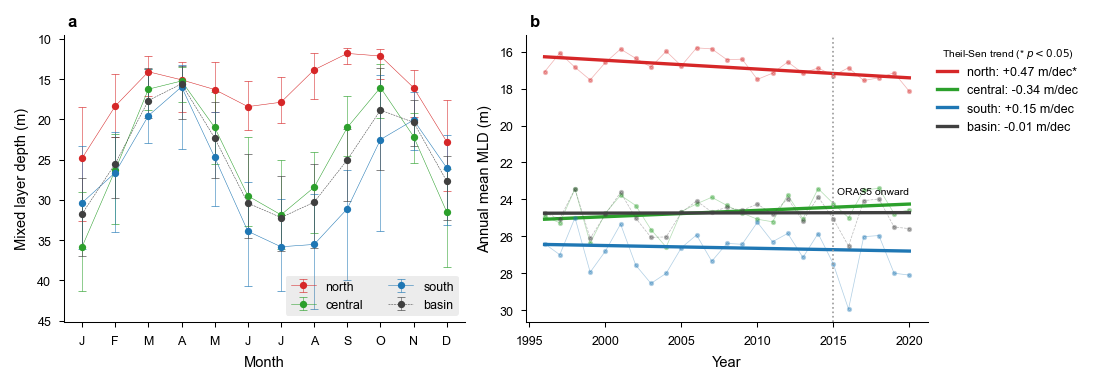

 region  slope_m_per_decade  ci_lo  ci_hi  p_kendall  n_years
  north               0.475  0.059  0.782      0.015       25
central              -0.342 -0.809  0.189      0.142       25
  south               0.150 -0.496  1.005      0.694       25
  basin              -0.014 -0.488  0.584      0.982       25

These are trends on ANNUAL means, so the autocorrelation problem is
far milder than on monthly data. Section 7 repeats them on the monthly
series with the serial-correlation correction; quote those in the text
and treat this panel as the visual summary.


In [254]:
# ============ TEMPORAL DISTRIBUTION: seasonal cycle and trends ============
# Panel (b) shows annual means with a fitted Theil-Sen trend for each
# sub-basin and the basin as a whole. Theil-Sen rather than least squares
# because it is insensitive to the few extreme years that a monsoon record
# always contains. Slopes are quoted per decade in the legend.

from scipy.stats import theilslopes, kendalltau

mld_min = mld_series.groupby(mld_series.index.month).min()
mld_max = mld_series.groupby(mld_series.index.month).max()
COLS = {"north": "#d62728", "central": "#2ca02c", "south": "#1f77b4",
        "basin": "#404040"}
REG_ORDER = ["north", "central", "south", "basin"]

fig, axes = plt.subplots(1, 2, figsize=(COL2, COL2*0.34), constrained_layout=True)

# ---- (a) seasonal cycle --------------------------------------------------
ax = axes[0]
for r in REG_ORDER:
    # Calculate asymmetric error range relative to the mean: [mean - min, max - mean]
    yerr = [
        mld_clim[r] - mld_min[r],
        mld_max[r] - mld_clim[r]
    ]
    
    ax.errorbar(
        mld_clim.index, mld_clim[r], yerr=yerr,
        fmt="-o" if r != "basin" else "--o",
        color=COLS[r],
        label=r,
        lw=0.25,
        capsize=1.8,       # Controls whisker cap width
        capthick=0.3,    # Controls cap border thickness
        ecolor=COLS[r]   # Set whisker color (use COLS[r] to match line color)
    )

ax.invert_yaxis()
ax.set(xlabel="Month", ylabel="Mixed layer depth (m)", xticks=range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.legend(loc="lower right", ncol=2, frameon=True, framealpha=0.15,
          facecolor="gray", edgecolor="none")
panel_label(ax, "a")

# ---- (b) annual means with trend lines -----------------------------------
ax = axes[1]
ann = mld_series.groupby(mld_series.index.year).mean()
yrs = ann.index.values.astype(float)
trend_rows = []

for r in REG_ORDER:
    y = ann[r].values
    ok = np.isfinite(y)
    ax.plot(ann.index[ok], y[ok], marker="o", ms=1.5, lw=0.35, alpha=0.35,
            color=COLS[r], ls="--" if r == "basin" else "-")
    if ok.sum() >= 10:
        slope, icept, lo_s, hi_s = theilslopes(y[ok], yrs[ok], 0.95)
        _, p = kendalltau(yrs[ok], y[ok])
        ax.plot(yrs[ok], icept + slope*yrs[ok], color=COLS[r], lw=1.6,
                ls="-", alpha=1.0,
                label=f"{r}: {10*slope:+.2f} m/dec"
                      f"{'*' if p < 0.05 else ''}")
        trend_rows.append({"region": r, "slope_m_per_decade": 10*slope,
                           "ci_lo": 10*lo_s, "ci_hi": 10*hi_s, "p_kendall": p,
                           "n_years": int(ok.sum())})

ax.axvline(ORAS5_JOIN_YEAR, color="#999999", ls=":", lw=0.8)
ax.annotate("ORAS5 onward", xy=(ORAS5_JOIN_YEAR, ax.get_ylim()[1]),
            xytext=(2, 65), textcoords="offset points", fontsize=5,
            color="black", va="top")
ax.invert_yaxis()
ax.set(xlabel="Year", ylabel="Annual mean MLD (m)")
# frameon must be forced: the Nature rcParams disable legend frames globally,
# and without a solid box these entries sit unreadably on top of the lines.
# placed BELOW the axes: with the depth axis inverted there is no reliable
# empty corner, and an in-panel legend covered the southern series
ax.legend(loc="upper center", bbox_to_anchor=(1.2, 1), ncol=1,
          frameon=False, title="Theil-Sen trend (* $p<0.05$)",
          title_fontsize=5, handlelength=1.6, columnspacing=1.2,fontsize=6)
panel_label(ax, "b")

save_fig(fig, "fig01_mld_temporal_trend")
plt.show()

trend_tbl = pd.DataFrame(trend_rows)
trend_tbl.to_csv(TAB / "mld_annual_trends.csv", index=False)
print(trend_tbl.round(3).to_string(index=False))
print("\nThese are trends on ANNUAL means, so the autocorrelation problem is")
print("far milder than on monthly data. Section 7 repeats them on the monthly")
print("series with the serial-correlation correction; quote those in the text")
print("and treat this panel as the visual summary.")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 39 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'M', 'N', 'P', 'W', 'a', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'space', 't', 'three', 'two', 'x', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 21, 22, 23, 24, 26, 27, 2

   saved: fig05_mld_seasonal_maps.png, fig05_mld_seasonal_maps.eps (19.3 MB)


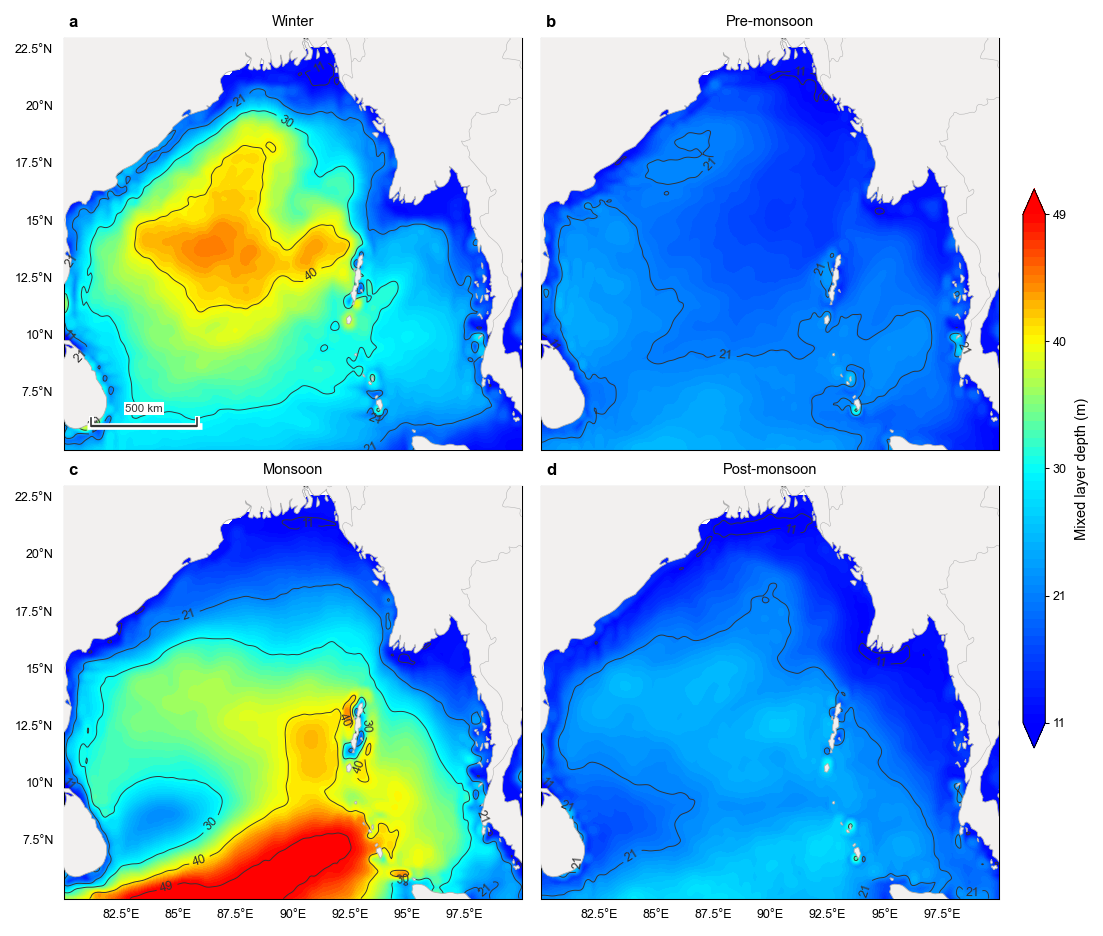

In [263]:
# ============ SPATIAL DISTRIBUTION: seasonal climatology of MLD ===========

seas = cube["mld"].assign_coords(
    season=("time", [SEASONS[m] for m in pd.to_datetime(cube.time.values).month])
).groupby("season").mean("time")

order = [s for s in SEASON_ORDER if s in list(seas["season"].values)]

# ---- 2 × 2 layout ----
fig, axes = map_axes(
    2, 2,
    figsize=(COL2, COL2 * 0.85)
)

vmin = float(np.nanpercentile(seas, 1))
vmax = float(np.nanpercentile(seas, 99))

for k, s in enumerate(order):

    row = k // 2
    col = k % 2
    ax = axes[row, col]

    im = draw_field(
        ax,
        seas.sel(season=s),
        vmin=vmin,
        vmax=vmax,
        left=(col == 0),
        bottom=(row == 1),
        n_contours=5
    )

    ax.set_title(s)

    panel_label(
        ax,
        "abcd"[k]
    )

    if k == 0:
        annotate_map(ax)

# ---- Vertical colorbar on right ----
cb = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    pad=0.025,
    shrink=0.65,
    aspect=25
)

tidy_cbar(
    cb,
    "Mixed layer depth (m)"
)

save_fig(
    fig,
    "fig05_mld_seasonal_maps"
)

plt.show()

## 6b. Temporal and spatial distribution of the parameters

Nature format: sans-serif, 7 pt, 89 mm / 183 mm columns, no grid lines, panel
letters, explicit legends. Each figure is written as **PNG (600 dpi)** and **EPS**.

Seasons: **Winter** DJF, **Pre-monsoon** MAM, **Monsoon** JJAS, **Post-monsoon** ON.

Everything is interpolated and drawn as filled contours with **labelled
isolines**, so no panel shows the underlying monthly or 0.25° cells as blocks.
Label precision follows the contour interval, and every second line is
labelled to keep small panels readable.

Maps carry a **north arrow** and a **scale bar** sized from the true zonal
distance at the panel's mid-latitude. Vector fields are drawn as
**streamlines whose width encodes magnitude**, with a width legend.

The Hovmöller has its own `HOV_SIGMA` and `HOV_CONTOURS`, because anomaly
fields are noisier than climatologies and isolines over noise fill a panel.

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 41 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'B', 'D', 'F', 'J', 'L', 'M', 'N', 'O', 'S', 'Y', 'a', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'o', 'one', 'parenleft', 'parenright', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 19, 20, 21, 22, 23, 24, 25, 27, 36, 3

   saved: fig02_mld_hovmoller.png, fig02_mld_hovmoller.eps (6.1 MB)


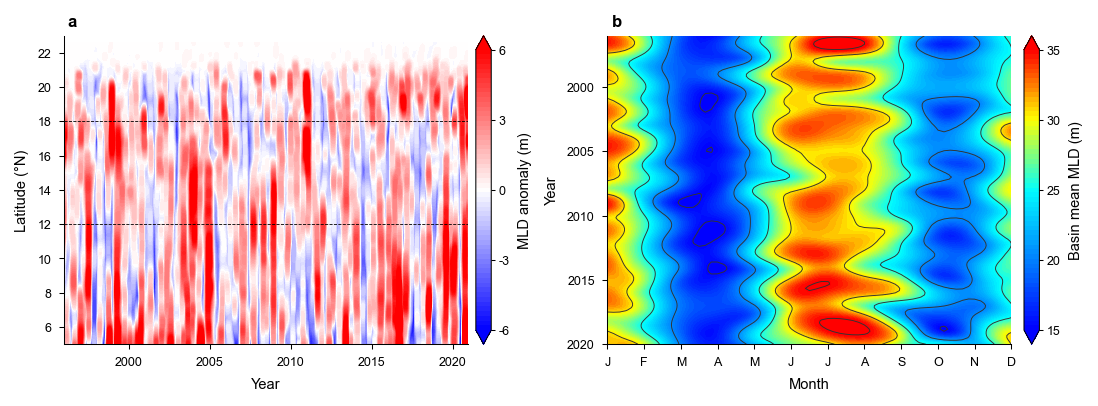

In [255]:
# ======= TEMPORAL DISTRIBUTION: smooth Hovmoller and year-month matrix =====
# Both panels are interpolated and drawn as filled contours with isolines, so
# neither shows the underlying monthly / 0.25 deg cells as blocks.

# Hovmoller-specific controls. Interannual anomaly fields are noisier than
# climatological maps, and isolines drawn over noise turn the panel black, so
# the smoothing is stronger and the contour count lower than for maps.
# Set HOV_CONTOURS = 0 to drop the isolines entirely.
HOV_SIGMA    = 1.6
HOV_CONTOURS = 5

fig, axes = plt.subplots(1, 2, figsize=(COL2, COL2*0.36), constrained_layout=True)

# ---- (a) time-latitude Hovmoller of the zonally averaged MLD anomaly ------
hov = (cube["mld"].groupby("time.month")
       - cube["mld"].groupby("time.month").mean("time")).mean("lon")
t = pd.to_datetime(cube["time"].values)
tnum = mdates.date2num(t)

fx, fy, Zh = smooth_2d(np.asarray(hov.T.values), tnum,
                       np.asarray(cube["lat"].values),
                       up_x=2, up_y=4, sigma=HOV_SIGMA)
lim = float(np.nanpercentile(np.abs(Zh), 98))
lv = np.linspace(-lim, lim, N_LEVELS)
im = axes[0].contourf(fx, fy, Zh, levels=lv, cmap=CMAP_DIV, extend="both")
for c in getattr(im, "collections", [im]):
    try: c.set_rasterized(RASTERIZE_MAPS)
    except Exception: pass
try: im.set_edgecolor("face")
except Exception: pass
# if HOV_CONTOURS:
#     axes[0].contour(fx, fy, Zh, levels=np.linspace(-lim, lim, HOV_CONTOURS),
#                     colors=CONTOUR_COLOR, linewidths=CONTOUR_LW)
axes[0].axhline(LAT_N_MIN, color="k", lw=0.4, ls="--")
axes[0].axhline(LAT_C_MIN, color="k", lw=0.4, ls="--")
axes[0].xaxis.set_major_locator(mdates.YearLocator(5))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set(xlabel="Year", ylabel="Latitude (°N)")
tidy_cbar(fig.colorbar(im, ax=axes[0], pad=0.02), "MLD anomaly (m)")
panel_label(axes[0], "a")

# ---- (b) year x month matrix of the basin mean ---------------------------
mat = (mld_series["basin"].to_frame("mld")
       .assign(year=mld_series.index.year, month=mld_series.index.month)
       .pivot_table(index="year", columns="month", values="mld"))
mx, my, Zm = smooth_2d(mat.values, np.arange(1, 13),
                       mat.index.values.astype(float),
                       up_x=6, up_y=6, sigma=HOV_SIGMA)
vmin, vmax = float(np.nanpercentile(Zm, 1)), float(np.nanpercentile(Zm, 99))
im2 = axes[1].contourf(mx, my, Zm, levels=np.linspace(vmin, vmax, N_LEVELS),
                       cmap=CMAP_SEQ, extend="both")
for c in getattr(im2, "collections", [im2]):
    try: c.set_rasterized(RASTERIZE_MAPS)
    except Exception: pass
try: im2.set_edgecolor("face")
except Exception: pass
if HOV_CONTOURS:
    axes[1].contour(mx, my, Zm, levels=np.linspace(vmin, vmax, HOV_CONTOURS),
                    colors=CONTOUR_COLOR, linewidths=CONTOUR_LW)
axes[1].set(xlabel="Month", ylabel="Year", xticks=range(1, 13))
axes[1].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
axes[1].invert_yaxis()
tidy_cbar(fig.colorbar(im2, ax=axes[1], pad=0.02), "Basin mean MLD (m)")
panel_label(axes[1], "b")

save_fig(fig, "fig02_mld_hovmoller")
plt.show()


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 42 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'C', 'N', 'W', 'Y', 'a', 'c', 'd', 'degree', 'e', 'eight', 'five', 'four', 'g', 'glyph00001', 'glyph00002', 'h', 'i', 'k', 'l', 'm', 'minus', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'q', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 21, 

   saved: fig03_parameters_temporal.png, fig03_parameters_temporal.eps (0.3 MB)


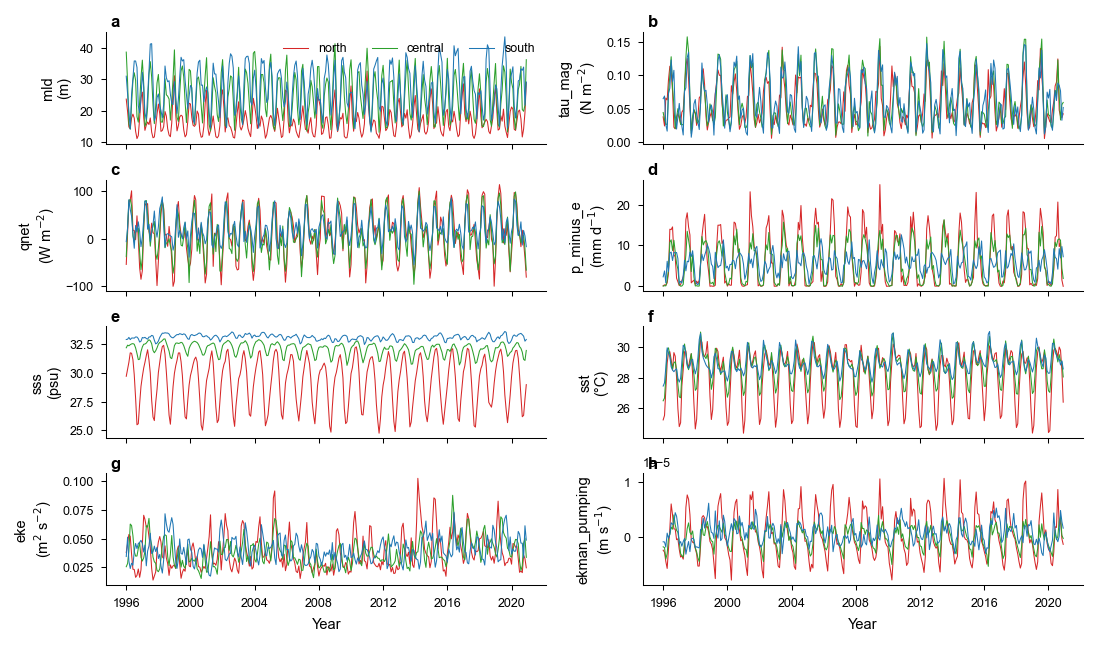

In [158]:
# ============ TEMPORAL DISTRIBUTION of every forcing parameter ============
PANEL_VARS = [v for v in ["mld","tau_mag","qnet","p_minus_e","sss","sst",
                          "eke","ekman_pumping"] if v in cube.data_vars]
UNITS = {"mld":"m", "tau_mag":"N m$^{-2}$", "qnet":"W m$^{-2}$",
         "p_minus_e":"mm d$^{-1}$", "sss":"psu", "sst":"°C",
         "eke":"m$^2$ s$^{-2}$", "ekman_pumping":"m s$^{-1}$",
         "wind_speed":"m s$^{-1}$", "sla":"m"}

n = len(PANEL_VARS); ncol = 2; nrow = int(np.ceil(n/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(COL2, 1.05*nrow),
                         constrained_layout=True, sharex=True)
axes = np.atleast_1d(axes).ravel()
for k, v in enumerate(PANEL_VARS):
    ax = axes[k]
    s = series_table(v)
    for r in ["north", "central", "south"]:
        ax.plot(s.index, s[r], color=COLS[r], lw=0.5, label=r)
    ax.set_ylabel(f"{v}\n({UNITS.get(v,'')})")
    panel_label(ax, "abcdefghij"[k])
    if k == 0:
        ax.legend(loc="upper right", ncol=3)
for ax in axes[n:]:
    ax.set_visible(False)
for ax in axes[max(0, n-ncol):n]:
    ax.set_xlabel("Year")
save_fig(fig, "fig03_parameters_temporal")
plt.show()

In [ ]:
import os
from pathlib import Path

target_dir = Path(r"F:\Marine Science\4th Year\term paper\Data")

os.chdir(target_dir)

# 3. Verify the change using pathlib
print("Current Directory:", Path.cwd())

Current Directory: F:\Marine Science\4th Year\term paper\Data


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 37 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'D', 'E', 'L', 'M', 'N', 'S', 'a', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 39, 40, 47, 48, 49, 54, 68, 71, 72,

   saved: fig04_mld_spatial.png, fig04_mld_spatial.eps (4.9 MB)


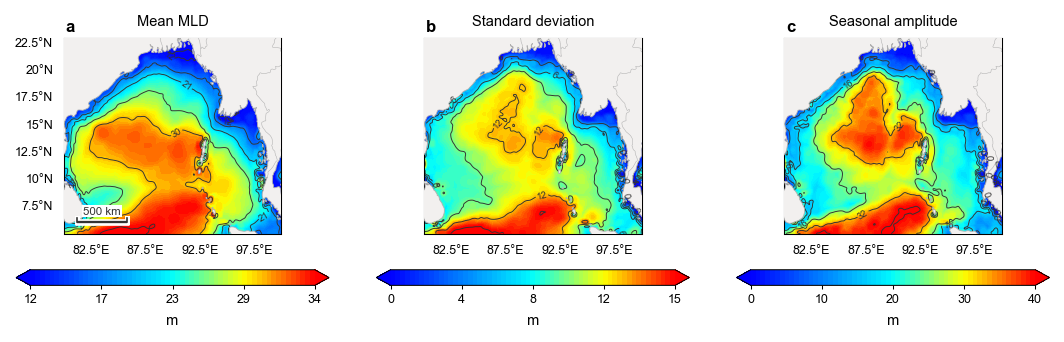

In [199]:
# ============ SPATIAL DISTRIBUTION of MLD: mean, variability, amplitude ===
mld_mean = cube["mld"].mean("time")
mld_sd   = cube["mld"].std("time")
mld_amp  = (cube["mld"].groupby("time.month").mean("time").max("month")
            - cube["mld"].groupby("time.month").mean("time").min("month"))

panels = [(mld_mean, "Mean MLD", "m", CMAP_SEQ, None),
          (mld_sd,   "Standard deviation", "m", CMAP_SEQ, None),
          (mld_amp,  "Seasonal amplitude", "m", CMAP_SEQ, None)]

fig, axes = map_axes(1, 3, figsize=(COL2, COL2*0.30))
for k, (fld, title, unit, cmap, norm) in enumerate(panels):
    ax = axes[0, k]
    vmax = float(np.nanpercentile(fld, 99))
    im = draw_field(ax, fld, cmap=cmap, vmin=float(np.nanpercentile(fld, 1)),
                    vmax=vmax, left=(k == 0), bottom=True,
                    n_contours=6)
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.06, shrink=0.9)
    tidy_cbar(cb, unit)
    panel_label(ax, "abc"[k])
    if k == 0: annotate_map(ax)
save_fig(fig, "fig04_mld_spatial")
plt.show()

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 48 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'C', 'D', 'E', 'F', 'H', 'K', 'L', 'M', 'N', 'P', 'S', 'T', 'W', 'a', 'd', 'degree', 'e', 'eight', 'five', 'four', 'g', 'glyph00001', 'glyph00002', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3,

   saved: fig06_parameters_spatial.png, fig06_parameters_spatial.eps (14.5 MB)


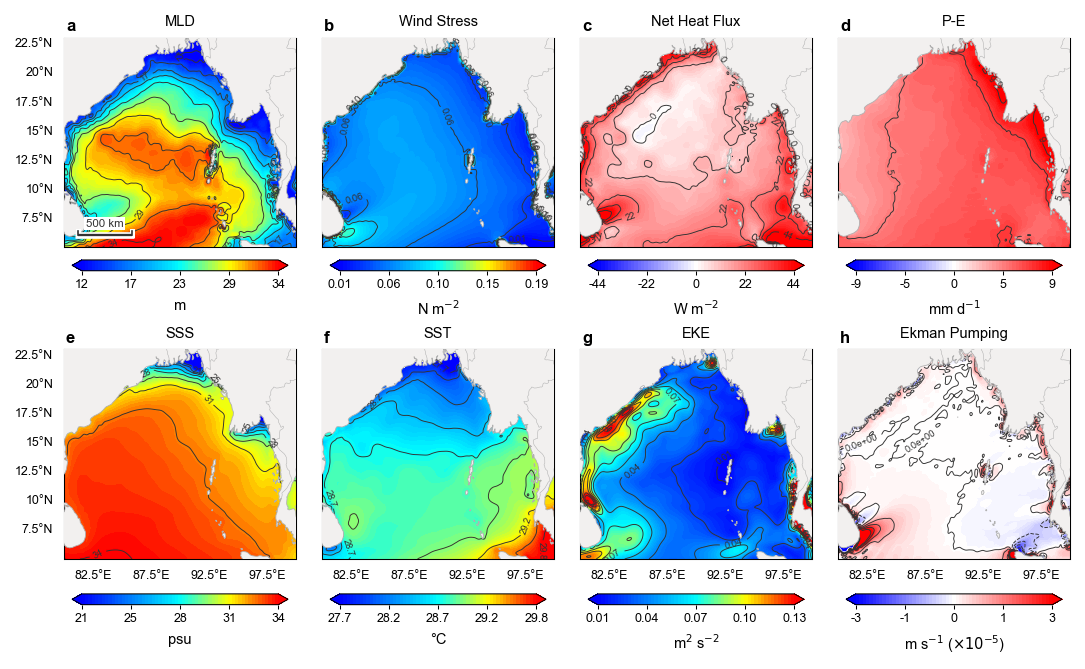

In [200]:
# ============ SPATIAL DISTRIBUTION of every forcing parameter =============
MAP_VARS = [v for v in ["mld","tau_mag","qnet","p_minus_e","sss","sst",
                        "eke","ekman_pumping"] if v in cube.data_vars]
# fields that straddle zero read better on the diverging ramp
DIVERGING = {"qnet", "p_minus_e", "ekman_pumping", "sla"}
Visual_VARS = ["MLD","Wind Stress","Net Heat Flux","P-E","SSS","SST", "EKE","Ekman Pumping"]


ncol = 4; nrow = int(np.ceil(len(MAP_VARS)/ncol))
fig, axes = map_axes(nrow, ncol, figsize=(COL2, COL2*0.30*nrow))
for k, v in enumerate(MAP_VARS):
    i, j = divmod(k, ncol)
    ax = axes[i, j]
    fld = cube[v].mean("time")
    if v in DIVERGING:
        lim = float(np.nanpercentile(np.abs(fld), 98))
        im = draw_field(ax, fld, cmap=CMAP_DIV, vmin=-lim, vmax=lim,
                        left=(j == 0), bottom=(i == nrow-1),
                        n_contours=9)
    else:
        im = draw_field(ax, fld, cmap=CMAP_SEQ,
                        vmin=float(np.nanpercentile(fld, 1)),
                        vmax=float(np.nanpercentile(fld, 99)),
                        left=(j == 0), bottom=(i == nrow-1),
                        n_contours=9)
    ax.set_title(Visual_VARS[k])
    cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.88)
    tidy_cbar(cb, UNITS.get(v, ""))
    panel_label(ax, "abcdefghij"[k])
    if k == 0: annotate_map(ax)
for k in range(len(MAP_VARS), nrow*ncol):
    axes[divmod(k, ncol)].set_visible(False)
save_fig(fig, "fig06_parameters_spatial")
plt.show()

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 41 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'M', 'N', 'P', 'W', 'a', 'bar', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'x', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 21, 22, 23,

   saved: fig13_seasonal_mld_windstress.png, fig13_seasonal_mld_windstress.eps (7.2 MB)


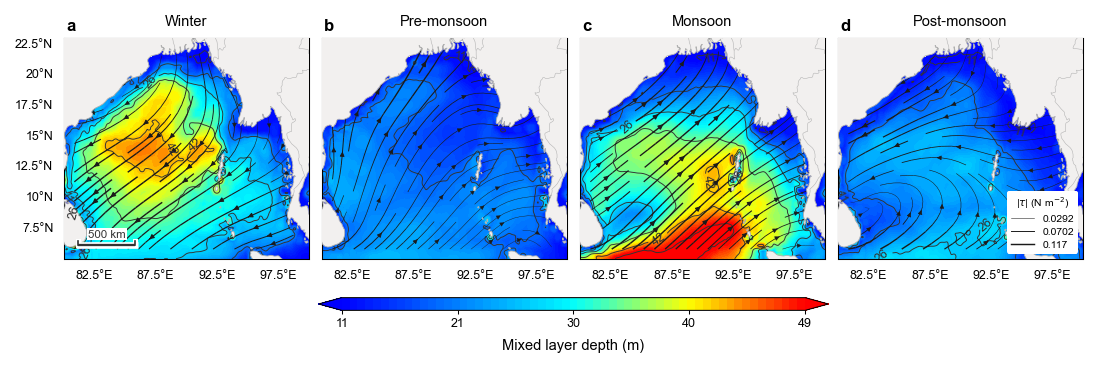

Streamline width is proportional to wind stress magnitude; the
legend gives the scale. Deepening under the strongest stress and
its seasonal reversal should both be visible.


In [274]:
# ====== SEASONAL VECTOR FIELD: wind stress streamlines over MLD ============
# Filled MLD with wind-stress streamlines on top. Streamline WIDTH encodes
# stress magnitude, so the colour axis stays reserved for MLD and the panel
# needs only one colourbar plus a small width legend.

u_all, v_all = find_vector("wind stress")
if u_all is None:
    print("no wind stress components in the cube; streamplot skipped")
    print("available:", list(cube.data_vars))
else:
    seas_mld = cube["mld"].assign_coords(
        season=("time", [SEASONS[m] for m in pd.to_datetime(cube.time.values).month])
    ).groupby("season").mean("time")
    su = u_all.assign_coords(
        season=("time", [SEASONS[m] for m in pd.to_datetime(cube.time.values).month])
    ).groupby("season").mean("time")
    sv = v_all.assign_coords(
        season=("time", [SEASONS[m] for m in pd.to_datetime(cube.time.values).month])
    ).groupby("season").mean("time")

    order = [s for s in SEASON_ORDER if s in list(seas_mld["season"].values)]
    fig, axes = map_axes(1, len(order), figsize=(COL2, COL2*0.32))
    vmin = float(np.nanpercentile(seas_mld, 1))
    vmax = float(np.nanpercentile(seas_mld, 99))
    smax_all = 0
    for k, s in enumerate(order):
        ax = axes[0, k]
        im = draw_field(ax, seas_mld.sel(season=s), vmin=vmin, vmax=vmax,
                        left=(k == 0), bottom=True, n_contours=6)
        smax, lwr = add_streamplot(ax, su.sel(season=s), sv.sel(season=s))
        smax_all = max(smax_all, smax)
        ax.set_title(s)
        panel_label(ax, "abcd"[k])
        if k == 0:
            annotate_map(ax)
    stream_legend(axes[0, -1], smax_all, units=VECTOR_UNITS["wind stress"],
                  title="|$\\tau$| (N m$^{-2}$)")
    cb = fig.colorbar(im, ax=axes[0, :], orientation="horizontal",
                      pad=0.06, shrink=0.5, aspect=40)
    tidy_cbar(cb, "Mixed layer depth (m)")
    save_fig(fig, "fig13_seasonal_mld_windstress")
    plt.show()
    print("Streamline width is proportional to wind stress magnitude; the")
    print("legend gives the scale. Deepening under the strongest stress and")
    print("its seasonal reversal should both be visible.")


### 6c. Every forcing parameter: seasonal fields and temporal trend

One figure per parameter. Panels **a-d** are the four seasonal means on a
single shared colour scale, so the seasons are directly comparable within the
parameter. Panel **e** is the annual-mean series for north, central, south and
basin, each with a fitted **Theil-Sen** trend and its slope per decade in the
legend, starred where Kendall p < 0.05.

Theil-Sen rather than least squares because a monsoon record always contains a
few extreme years and a median-of-slopes estimator is not dragged by them.
These are trends on ANNUAL means, so serial correlation is far weaker than on
the monthly series; Section 7 repeats the MLD trends monthly with the
autocorrelation correction, and those are the numbers to quote in the text.

building 10 parameter suites: ['mld', 'tau_mag', 'wind_speed', 'qnet', 'p_minus_e', 'ekman_pumping', 'eke', 'sla', 'sst', 'sss']



INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 50 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'D', 'E', 'L', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:

   saved: fig14_mld_seasonal_trend.png, fig14_mld_seasonal_trend.eps (11.7 MB)


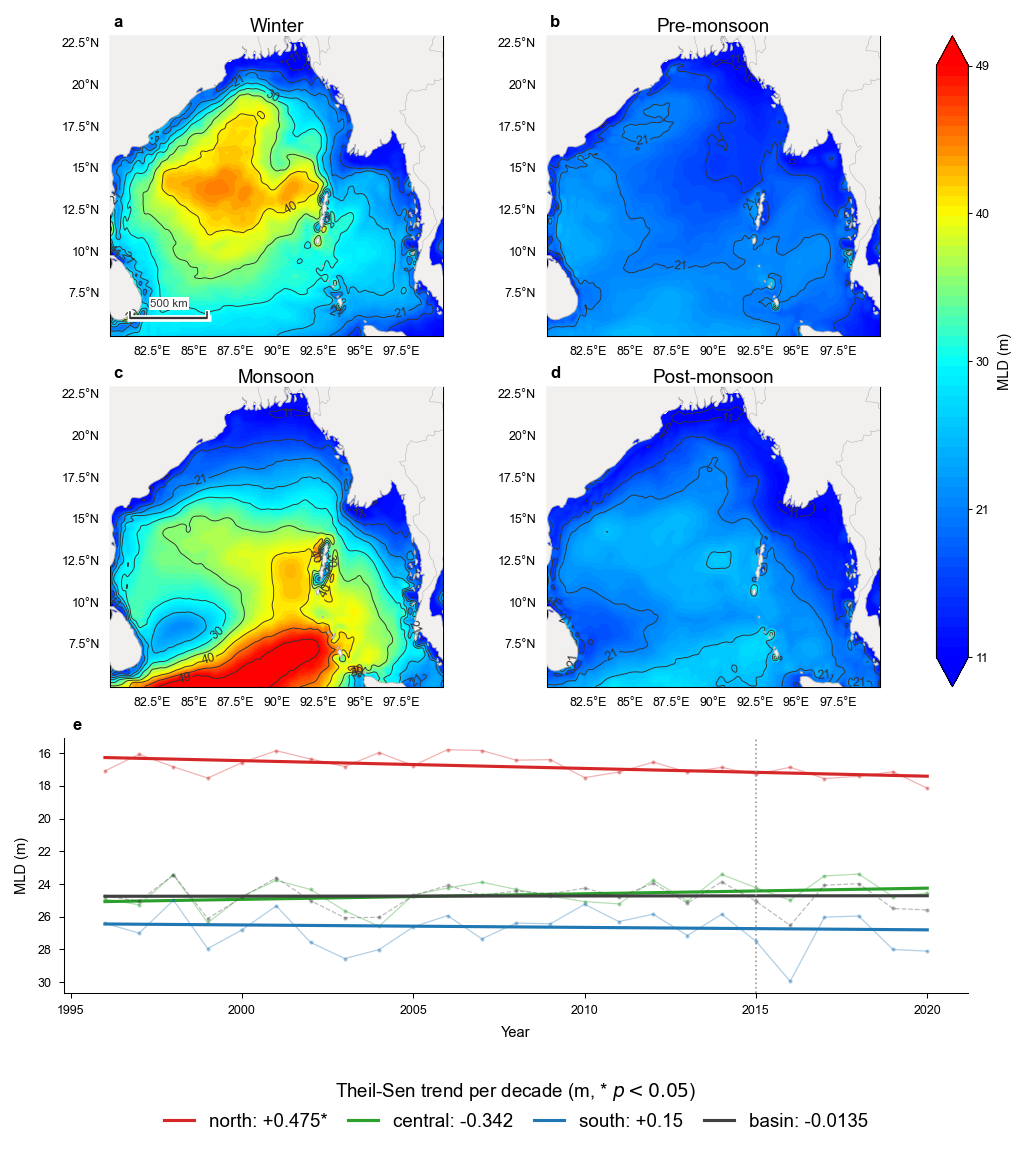

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 47 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1

   saved: fig15_tau_mag_seasonal_trend.png, fig15_tau_mag_seasonal_trend.eps (11.9 MB)


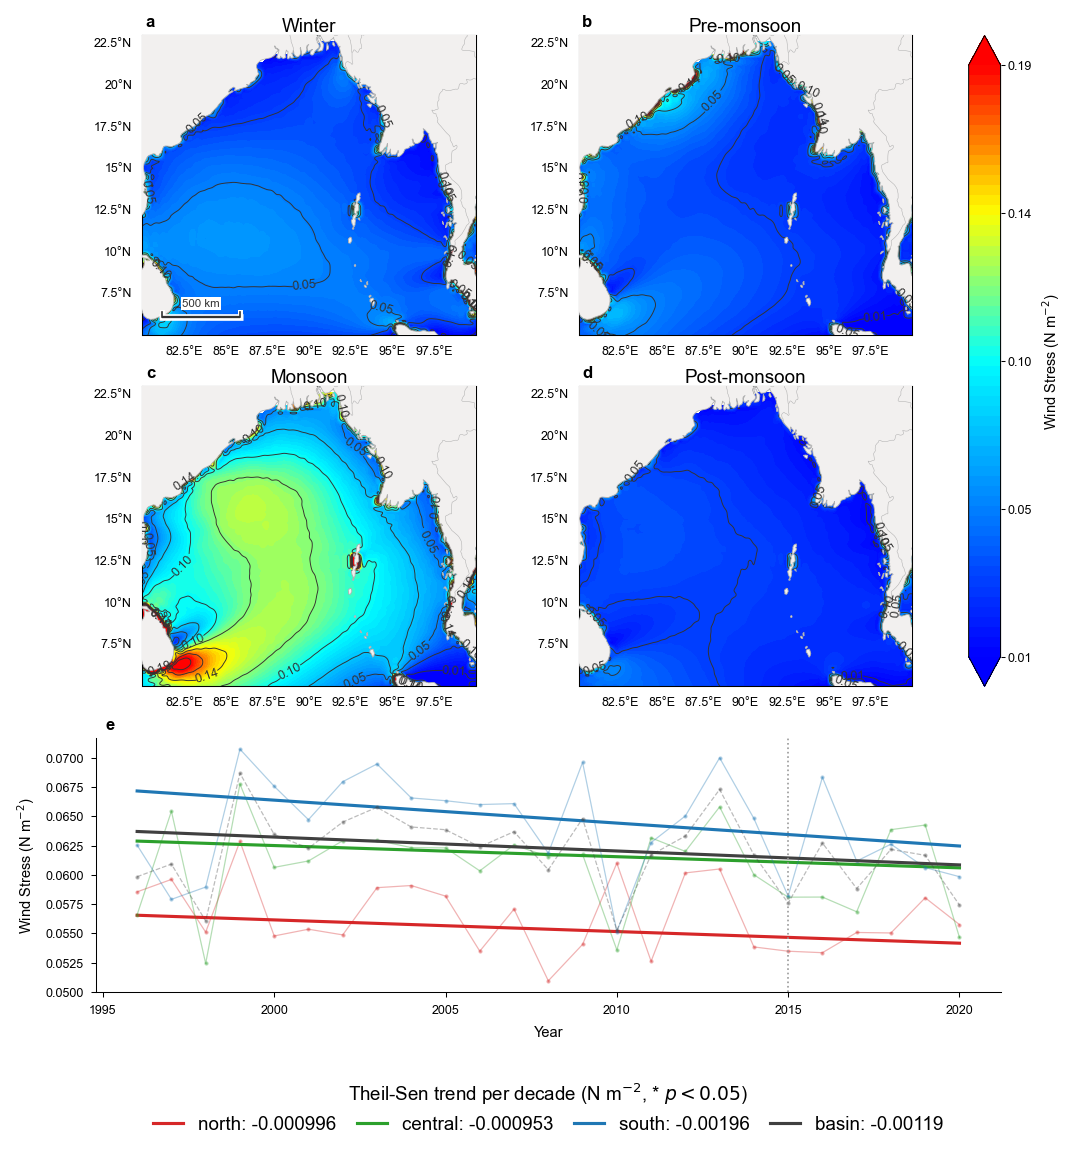

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 47 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1

   saved: fig16_wind_speed_seasonal_trend.png, fig16_wind_speed_seasonal_trend.eps (11.6 MB)


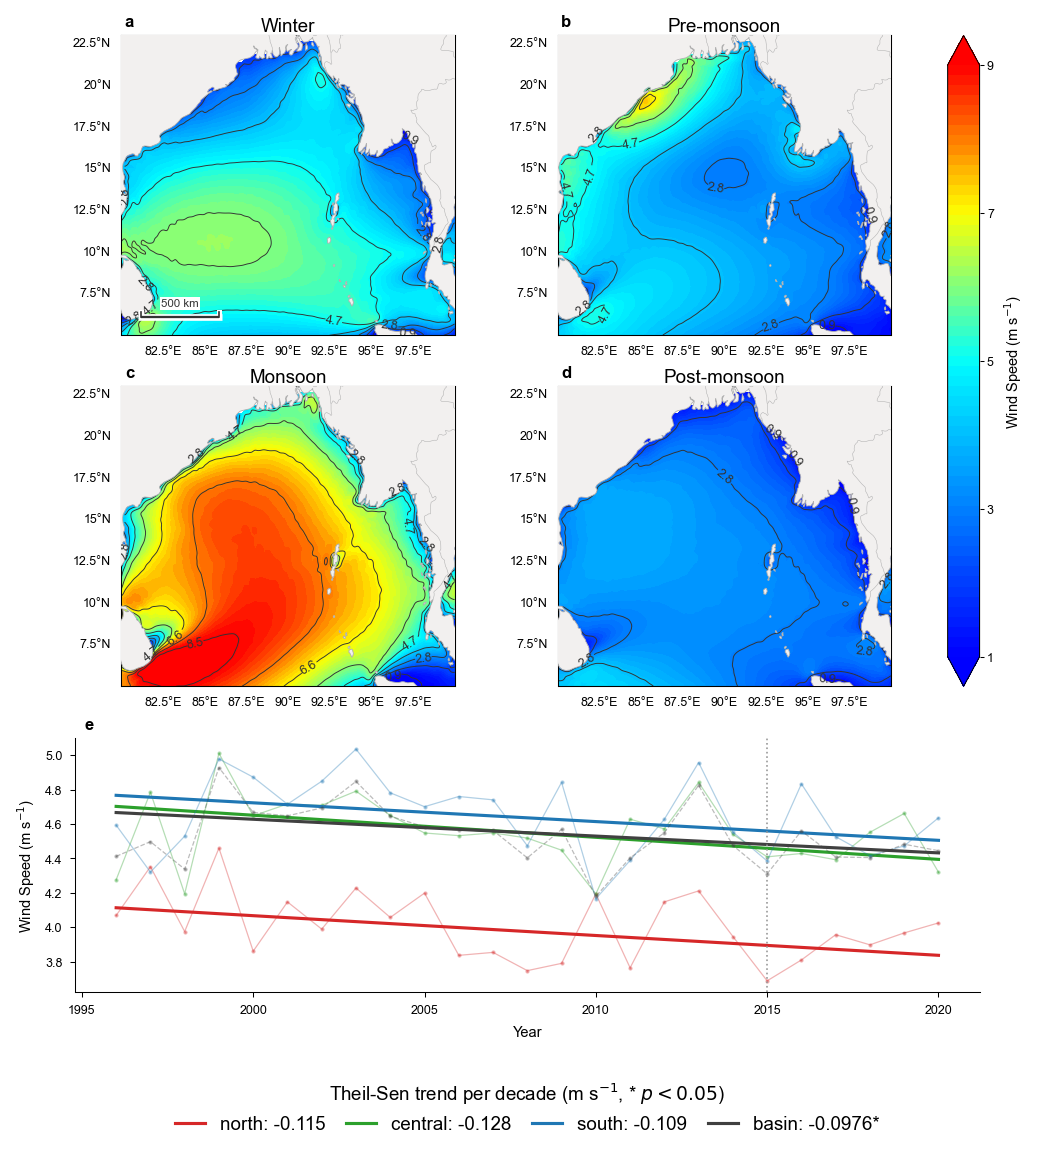

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 51 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'F', 'H', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'zero']
INFO:fontTools.su

   saved: fig17_qnet_seasonal_trend.png, fig17_qnet_seasonal_trend.eps (11.6 MB)


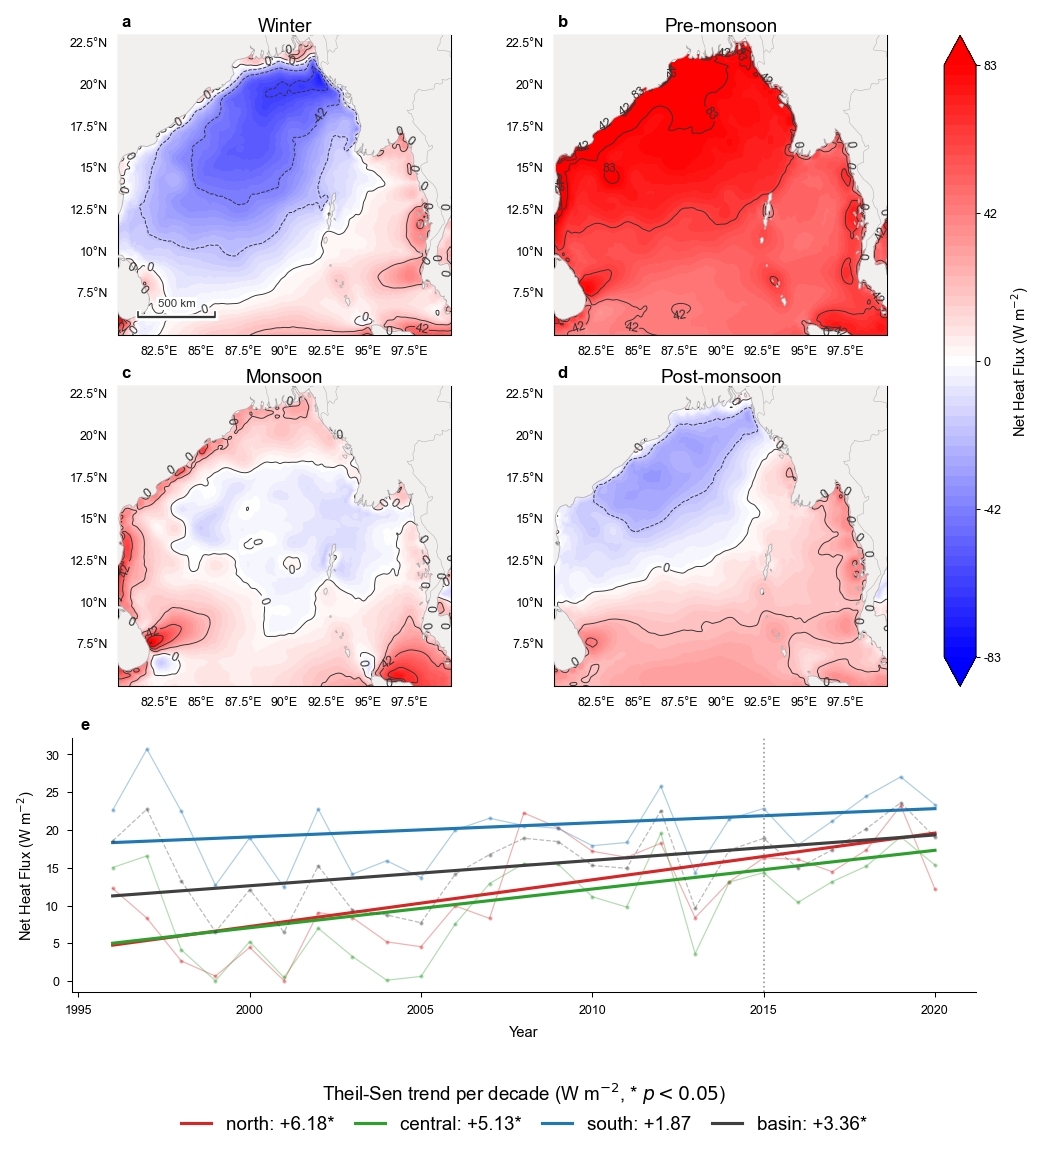

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 48 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:

   saved: fig18_p_minus_e_seasonal_trend.png, fig18_p_minus_e_seasonal_trend.eps (11.3 MB)


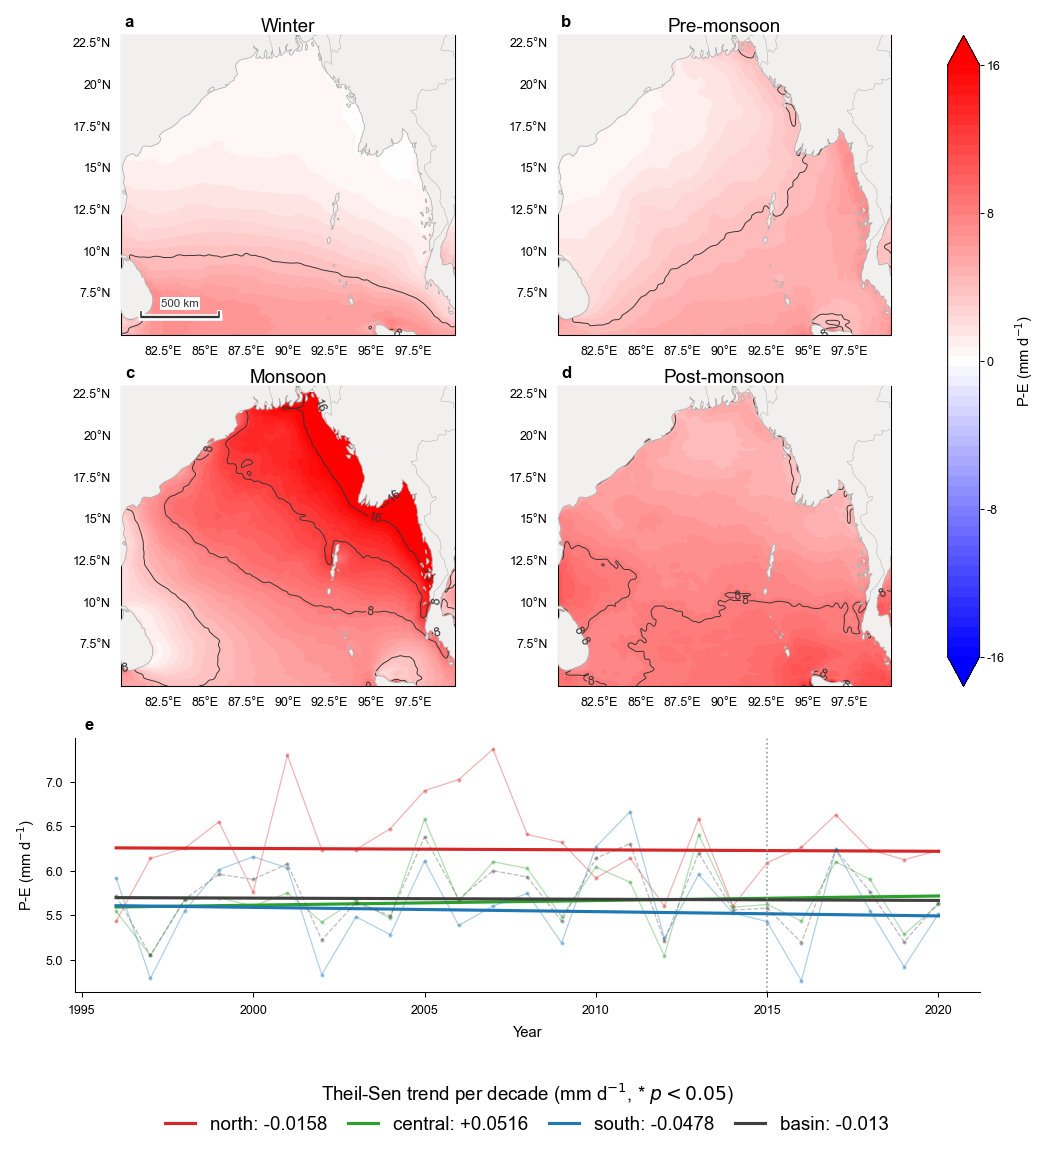

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 49 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'g', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph

   saved: fig19_ekman_pumping_seasonal_trend.png, fig19_ekman_pumping_seasonal_trend.eps (12.0 MB)


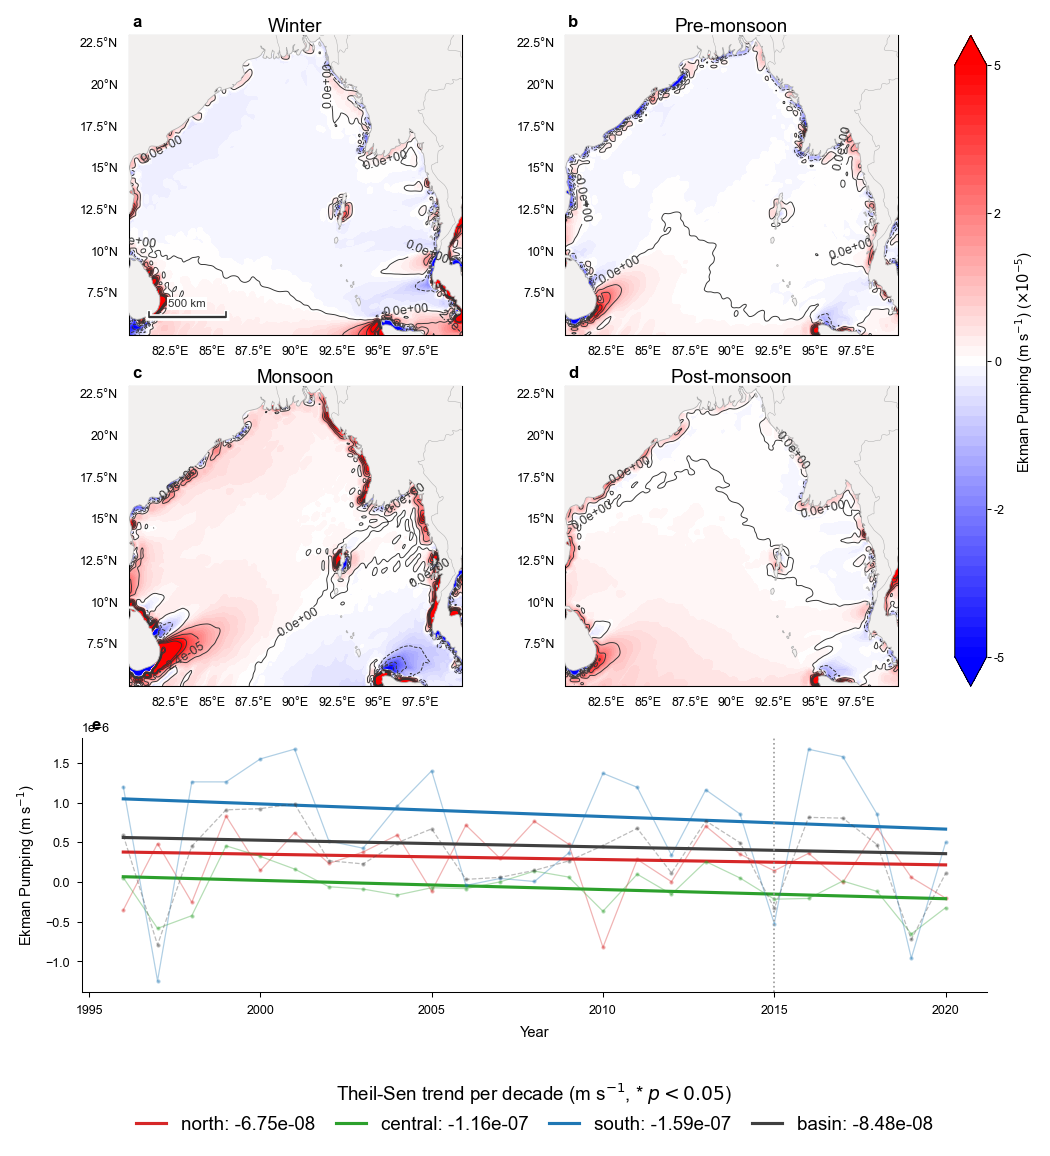

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 49 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'K', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph

   saved: fig20_eke_seasonal_trend.png, fig20_eke_seasonal_trend.eps (11.8 MB)


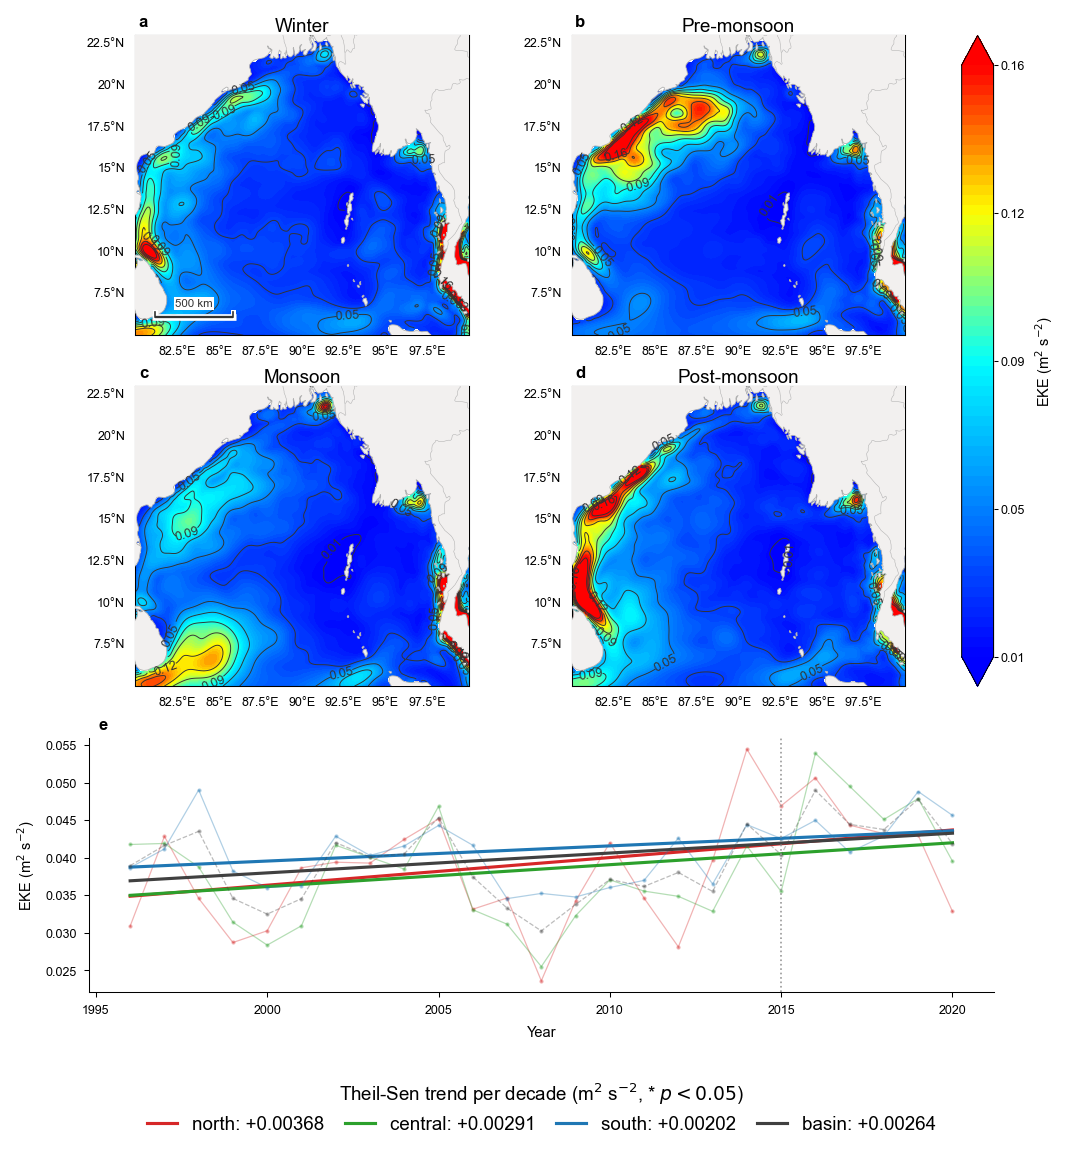

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 51 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'E', 'L', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTool

   saved: fig21_sla_seasonal_trend.png, fig21_sla_seasonal_trend.eps (11.5 MB)


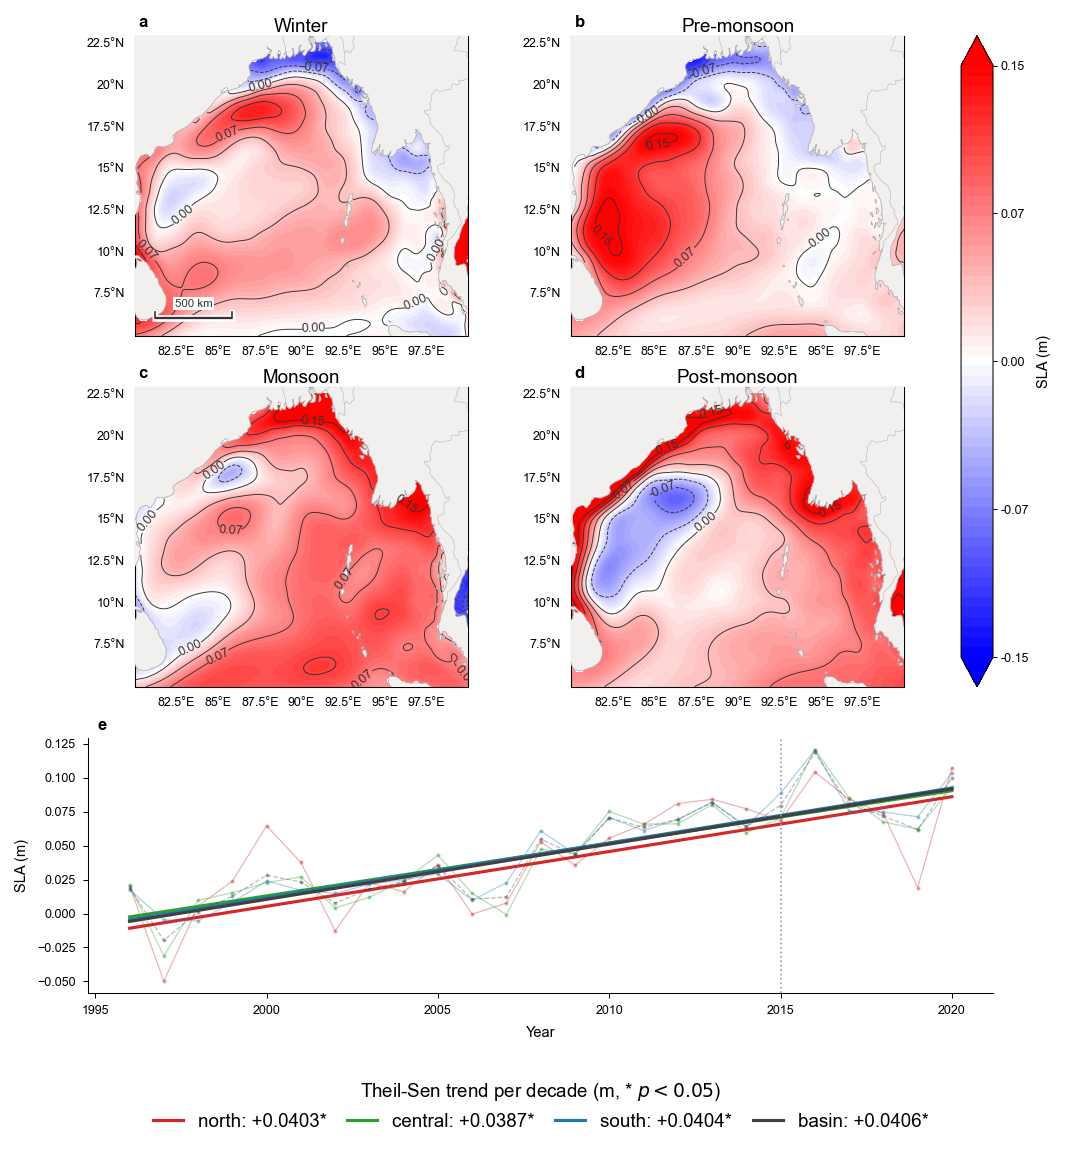

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 49 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'C', 'E', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph

   saved: fig22_sst_seasonal_trend.png, fig22_sst_seasonal_trend.eps (11.3 MB)


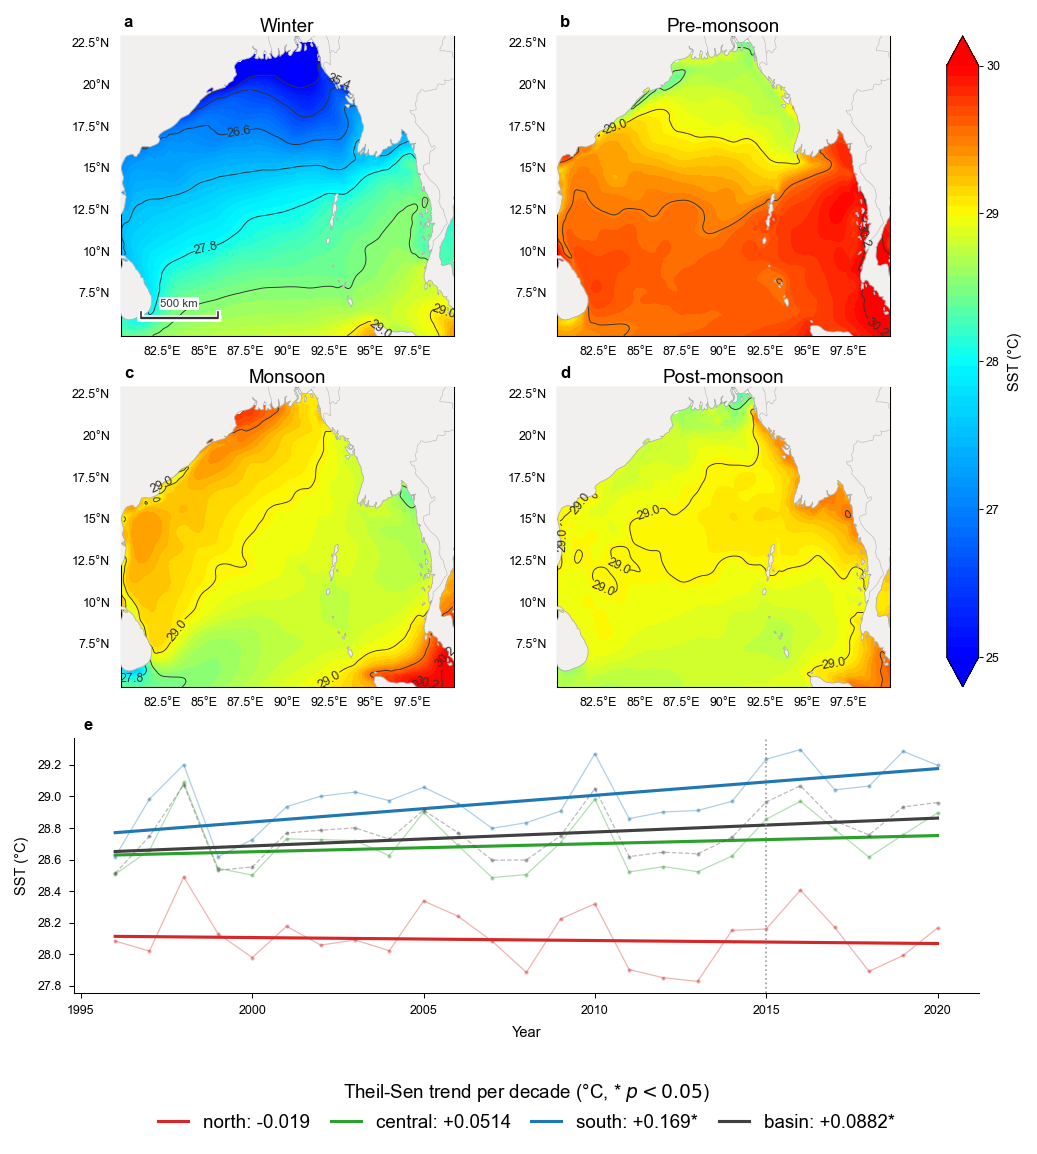

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 47 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'M', 'N', 'P', 'S', 'T', 'W', 'Y', 'a', 'asterisk', 'b', 'c', 'colon', 'comma', 'd', 'degree', 'e', 'eight', 'five', 'four', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 

   saved: fig23_sss_seasonal_trend.png, fig23_sss_seasonal_trend.eps (11.3 MB)


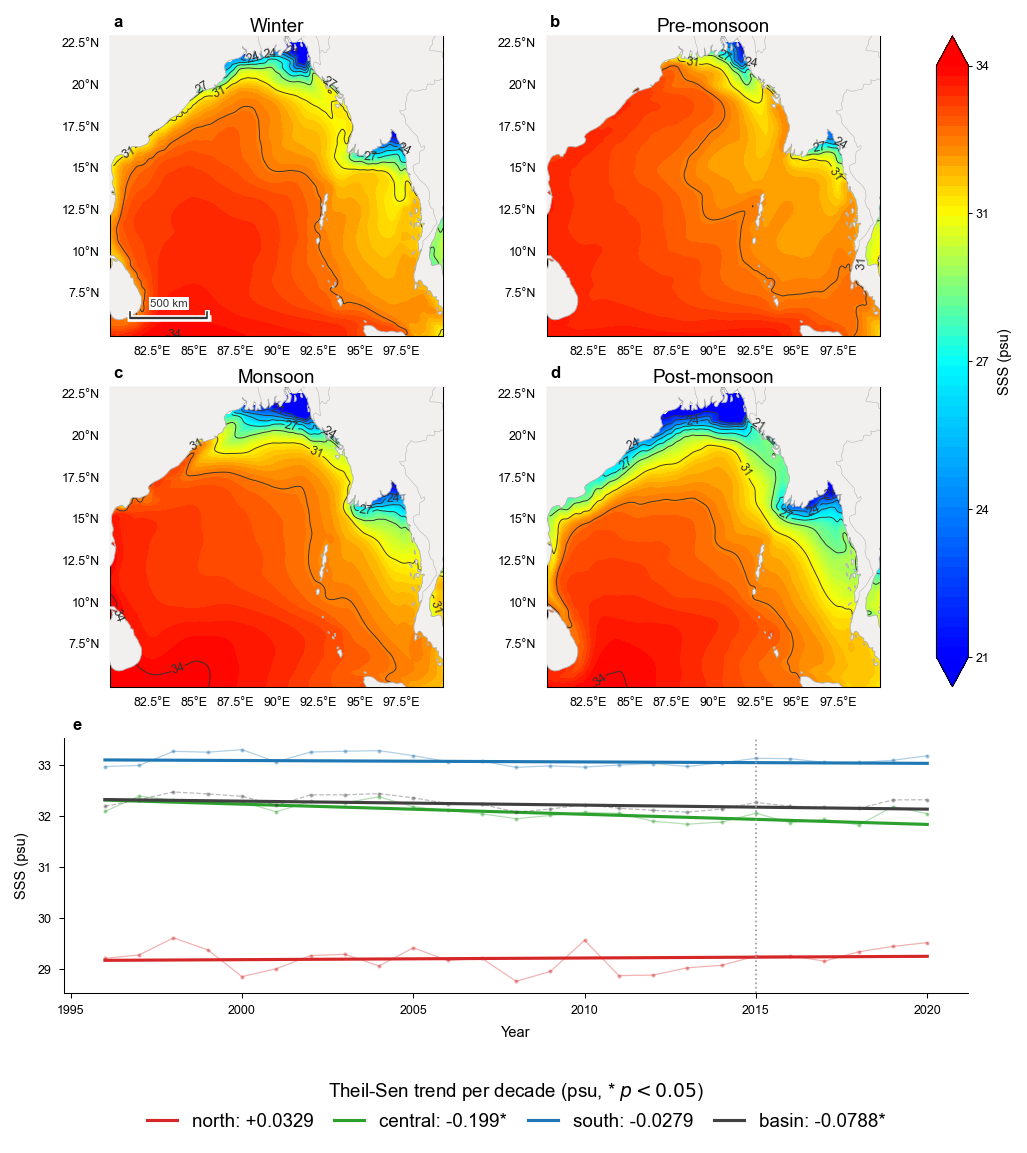

PermissionError: [Errno 13] Permission denied: 'outputs\\tables\\parameter_trends.csv'

In [275]:
# ===== PER-PARAMETER SUITE: seasonal maps + temporal trend, one per field ==
# For every forcing parameter, one figure with the four seasonal fields on top
# (shared colour scale, so panels are directly comparable) and the annual-mean
# time series with fitted Theil-Sen trends below.
#
# Theil-Sen rather than least squares: a monsoon record always contains a few
# extreme years, and a median-of-slopes estimator is not dragged by them.
# Significance is Kendall tau on the annual means. Section 7 repeats the MLD
# trends on the MONTHLY series with the serial-correlation correction; quote
# those in the text and treat these panels as the visual summary.

from matplotlib.gridspec import GridSpec
from scipy.stats import theilslopes, kendalltau

SUITE_VARS = [v for v in ["mld", "tau_mag", "wind_speed", "qnet", "p_minus_e",
                          "ekman_pumping", "eke", "sla", "sst", "sss"]
              if v in cube.data_vars]
DIVERGING = {"qnet", "p_minus_e", "ekman_pumping", "sla"}
INVERT_Y  = {"mld"}                      # depth increases downward
COLS = {"north": "#d62728", "central": "#2ca02c",
        "south": "#1f77b4", "basin": "#404040"}
REG_ORDER = ["north", "central", "south", "basin"]

_season_of = [SEASONS[m] for m in pd.to_datetime(cube.time.values).month]
suite_trends = []
Visual_VARS = ["MLD","Wind Stress","Wind Speed", "Net Heat Flux", "P-E", "Ekman Pumping", "EKE", "SLA", "SST","SSS"]
var_name_mapping = dict(zip(SUITE_VARS, Visual_VARS))
def parameter_suite(var, fig_no):
    unit = UNITS.get(var, cube[var].attrs.get("units", ""))

    seas = cube[var].assign_coords(
        season=("time", _season_of)
    ).groupby("season").mean("time")

    order = [
        s for s in SEASON_ORDER
        if s in list(seas["season"].values)
    ]

    fig = plt.figure(
        figsize=(COL2 * 1.08, COL2 * 1.15)
    )

    gs = GridSpec(
        3, 3,
        figure=fig,
        width_ratios=[1, 1, 0.075],
        height_ratios=[1, 1, 0.85],
        hspace=0.18,
        wspace=0.035
    )

    mkw = (
        {"projection": ccrs.PlateCarree()}
        if HAS_CARTOPY else {}
    )

    if var in DIVERGING:
        lim = float(
            np.nanpercentile(np.abs(seas), 98)
        )
        vmin, vmax, cmap = -lim, lim, CMAP_DIV

    else:
        vmin = float(
            np.nanpercentile(seas, 1)
        )
        vmax = float(
            np.nanpercentile(seas, 99)
        )
        cmap = CMAP_SEQ

    axm = []

    # ============================================================
    # 2 × 2 SEASONAL MAPS
    # ============================================================

    for k, s in enumerate(order[:4]):

        row = k // 2
        col = k % 2

        ax = fig.add_subplot(
            gs[row, col],
            **mkw
        )

        im = draw_field(
            ax,
            seas.sel(season=s),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            left=True,
            bottom=True,
            n_contours=9
        )

        ax.set_title(
            s,
            pad=2,
            fontsize=9,
        )

        panel_label(
            ax,
            "abcd"[k]
        )

        if k == 0:
            annotate_map(ax)

        axm.append(ax)

    # ============================================================
    # VERTICAL COLORBAR
    # ============================================================

    cax = fig.add_subplot(
        gs[0:2, 2]
    )

    cb = fig.colorbar(
        im,
        cax=cax,
        pad=0.02,
        shrink=0.85,
        aspect=15,
        orientation="vertical"
    )

    tidy_cbar(
        cb,
        f"{var_name_mapping[var]} ({unit})"
        if unit else var
    )

    # ============================================================
    # ANNUAL MEAN + THEIL-SEN TREND
    # ============================================================

    axt = fig.add_subplot(
        gs[2, :]
    )

    s_all = series_table(var)

    ann = s_all.groupby(
        s_all.index.year
    ).mean()

    yrs = ann.index.values.astype(float)

    for r in REG_ORDER:

        y = ann[r].values

        ok = np.isfinite(y)

        if ok.sum() < 3:
            continue

        axt.plot(
            ann.index[ok],
            y[ok],
            marker="o",
            ms=1,
            lw=0.6,
            color=COLS[r],
            alpha=0.35,
            ls="--" if r == "basin" else "-"
        )

        if ok.sum() >= 10:

            sl, ic, lo_s, hi_s = theilslopes(
                y[ok],
                yrs[ok],
                0.95
            )

            _, p = kendalltau(
                yrs[ok],
                y[ok]
            )

            axt.plot(
                yrs[ok],
                ic + sl * yrs[ok],
                color=COLS[r],
                lw=1.5,
                label=(
                    f"{r}: "
                    f"{10*sl:+.3g}"
                    f"{'*' if p < 0.05 else ''}"
                )
            )

            suite_trends.append({
                "variable": var,
                "unit": unit,
                "region": r,
                "trend_per_decade": 10 * sl,
                "ci_lo": 10 * lo_s,
                "ci_hi": 10 * hi_s,
                "p_kendall": p,
                "n_years": int(ok.sum())
            })

    axt.axvline(
        ORAS5_JOIN_YEAR,
        color="#999999",
        ls=":",
        lw=0.8
    )

    if var in INVERT_Y:
        axt.invert_yaxis()

    axt.set(
        xlabel="Year",
        ylabel=(
            f"{var_name_mapping[var]} ({unit})"
            if unit else var
        )
    )

    axt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.28),
        ncol=4,
        frameon=False,
        handlelength=1.6,
        columnspacing=1.1,
        title=(
            f"Theil-Sen trend per decade "
            f"({unit}, * $p<0.05$)"
        ),
        title_fontsize=9,
        fontsize=9
    )

    panel_label(
        axt,
        "e"
    )

    # ============================================================
    # SAVE
    # ============================================================

    save_fig(
        fig,
        f"fig{fig_no:02d}_{var}_seasonal_trend"
    )

    plt.show()
print(f"building {len(SUITE_VARS)} parameter suites: {SUITE_VARS}\n")
for n, v in enumerate(SUITE_VARS, start=14):
    parameter_suite(v, n)

suite_tbl = pd.DataFrame(suite_trends)
suite_tbl.to_csv(TAB / "parameter_trends.csv", index=False)
print("\nannual-mean trends per decade (* = Kendall p < 0.05):")
piv = suite_tbl.pivot_table(index="variable", columns="region",
                            values="trend_per_decade")
print(piv.reindex(columns=REG_ORDER).round(4).to_string())



Index(['mld', 'tau_mag', 'wind_speed', 'qnet', 'p_minus_e', 'ekman_pumping',
       'eke', 'sla', 'sst', 'sss'],
      dtype='object', name='variable')


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 48 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'D', 'E', 'F', 'H', 'K', 'L', 'M', 'N', 'P', 'S', 'T', 'W', 'a', 'asterisk', 'b', 'c', 'd', 'e', 'eight', 'f', 'four', 'g', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'o', 'p', 'parenleft', 'parenright', 'percent', 'r', 's', 'six', 'space', 't', 'two', 'u', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 

   saved: fig24_parameter_trend_summary.png, fig24_parameter_trend_summary.eps (0.1 MB)


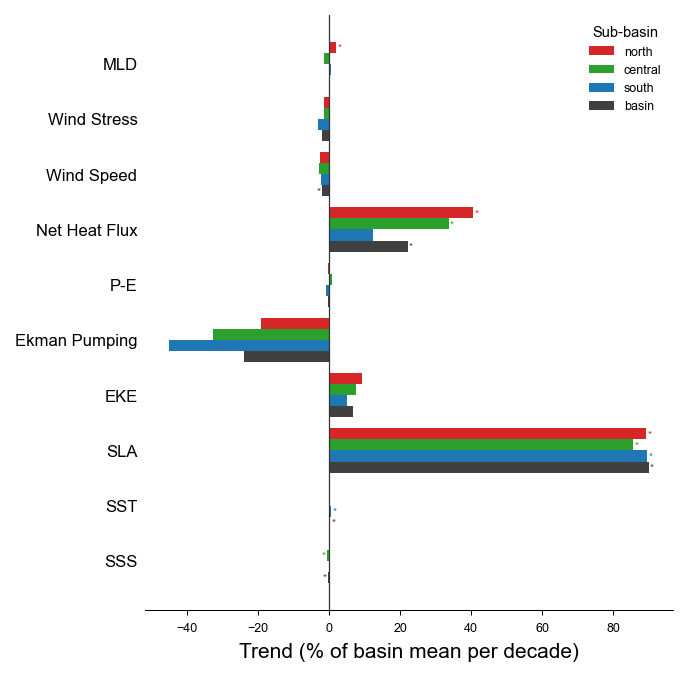

* marks Kendall p < 0.05 on the annual means.
Percentages are relative to each parameter's own basin mean, so a
bar compares magnitudes across parameters without implying they
share units. Absolute trends are in parameter_trends.csv.


In [284]:
# ===== SUMMARY: trends of every parameter, all sub-basins, one panel ======
# Trends are in different units, so each is expressed as a percentage of that
# parameter's own basin-mean per decade. That makes magnitudes comparable
# across wind stress, heat flux and freshwater without implying they share a
# scale. Absolute values with units stay in parameter_trends.csv.
#v ['mld', 'tau_mag', 'wind_speed', 'qnet', 'p_minus_e', 'ekman_pumping', 'eke', 'sla', 'sst', 'sss']
Visual_VARS = ["MLD","Wind Stress", "Wind Speed", "Net Heat Flux","P-E", "Ekman Pumping", "EKE", "SLA", "SST","SSS", ]
print()
Y_VARS = dict(zip(SUITE_VARS, Visual_VARS))
if len(suite_trends):
    base = {v: float(np.abs(cube[v].mean()).values) for v in SUITE_VARS}
    tb = suite_tbl.copy()
    tb["pct_per_decade"] = [
        100*r.trend_per_decade/base[r.variable] if base[r.variable] else np.nan
        for r in tb.itertuples()]

    piv = tb.pivot_table(index="variable", columns="region",
                         values="pct_per_decade").reindex(columns=REG_ORDER)
    sig = tb.pivot_table(index="variable", columns="region",
                         values="p_kendall").reindex(columns=REG_ORDER)
    piv = piv.reindex([v for v in SUITE_VARS if v in piv.index])
    sig = sig.reindex(piv.index)

    fig, ax = plt.subplots(figsize=(COL2*0.62, 0.30*len(piv)+1.4),
                           constrained_layout=True)
    h = 0.8/len(REG_ORDER)
    for i, r in enumerate(REG_ORDER):
        if r not in piv.columns:
            continue
        pos = np.arange(len(piv)) + (i-(len(REG_ORDER)-1)/2)*h
        ax.barh(pos, piv[r].values, height=h, color=COLS[r], label=r)
        for y_, v_, p_ in zip(pos, piv[r].values, sig[r].values):
            if np.isfinite(v_) and np.isfinite(p_) and p_ < 0.05:
                ax.text(v_ + (0.4 if v_ >= 0 else -0.4), y_, "*",
                        va="center", ha="left" if v_ >= 0 else "right",
                        fontsize=5, color=COLS[r])
    ax.axvline(0, color="#333333", lw=0.6)
    ax.set_yticks(np.arange(len(piv))); ax.set_yticklabels(Y_VARS.values(), fontsize=8)
    ax.invert_yaxis()
    print(piv.index)
    ax.set_xlabel("Trend (% of basin mean per decade)", fontsize=10)
    ax.legend(title="Sub-basin", loc="best", frameon=True, framealpha=1.0,
              facecolor="white", edgecolor="none")
    ax.spines["left"].set_visible(False); ax.tick_params(axis="y", length=0)
    save_fig(fig, "fig24_parameter_trend_summary")
    plt.show()

    print("* marks Kendall p < 0.05 on the annual means.")
    print("Percentages are relative to each parameter's own basin mean, so a")
    print("bar compares magnitudes across parameters without implying they")
    print("share units. Absolute trends are in parameter_trends.csv.")
else:
    print("no trends computed; run the parameter suite cell first")


## 7. Trends and regime shifts

**Run this before trusting any trend.** ORAS5 joins two products at 2015
(consolidated → operational, different forcing and observations). A step there
will be absorbed into a trend fitted across it.

The step test fits `y = a + b·t + c·D` and tests `c`, so a trend is not misread
as a step. Significance is corrected for serial correlation: on monthly data the
effective sample size is far below the nominal one, and an uncorrected p-value
is several times too small.

In [73]:
def effective_n(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if x.size < 10: return x.size
    a = np.corrcoef(x[:-1], x[1:])[0,1]
    a = min(max(a, -0.99), 0.99)
    return max(3.0, x.size*(1-a)/(1+a))

def sen_mk(t, y):
    """Theil-Sen slope, Mann-Kendall p corrected for autocorrelation."""
    ok = np.isfinite(y)
    if ok.sum() < 24: return np.nan, np.nan, np.nan
    t, y = np.asarray(t)[ok], np.asarray(y)[ok]
    slope, icept, _, _ = stats.theilslopes(y, t, 0.95)
    _, p = stats.kendalltau(t, y)
    n_eff = effective_n(y - (slope*t + icept))
    z = stats.norm.isf(p/2) if 0 < p < 1 else 0.0
    return slope, 2*stats.norm.sf(abs(z*np.sqrt(n_eff/y.size))), n_eff

def pettitt(y):
    y = np.asarray(y, float); y = y[np.isfinite(y)]
    n = y.size
    if n < 24: return None, np.nan
    r = stats.rankdata(y)
    k = 2*np.cumsum(r) - np.arange(1, n+1)*(n+1)
    i = int(np.argmax(np.abs(k)))
    p = 2.0*np.exp(-6.0*np.abs(k[i])**2/(n**3+n**2))
    return i, min(p, 1.0)

def step_at(dates, y, split_year):
    """Level shift at split_year WHILE allowing for a trend."""
    y = np.asarray(y, float)
    t = (dates - dates[0]).days.values/365.25
    D = (dates.year >= split_year).astype(float)
    ok = np.isfinite(y)
    if ok.sum() < 48 or D[ok].sum() < 24 or (1-D[ok]).sum() < 24: return None
    X = np.column_stack([np.ones(ok.sum()), t[ok], D[ok]])
    beta, *_ = np.linalg.lstsq(X, y[ok], rcond=None)
    resid = y[ok] - X @ beta
    dof = ok.sum() - 3
    s2 = resid @ resid / dof
    a = np.corrcoef(resid[:-1], resid[1:])[0,1]; a = min(max(a, 0.0), 0.99)
    infl = (1+a)/(1-a)
    se = np.sqrt(s2*np.linalg.inv(X.T @ X)[2,2]*infl)
    tstat = beta[2]/se
    return {"step": beta[2], "trend_per_decade": beta[1]*10, "t": tstat,
            "p": 2*stats.t.sf(abs(tstat), max(3.0, dof/infl)),
            "lag1": a, "inflation": infl, "n": int(ok.sum()),
            "n_eff": max(3.0, dof/infl)}

print("statistics ready")

statistics ready


In [74]:
anom = deseasonalise(mld_series)
rows = []
print("="*72)
print("REGIME AND DISCONTINUITY TESTS")
print("="*72)
for region in mld_series.columns:
    y = anom[region].values
    i, p_pet = pettitt(y)
    when = mld_series.index[i] if i is not None else None
    print(f"\n{region}:")
    print(f"  Pettitt change point : {str(when)[:7]}  p={p_pet:.4f}"
          f"  {'significant' if p_pet < .05 else 'not significant'}")
    for yr in (ORAS5_JOIN_YEAR, LIT_SHIFT_YEAR):
        r = step_at(mld_series.index, y, yr)
        if r is None: continue
        tag = "ORAS5 product join" if yr == ORAS5_JOIN_YEAR else "literature shift"
        print(f"  step at {yr} ({tag:<19}) {r['step']:+6.2f} m  p={r['p']:.4f}  "
              f"{'SIGNIFICANT' if r['p'] < .05 else 'not significant'}")
        print(f"      trend allowed for {r['trend_per_decade']:+.2f} m/decade | "
              f"lag-1 r={r['lag1']:.2f} | n_eff {r['n_eff']:.0f} of {r['n']}")
        rows.append({"region": region, "split": yr, **r,
                     "pettitt_date": when, "pettitt_p": p_pet})
pd.DataFrame(rows).to_csv(TAB / "breakpoint_tests.csv", index=False)

print("\n" + "-"*72)
print("HOW TO READ THIS")
print("  A significant step at 2015 with no physical explanation is the product")
print("  join, not climate. If it is significant, fit trends on the pre-2015")
print("  record only, or apply and document an offset. A break near 1998 is")
print("  consistent with the published decadal shift and can be reported.")

REGIME AND DISCONTINUITY TESTS

basin:
  Pettitt change point : 2005-02  p=0.4600  not significant
  step at 2015 (ORAS5 product join )  +0.77 m  p=0.1712  not significant
      trend allowed for -0.28 m/decade | lag-1 r=0.27 | n_eff 172 of 300
  step at 1998 (literature shift   )  -0.20 m  p=0.7658  not significant
      trend allowed for +0.09 m/decade | lag-1 r=0.27 | n_eff 170 of 300

north:
  Pettitt change point : 2012-05  p=0.0012  significant
  step at 2015 (ORAS5 product join )  +0.58 m  p=0.2673  not significant
      trend allowed for +0.17 m/decade | lag-1 r=0.37 | n_eff 135 of 300
  step at 1998 (literature shift   )  -0.37 m  p=0.5587  not significant
      trend allowed for +0.49 m/decade | lag-1 r=0.38 | n_eff 134 of 300

central:
  Pettitt change point : 2005-02  p=0.0393  significant
  step at 2015 (ORAS5 product join )  -0.05 m  p=0.9322  not significant
      trend allowed for -0.34 m/decade | lag-1 r=0.20 | n_eff 197 of 300
  step at 1998 (literature shift   )  -0.

In [30]:
print("="*72)
print("TRENDS (Theil-Sen, Mann-Kendall, autocorrelation-corrected)")
print("="*72)
trend_rows = []
for label, sub in [("full record", mld_series),
                   (f"pre-{ORAS5_JOIN_YEAR}",
                    mld_series[mld_series.index.year < ORAS5_JOIN_YEAR])]:
    if len(sub) < 60: continue
    tt = (sub.index - sub.index[0]).days/365.25
    aa = deseasonalise(sub)
    print(f"\n{label}  ({sub.index[0].year}-{sub.index[-1].year}):")
    for region in sub.columns:
        s, p, n_eff = sen_mk(tt, aa[region].values)
        print(f"  {region:<8} {10*s:+6.2f} m/decade   p={p:.3f}"
              f"{'*' if p < .05 else ' '}   n_eff={n_eff:.0f} of {len(sub)}")
        trend_rows.append({"period": label, "region": region,
                           "trend_m_per_decade": 10*s, "p": p,
                           "n_eff": n_eff, "n": len(sub)})
pd.DataFrame(trend_rows).to_csv(TAB / "trends.csv", index=False)
print("\n  * = p < 0.05 AFTER the autocorrelation correction")

TRENDS (Theil-Sen, Mann-Kendall, autocorrelation-corrected)

full record  (1996-2020):
  basin     -0.00 m/decade   p=0.986    n_eff=171 of 300
  north     +0.32 m/decade   p=0.072    n_eff=135 of 300
  central   -0.42 m/decade   p=0.053    n_eff=199 of 300
  south     +0.26 m/decade   p=0.434    n_eff=156 of 300

pre-2015  (1996-2014):
  basin     -0.36 m/decade   p=0.245    n_eff=123 of 228
  north     -0.01 m/decade   p=0.962    n_eff=104 of 228
  central   -0.49 m/decade   p=0.141    n_eff=130 of 228
  south     -0.36 m/decade   p=0.436    n_eff=118 of 228

  * = p < 0.05 AFTER the autocorrelation correction


cells with p<0.05: 1028 of 4378 (23.5%)


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 32 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'D', 'E', 'L', 'M', 'N', 'a', 'c', 'd', 'degree', 'e', 'eight', 'five', 'glyph00001', 'glyph00002', 'hyphen', 'k', 'm', 'n', 'nine', 'one', 'parenleft', 'parenright', 'period', 'r', 'seven', 'six', 'space', 't', 'three', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 21, 22, 24, 25, 26, 27, 28, 39, 40, 47, 48, 49, 68, 70, 71, 7

   saved: fig07_mld_trend_map.png, fig07_mld_trend_map.eps (7.0 MB)


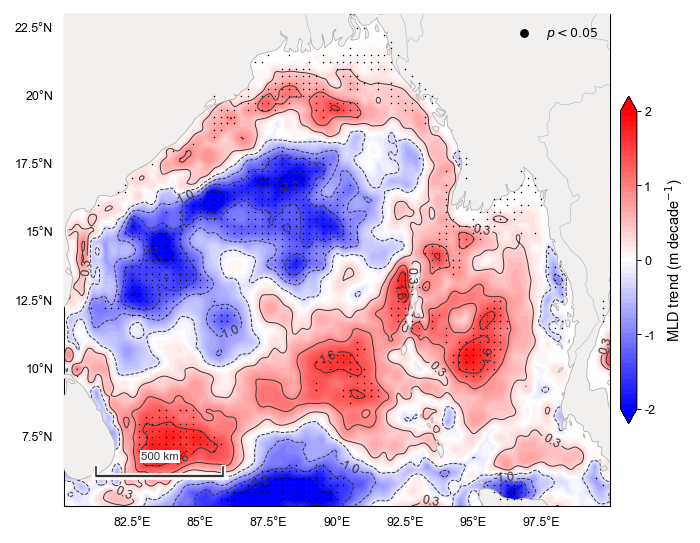

In [264]:
# per-cell trend map
t_years = (mld_series.index - mld_series.index[0]).days/365.25
a3 = (cube["mld"].groupby("time.month")
      - cube["mld"].groupby("time.month").mean("time")).values
ny, nx = a3.shape[1], a3.shape[2]
slope_map = np.full((ny, nx), np.nan); p_map = np.full((ny, nx), np.nan)
for i in range(ny):
    for j in range(nx):
        slope_map[i,j], p_map[i,j], _ = sen_mk(t_years, a3[:,i,j])

trend_ds = xr.Dataset({"trend": (("lat","lon"), slope_map*10),
                       "p_value": (("lat","lon"), p_map)},
                      coords={"lat": cube["lat"], "lon": cube["lon"]})
trend_ds["trend"].attrs = {"units":"m decade-1"}
trend_ds.to_netcdf(TAB / "mld_trend_map.nc")

sig = np.isfinite(p_map) & (p_map < .05)
tot = int(np.isfinite(p_map).sum())
print(f"cells with p<0.05: {int(sig.sum())} of {tot} ({100*sig.sum()/max(1,tot):.1f}%)")

# ============ SPATIAL DISTRIBUTION of the MLD trend =======================
# Diverging ramp, because the sign of the trend is the point.
fig, axes = map_axes(1, 1, figsize=(COL1, COL1*0.95))
ax = axes[0, 0]
lim = float(np.nanpercentile(np.abs(slope_map*10), 98))
im = draw_field(ax, slope_map*10, cmap=CMAP_DIV, vmin=-lim, vmax=lim,
                clabel=True, contour_fmt="%.1f")
sig_y, sig_x = np.where(np.isfinite(p_map) & (p_map < 0.05))
kw = {"transform": ccrs.PlateCarree()} if HAS_CARTOPY else {}
ax.scatter(cube["lon"].values[sig_x], cube["lat"].values[sig_y],
           s=0.5, c="k", linewidths=0, zorder=5,
           label=r"$p<0.05$", **kw)
annotate_map(ax)
ax.legend(loc="best", markerscale=6, framealpha=0)
cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.7, fraction=0.03)
tidy_cbar(cb, "MLD trend (m decade$^{-1}$)")
save_fig(fig, "fig07_mld_trend_map")
plt.show()

## 8. EOF modes of MLD variability

  EOF 1:  18.4% of variance
  EOF 2:   9.0% of variance
  EOF 3:   5.9% of variance


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 38 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'E', 'F', 'L', 'N', 'O', 'a', 'b', 'd', 'degree', 'eight', 'five', 'four', 'g', 'glyph00001', 'glyph00002', 'hyphen', 'i', 'k', 'm', 'n', 'nine', 'o', 'one', 'parenleft', 'parenright', 'percent', 'period', 'r', 's', 'seven', 'space', 't', 'three', 'two', 'u', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 16, 17, 19, 20, 21, 22, 23, 24, 26, 2

   saved: fig08_mld_eof_maps.png, fig08_mld_eof_maps.eps (5.7 MB)


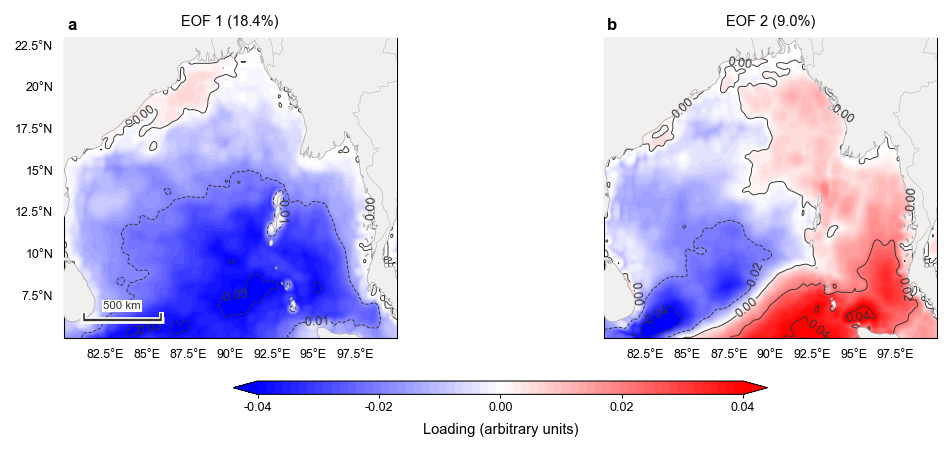

In [273]:
anom_f = (cube["mld"].groupby("time.month")
          - cube["mld"].groupby("time.month").mean("time"))
w = np.sqrt(np.cos(np.deg2rad(cube["lat"]))).broadcast_like(anom_f.isel(time=0))
X = (anom_f*w).stack(cell=("lat","lon")).values
good = np.isfinite(X).all(axis=0)
Xg = X[:, good]; Xg = Xg - Xg.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(Xg, full_matrices=False)
var_expl = S**2/np.sum(S**2)
n_modes = 3
pcs = U[:, :n_modes]*S[:n_modes]

for k in range(n_modes):
    print(f"  EOF {k+1}: {100*var_expl[k]:5.1f}% of variance")
pd.DataFrame(pcs, index=mld_series.index,
             columns=[f"PC{k+1}" for k in range(n_modes)]
             ).to_csv(TAB / "mld_eof_pcs.csv")

# ============ SPATIAL DISTRIBUTION: EOF modes =============================
plot_modes = 2

fig, axes = map_axes(
    1,
    plot_modes,
    figsize=(COL2, COL2 * 0.40)
)

for k in range(plot_modes):
    m = np.full(X.shape[1], np.nan)
    m[good] = Vt[k]
    m = m.reshape(len(cube["lat"]), len(cube["lon"]))

    lim = float(np.nanpercentile(np.abs(m), 98))

    ax = axes[0, k]

    im = draw_field(
        ax, m,
        cmap=CMAP_DIV,
        vmin=-lim,
        vmax=lim,
        left=(k == 0),
        bottom=True,
        n_contours=5
    )

    ax.set_title(f"EOF {k+1} ({100*var_expl[k]:.1f}%)")
    panel_label(ax, "ab"[k])

    if k == 0:
        annotate_map(ax)


fig.subplots_adjust(wspace=0.0001)

cb = fig.colorbar(
    im,
    ax=axes[0, :],
    orientation="horizontal",
    pad=0.06,
    shrink=0.5,
    aspect=40
)

tidy_cbar(cb, "Loading (arbitrary units)")

save_fig(fig, "fig08_mld_eof_maps")
plt.show()

## 9. Objectives 2–4: driver attribution with a GLM

GLM with **explicit interaction terms**, standardised coefficients and HC3
robust standard errors. No gradient boosting, no SHAP.

**SST and SSS are excluded as predictors**: both enter the potential-density
calculation behind the 0.03 kg m⁻³ threshold that *defines* MLD, so regressing
MLD on them is partly circular. Interactions are re-pointed onto **P−E**.

Coefficients are in **metres of MLD per one standard deviation**. Report the
**blocked** cross-validation R².

In [285]:
EXCLUDED_CIRCULAR = ["sst", "sss"]   # enter the density that defines MLD
PREDICTORS = [p for p in ["tau_mag","wind_speed_cubed","ekman_pumping","qnet",
                          "p_minus_e","eke","sla"]
              if p in df.columns]
PREDICTORS_LABELS = ["Wind Stress", "Wind Speed Cubed", "Ekman Pumping", "Net Heat Flux", "P-E", "EKE", "SLA"]
PREDICTORS_DICT = dict(zip(PREDICTORS, PREDICTORS_LABELS))
print("excluded as circular with the MLD criterion:", EXCLUDED_CIRCULAR)
TARGET = "mld"
print("predictors:", PREDICTORS)
missing = set(["tau_mag","qnet","p_minus_e","eke"]) - set(PREDICTORS)
if missing: print("  absent from the cube:", sorted(missing))

work = df.dropna(subset=[TARGET]+PREDICTORS).copy()
print(f"{len(work):,} complete rows")

# deseasonalise PER CELL, not basin-wide: a basin-wide monthly mean would leave
# the spatial pattern of the seasonal cycle in the anomalies
g = work.groupby(["lat","lon","month"], observed=True)
for c in [TARGET]+PREDICTORS:
    work[c] = work[c] - g[c].transform("mean")
print("deseasonalised per grid cell")

excluded as circular with the MLD criterion: ['sst', 'sss']
predictors: ['tau_mag', 'wind_speed_cubed', 'ekman_pumping', 'qnet', 'p_minus_e', 'eke', 'sla']
1,244,400 complete rows
deseasonalised per grid cell


variance inflation factors:
  tau_mag                4.62
  wind_speed_cubed       4.21
  qnet                   1.74
  p_minus_e              1.48
  ekman_pumping          1.02
  sla                    1.01
  eke                    1.00


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 46 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'C', 'D', 'E', 'F', 'H', 'K', 'L', 'N', 'P', 'S', 'W', 'a', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'glyph00001', 'glyph00002', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 2

   saved: fig12_predictor_correlation.png, fig12_predictor_correlation.eps (7.4 MB)


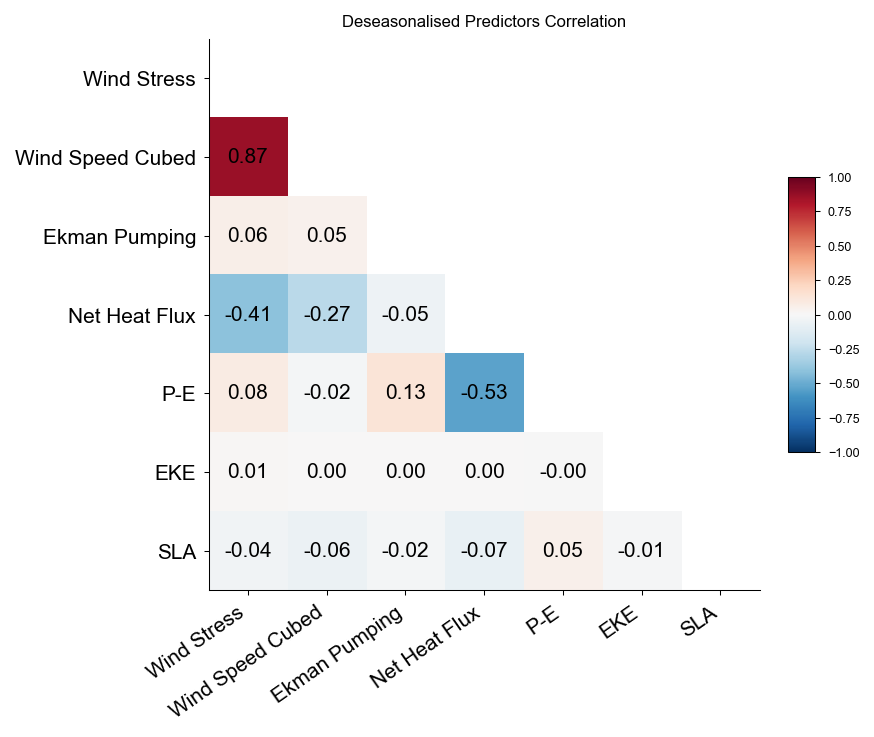

['tau_mag', 'wind_speed_cubed', 'ekman_pumping', 'qnet', 'p_minus_e', 'eke', 'sla']


In [308]:
# collinearity screen: correlated predictors share explanatory credit and
# inflate each other's standard errors in the GLM
def vif_table(X):
    from numpy.linalg import lstsq
    rows = []
    for c in X.columns:
        others = X.drop(columns=c).values
        A = np.column_stack([np.ones(len(others)), others])
        beta, *_ = lstsq(A, X[c].values, rcond=None)
        r2 = 1 - (X[c].values - A@beta).var()/X[c].values.var()
        rows.append({"predictor": c, "VIF": 1/max(1e-9, 1-r2)})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif = vif_table(work[PREDICTORS])
vif.to_csv(TAB / "vif_basin.csv", index=False)
print("variance inflation factors:")
for _, r in vif.iterrows():
    print(f"  {r.predictor:<18} {r.VIF:8.2f}"
          + ("   <- shares attribution" if r.VIF > 10 else ""))

corr = work[PREDICTORS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
masked_corr = corr.where(~mask)
fig, ax = plt.subplots(figsize=(5.6, 4.8), constrained_layout=True)
im = ax.imshow(masked_corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(PREDICTORS))); ax.set_yticks(range(len(PREDICTORS)))
ax.set_xticklabels(PREDICTORS_LABELS, rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(PREDICTORS_LABELS, fontsize=10)
for i in range(len(PREDICTORS)):
    for j in range(len(PREDICTORS)):
        if mask[i, j]: continue
        val = corr.iloc[i, j]
        if not np.isnan(val):
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title("Deseasonalised Predictors Correlation", fontsize=8); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.5, fraction=0.05, aspect=10)
save_fig(fig, "fig12_predictor_correlation")
plt.show()
print(PREDICTORS)

In [ ]:
def spatial_blocks(d, n=5):
    """Contiguous lat/lon blocks so a fold never straddles a neighbour."""
    nb = int(np.ceil(np.sqrt(n)))
    return (pd.qcut(d.lat, nb, labels=False, duplicates="drop")*nb
            + pd.qcut(d.lon, nb, labels=False, duplicates="drop")).astype(int)

def r2(y, yhat):
    return 1 - np.sum((y-yhat)**2)/np.sum((y-y.mean())**2)

# ===================== GLM ATTRIBUTION (replaces XGBoost/SHAP) ============
# A GLM is additive by construction, so the conditional effects the
# observational literature reports (wind deepening damped under a strong
# halocline; eddy mixing strongest where stratification is weak) only appear
# if the product terms are entered EXPLICITLY. They are, below.
#
# Attribution uses STANDARDISED coefficients: every predictor is z-scored, so
# beta is the change in MLD (m) per one standard deviation of that predictor
# and coefficients are directly comparable. Standard errors are
# heteroscedasticity-consistent (HC3), because residual variance varies
# strongly across the basin.

# SST and SSS are EXCLUDED as predictors: both enter the potential-density
# calculation that defines the 0.03 kg m-3 MLD criterion, so regressing MLD on
# them is partly circular and would inflate skill without explaining anything.
#
# That removes the stratification state variable the interactions were built
# on, so the conditional terms are re-pointed onto p_minus_e, the surface
# freshwater FORCING that creates the halocline in the first place. It is
# external to the MLD definition, so the interaction claim survives without
# the circularity. Barrier layer thickness would be the stronger proxy if you
# later compute it from the ORAS5 profiles.
STRAT_PROXY = "p_minus_e"
INTERACTIONS = [("tau_mag", STRAT_PROXY), ("eke", STRAT_PROXY),
                ("qnet", STRAT_PROXY), ("ekman_pumping", STRAT_PROXY)]
INTERACTIONS_LABEL = [("Wind Stress", "P-E"),("EKE", "P-E"),("Net Heat Flux", "P-E"),
                      ("Ekman Pumping", "P-E"),]

def build_design(d, preds, interactions=INTERACTIONS):
    """z-scored predictors plus explicit product terms."""
    Z = d[preds].astype(float)
    mu, sd = Z.mean(), Z.std(ddof=0).replace(0, np.nan)
    Z = (Z - mu) / sd
    names = list(preds)
    for a, b in interactions:
        if a in preds and b in preds:
            col = f"{PREDICTORS_DICT[a]} x {PREDICTORS_DICT[b]}"
            Z[col] = Z[a] * Z[b]
            names.append(col)
    return Z[names], mu, sd

def ols_hc3(X, y):
    """OLS with HC3 robust standard errors. No statsmodels dependency."""
    X = np.asarray(X, float); y = np.asarray(y, float)
    n, k = X.shape
    A = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.pinv(A.T @ A)
    beta = XtX_inv @ A.T @ y
    resid = y - A @ beta
    h = np.einsum("ij,jk,ik->i", A, XtX_inv, A)          # leverage
    omega = (resid / np.clip(1 - h, 1e-8, None))**2       # HC3 weights
    cov = XtX_inv @ (A.T * omega) @ A @ XtX_inv
    se = np.sqrt(np.diag(cov))
    r2 = 1 - resid @ resid / ((y - y.mean()) @ (y - y.mean()))
    return beta, se, r2, resid

def fit_glm(d, preds, label):
    Z, mu, sd = build_design(d, preds)
    y = d[TARGET].astype(float)
    ok = np.isfinite(Z).all(axis=1) & np.isfinite(y)
    Z, y = Z[ok], y[ok]

    beta, se, r2_in, resid = ols_hc3(Z.values, y.values)
    names = ["intercept"] + list(Z.columns)
    tstat = beta / np.where(se > 0, se, np.nan)
    from scipy.stats import norm as _norm
    pval = 2 * _norm.sf(np.abs(tstat))

    tab = pd.DataFrame({
        "term": names, "beta_m_per_sd": beta, "se": se,
        "ci_lo": beta - 1.96*se, "ci_hi": beta + 1.96*se,
        "t": tstat, "p": pval,
    })
    main = tab[tab.term != "intercept"].copy()
    main["abs_beta"] = main.beta_m_per_sd.abs()
    main["share_%"] = 100*main.abs_beta/main.abs_beta.sum()
    main = main.sort_values("abs_beta", ascending=False)

    # spatially blocked cross-validation, same folds logic as before
    from sklearn.model_selection import GroupKFold, KFold
    groups = spatial_blocks(d[ok.values])
    blocked, leaky = [], []
    for tr, te in GroupKFold(n_splits=min(5, groups.nunique())).split(Z, y, groups):
        b, *_ = ols_hc3(Z.values[tr], y.values[tr])
        pred = np.column_stack([np.ones(len(te)), Z.values[te]]) @ b
        blocked.append(1 - np.sum((y.values[te]-pred)**2) /
                           np.sum((y.values[te]-y.values[te].mean())**2))
    for tr, te in KFold(5, shuffle=True, random_state=0).split(Z):
        b, *_ = ols_hc3(Z.values[tr], y.values[tr])
        pred = np.column_stack([np.ones(len(te)), Z.values[te]]) @ b
        leaky.append(1 - np.sum((y.values[te]-pred)**2) /
                         np.sum((y.values[te]-y.values[te].mean())**2))

    print(f"\n--- GLM: {label}  (n = {len(y):,}) ---")
    print(f"  in-sample R2  : {r2_in:.3f}")
    print(f"  blocked CV R2 : {np.mean(blocked):.3f} +/- {np.std(blocked):.3f}"
          f"   <- REPORT THIS")
    print(f"  random  CV R2 : {np.mean(leaky):.3f} +/- {np.std(leaky):.3f}"
          f"   (leaky, for comparison only)")
    print(f"  inflation     : {np.mean(leaky)-np.mean(blocked):+.3f}")
    print(f"\n  {'term':<24}{'beta (m/SD)':>13}{'95% CI':>22}{'p':>10}{'share':>8}")
    for _, r in main.iterrows():
        star = "*" if r.p < 0.05 else " "
        print(f"  {r.term:<24}{r.beta_m_per_sd:>13.3f}"
              f"{f'[{r.ci_lo:+.3f}, {r.ci_hi:+.3f}]':>22}"
              f"{r.p:>10.3g}{star}{r['share_%']:>7.1f}%")
    tab.to_csv(TAB / f"glm_coefficients_{label}.csv", index=False)
    return tab, main, np.mean(blocked), np.mean(leaky), r2_in

glm_basin, main_basin, r2b, r2r, r2in = fit_glm(work, PREDICTORS, "basin")



--- GLM: basin  (n = 1,244,400) ---
  in-sample R2  : 0.123
  blocked CV R2 : 0.107 +/- 0.056   <- REPORT THIS
  random  CV R2 : 0.123 +/- 0.001   (leaky, for comparison only)
  inflation     : +0.017

  term                      beta (m/SD)                95% CI         p   share
  sla                             0.941      [+0.930, +0.952]         0*   20.1%
  tau_mag                         0.916      [+0.896, +0.936]         0*   19.6%
  qnet                           -0.839      [-0.853, -0.825]         0*   17.9%
  p_minus_e                      -0.707      [-0.718, -0.695]         0*   15.1%
  wind_speed_cubed                0.640      [+0.619, +0.662]         0*   13.7%
  ekman_pumping                  -0.280      [-0.292, -0.268]         0*    6.0%
  eke                            -0.171      [-0.182, -0.160] 1.34e-209*    3.7%
  Wind Stress x P-E              -0.103      [-0.112, -0.093]  9.15e-99*    2.2%
  EKE x P-E                      -0.033      [-0.042, -0.024]  6.65e-

['Net Heat Flux', 'P-E', 'Ekman Pumping', 'EKE', 'Wind Stress x P-E', 'EKE x P-E', 'Net Heat Flux x P-E', 'Ekman Pumping x P-E', 'Wind Speed Cubed', 'Wind Stress', 'SLA']


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 47 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'C', 'D', 'E', 'F', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'S', 'W', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'g', 'glyph00001', 'glyph00002', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'space', 't', 'two', 'u', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 

   saved: fig10_glm_coefficients.png, fig10_glm_coefficients.eps (0.1 MB)


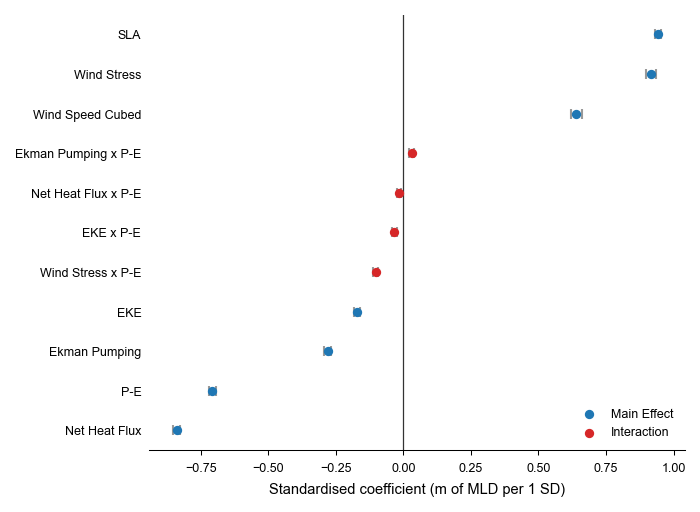

Filled markers with 95% CI crossing zero are not distinguishable from
no effect. Red terms are the interactions: if they are significant, an
additive-only model is mis-specified, which is the methodological
claim made in the literature review.
4                    qnet
5               p_minus_e
3           ekman_pumping
6                     eke
8       Wind Stress x P-E
9               EKE x P-E
10    Net Heat Flux x P-E
11    Ekman Pumping x P-E
2        wind_speed_cubed
1                 tau_mag
7                     sla
Name: term, dtype: object


In [321]:
# ============ GLM coefficient (forest) plot ===============================
m = main_basin.sort_values("beta_m_per_sd")
term_labels = [PREDICTORS_DICT.get(item, item) for item in m.term]
print(term_labels)
is_int = m.term.str.contains(" * ")
colors = np.where(is_int, "#d62728", "#1f77b4")

fig, ax = plt.subplots(figsize=(COL1, 0.20*len(m)+1.1), constrained_layout=True)
ax.errorbar(m.beta_m_per_sd, np.arange(len(m)),
            xerr=[m.beta_m_per_sd-m.ci_lo, m.ci_hi-m.beta_m_per_sd],
            fmt="none", ecolor="#999999", elinewidth=0.7, capsize=2.5)
for lbl, mask, c in [("Main Effect", ~is_int, "#1f77b4"),
                     ("Interaction", is_int, "#d62728")]:
    idx = np.where(mask)[0]
    if len(idx):
        ax.scatter(m.beta_m_per_sd.values[idx], idx, s=12, color=c,
                   zorder=3, label=lbl)
ax.axvline(0, color="#333333", lw=0.6)
ax.set_yticks(np.arange(len(m))); ax.set_yticklabels(term_labels)
ax.set_xlabel("Standardised coefficient (m of MLD per 1 SD)")
ax.legend(loc="lower right")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save_fig(fig, "fig10_glm_coefficients")
plt.show()

print("Filled markers with 95% CI crossing zero are not distinguishable from")
print("no effect. Red terms are the interactions: if they are significant, an")
print("additive-only model is mis-specified, which is the methodological")
print("claim made in the literature review.")
print(m.term)


--- GLM: north  (n = 148,500) ---
  in-sample R2  : 0.048
  blocked CV R2 : 0.045 +/- 0.009   <- REPORT THIS
  random  CV R2 : 0.048 +/- 0.003   (leaky, for comparison only)
  inflation     : +0.003

  term                      beta (m/SD)                95% CI         p   share
  sla                             0.586      [+0.558, +0.614]         0*   25.3%
  qnet                           -0.457      [-0.491, -0.422] 9.07e-147*   19.7%
  wind_speed_cubed                0.400      [+0.367, +0.432] 3.93e-130*   17.2%
  p_minus_e                      -0.353      [-0.376, -0.330] 4.75e-199*   15.2%
  tau_mag                         0.310      [+0.281, +0.338]  2.75e-99*   13.3%
  eke                             0.101      [+0.077, +0.126]  3.53e-16*    4.4%
  Wind Stress x P-E              -0.044      [-0.059, -0.029]  8.18e-09*    1.9%
  EKE x P-E                      -0.026      [-0.045, -0.007]   0.00747*    1.1%
  Net Heat Flux x P-E             0.026      [+0.011, +0.040]  0.000737

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 45 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'C', 'D', 'E', 'F', 'H', 'K', 'L', 'M', 'N', 'P', 'S', 'W', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'g', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'space', 't', 'u', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 24, 36, 38, 39, 

   saved: fig11_glm_by_subbasin.png, fig11_glm_by_subbasin.eps (0.1 MB)


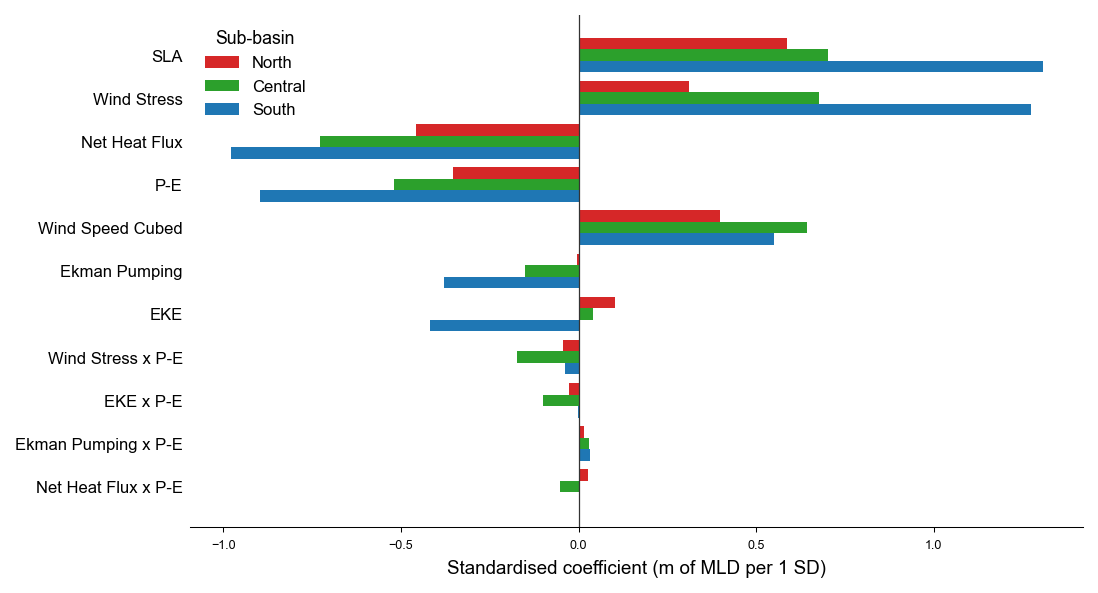


If the leading term differs between sub-basins, that is the headline
result for Objective 3.

corr(tau_mag, MLD) | low  P-E (weak stratification): +0.324  n=311,100
corr(tau_mag, MLD) | high P-E (strong stratification): +0.293  n=311,100
difference: +0.031
A large difference is evidence that wind-driven deepening is damped
under a fresh surface layer, which is the mechanism the literature
reports and which an additive-only model cannot capture.


In [327]:
# ============ Objective 3: does the dominant driver differ by sub-basin? ===
summary = [{"region": "basin", "n": len(work), "r2_blocked": r2b,
            "r2_random": r2r, "r2_in_sample": r2in,
            "top_term": main_basin.iloc[0].term,
            "top_beta": main_basin.iloc[0].beta_m_per_sd,
            "top_share_%": main_basin.iloc[0]["share_%"]}]
region_main = {"basin": main_basin}

for region in ["north", "central", "south"]:
    sub = work[work.sub_basin == region]
    if len(sub) < 5000:
        print(f"  {region}: only {len(sub)} rows, skipped"); continue
    tab, mn, rb, rr, rin = fit_glm(sub, PREDICTORS, region)
    region_main[region] = mn
    summary.append({"region": region, "n": len(sub), "r2_blocked": rb,
                    "r2_random": rr, "r2_in_sample": rin,
                    "top_term": mn.iloc[0].term,
                    "top_beta": mn.iloc[0].beta_m_per_sd,
                    "top_share_%": mn.iloc[0]["share_%"]})

summ = pd.DataFrame(summary)
summ.to_csv(TAB / "glm_attribution_summary.csv", index=False)
print("\n" + "="*74); print("GLM ATTRIBUTION SUMMARY"); print("="*74)
print(summ.round(3).to_string(index=False))

# grouped comparison of standardised coefficients across sub-basins
regs = [r for r in ["north","central","south"] if r in region_main]
if regs:
    terms = list(region_main["basin"].term)
    terms_labels = [PREDICTORS_DICT.get(item, item) for item in terms]
    fig, ax = plt.subplots(figsize=(COL2, 0.24*len(terms)+1.2),
                           constrained_layout=True)
    hgt = 0.8/len(regs)
    for i, r in enumerate(regs):
        mm = region_main[r].set_index("term").reindex(terms)
        pos = np.arange(len(terms)) + (i-(len(regs)-1)/2)*hgt
        ax.barh(pos, mm.beta_m_per_sd, height=hgt, color=COLS[r], label=r.capitalize())
    ax.axvline(0, color="#333333", lw=0.6)
    ax.set_yticks(np.arange(len(terms))); ax.set_yticklabels(terms_labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Standardised coefficient (m of MLD per 1 SD)", fontsize = 9)
    ax.legend(title="Sub-basin", loc="best", fontsize=8, title_fontsize= 8.5)
    ax.spines["left"].set_visible(False); ax.tick_params(axis="y", length=0)
    save_fig(fig, "fig11_glm_by_subbasin")
    plt.show()
print("\nIf the leading term differs between sub-basins, that is the headline")
print("result for Objective 3.")

# Direct, model-free check of the conditionality that motivates the
# interaction terms: does the wind-MLD relationship change with freshwater
# forcing? A sign change cannot be represented by an additive model.
if {"tau_mag", STRAT_PROXY} <= set(PREDICTORS):
    lo = work[work[STRAT_PROXY] < work[STRAT_PROXY].quantile(.25)]
    hi = work[work[STRAT_PROXY] > work[STRAT_PROXY].quantile(.75)]
    r_lo = np.corrcoef(lo.tau_mag, lo[TARGET])[0, 1]
    r_hi = np.corrcoef(hi.tau_mag, hi[TARGET])[0, 1]
    print(f"\ncorr(tau_mag, MLD) | low  P-E (weak stratification): {r_lo:+.3f}"
          f"  n={len(lo):,}")
    print(f"corr(tau_mag, MLD) | high P-E (strong stratification): {r_hi:+.3f}"
          f"  n={len(hi):,}")
    print(f"difference: {r_lo-r_hi:+.3f}")
    print("A large difference is evidence that wind-driven deepening is damped")
    print("under a fresh surface layer, which is the mechanism the literature")
    print("reports and which an additive-only model cannot capture.")

## 9b. Download the Argo profiles

Run once. Fetched **year by year** and resumable: a request spanning two
decades over this box times out on the GDAC and ERDDAP servers, and a failure
at 90% would otherwise lose everything. Existing yearly files are skipped, so
re-running only retries what failed.

    pip install argopy gsw

In [38]:
"""
download_argo.py | Argo profiles for the Bay of Bengal, chunked and resumable.

Notebook-friendly: no argparse. Run the whole file, or import and call.

    download_argo()                 # fetch, year by year
    ds = merge_argo()               # combine into one file
    report_argo(ds)                 # coverage, QC and density summary

WHY YEARLY CHUNKS
One request for 5-23N, 80-100E across two decades is tens of thousands of
profiles. The GDAC and ERDDAP servers time out on requests that size, and a
failure at 90% loses everything. Each year is fetched and written separately,
existing files are skipped, so an interrupted run resumes where it stopped.

WHY THE SOURCE FALLS BACK
argopy can read from the GDAC mirrors or from the Ifremer ERDDAP service.
Either can be slow or briefly unavailable. Each year is retried on the next
source before the run gives up on it, and a year that fails entirely is
reported at the end rather than aborting the others.

    pip install argopy gsw netcdf4
"""

import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------ config
OUT_DIR   = Path("raw/argo")
YEAR_DIR  = OUT_DIR / "by_year"
MERGED    = OUT_DIR / "argo_bob_2000_2020.nc"

LON_MIN, LON_MAX = 80.0, 100.0
LAT_MIN, LAT_MAX = 5.0, 23.0
PRES_MIN, PRES_MAX = 0.0, 500.0        # top 500 m is enough for MLD
YEAR_START, YEAR_END = 2000, 2020      # Argo is sparse before ~2003 here

SOURCES = ["gdac", "erddap"]           # tried in order
MAX_RETRIES = 2
RETRY_WAIT = 20                        # seconds


def _fetch_one_year(year, source):
    import argopy
    argopy.set_options(src=source, mode="standard")
    box = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX, PRES_MIN, PRES_MAX,
           f"{year}-01-01", f"{year+1}-01-01"]
    f = argopy.DataFetcher(parallel=True).region(box)
    ds = f.data
    return ds.argo.point2profile()


def download_argo(year_start=YEAR_START, year_end=YEAR_END, overwrite=False):
    YEAR_DIR.mkdir(parents=True, exist_ok=True)
    failed, done = [], []

    for year in range(year_start, year_end + 1):
        target = YEAR_DIR / f"argo_bob_{year}.nc"
        if target.exists() and not overwrite:
            try:
                with xr.open_dataset(target) as d:
                    n = d.sizes.get("N_PROF", 0)
                print(f"  {year}  skip, already have {n} profiles")
                done.append(year)
                continue
            except Exception:
                print(f"  {year}  existing file unreadable, refetching")
                target.unlink(missing_ok=True)

        ok = False
        for source in SOURCES:
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    t0 = time.time()
                    ds = _fetch_one_year(year, source)
                    n = ds.sizes.get("N_PROF", 0)
                    if n == 0:
                        print(f"  {year}  no profiles from {source}")
                        ok = True
                        break
                    ds.to_netcdf(target)
                    print(f"  {year}  {n:>5} profiles from {source} "
                          f"({time.time()-t0:.0f}s)")
                    ok = True
                    break
                except Exception as e:
                    msg = f"{type(e).__name__}: {str(e)[:70]}"
                    if attempt < MAX_RETRIES:
                        print(f"  {year}  {source} attempt {attempt} failed "
                              f"({msg}), retrying in {RETRY_WAIT}s")
                        time.sleep(RETRY_WAIT)
                    else:
                        print(f"  {year}  {source} gave up: {msg}")
            if ok:
                break
        (done if ok else failed).append(year)

    print(f"\ncompleted {len(done)} year(s); {len(failed)} failed")
    if failed:
        print(f"  failed: {failed}")
        print("  re-run download_argo() to retry only those years")
    return done, failed


def merge_argo(out=MERGED):
    """Concatenate the yearly files into one profile dataset."""
    files = sorted(YEAR_DIR.glob("argo_bob_*.nc"))
    if not files:
        raise SystemExit(f"no yearly files in {YEAR_DIR}; run download_argo()")
    parts = []
    for f in files:
        try:
            parts.append(xr.open_dataset(f))
        except Exception as e:
            print(f"  skipping unreadable {f.name}: {type(e).__name__}")
    if not parts:
        raise SystemExit("no readable yearly files")

    ds = xr.concat(parts, dim="N_PROF")
    # a float can be reported by more than one source; drop exact duplicates
    key = pd.DataFrame({
        "t": pd.to_datetime(np.asarray(ds["TIME"])) if "TIME" in ds
             else pd.to_datetime(np.asarray(ds["JULD"])),
        "lat": np.asarray(ds["LATITUDE"]).round(4),
        "lon": np.asarray(ds["LONGITUDE"]).round(4),
    })
    keep = np.where(~key.duplicated())[0]
    if len(keep) < ds.sizes["N_PROF"]:
        print(f"  removed {ds.sizes['N_PROF']-len(keep)} duplicate profiles")
        ds = ds.isel(N_PROF=keep)

    ds.attrs["title"] = "Argo profiles, Bay of Bengal"
    ds.attrs["history"] = (f"{pd.Timestamp.utcnow():%Y-%m-%dT%H:%M:%SZ}: "
                           f"downloaded with argopy and merged "
                           f"(download_argo.py)")
    ds.attrs["region"] = (f"{LAT_MIN}-{LAT_MAX}N, {LON_MIN}-{LON_MAX}E, "
                          f"0-{PRES_MAX:.0f} dbar")
    out.parent.mkdir(parents=True, exist_ok=True)
    ds.to_netcdf(out)
    print(f"\nwrote {out}  ({ds.sizes['N_PROF']:,} profiles, "
          f"{out.stat().st_size/2**20:.1f} MiB)")
    return ds


def report_argo(ds=None, path=MERGED):
    """Coverage, QC and spatial density. The density map is the confidence map."""
    if ds is None:
        ds = xr.open_dataset(path)
    n = ds.sizes.get("N_PROF", 0)
    t = pd.to_datetime(np.asarray(ds["TIME"] if "TIME" in ds else ds["JULD"]))
    lat = np.asarray(ds["LATITUDE"]); lon = np.asarray(ds["LONGITUDE"])

    print(f"profiles           : {n:,}")
    print(f"period             : {t.min():%Y-%m} -> {t.max():%Y-%m}")
    print(f"latitude range     : {lat.min():.2f} .. {lat.max():.2f} N")
    print(f"longitude range    : {lon.min():.2f} .. {lon.max():.2f} E")

    per_year = pd.Series(1, index=t).resample("YE").sum()
    print("\nprofiles per year:")
    for y, c in per_year.items():
        bar = "#" * int(40*c/max(1, per_year.max()))
        print(f"  {y.year}  {int(c):>5}  {bar}")

    for v in ("PRES", "TEMP", "PSAL"):
        for name in (f"{v}_ADJUSTED", v):
            if name in ds:
                arr = np.asarray(ds[name])
                print(f"{name:<16} {100*np.isfinite(arr).mean():5.1f}% finite")
                break

    lat_e = np.arange(LAT_MIN, LAT_MAX + 1, 1.0)
    lon_e = np.arange(LON_MIN, LON_MAX + 1, 1.0)
    cnt, _, _ = np.histogram2d(lat, lon, bins=[lat_e, lon_e])
    print(f"\n1-degree cells with no profiles: {int((cnt==0).sum())} of {cnt.size}")
    north = cnt[lat_e[:-1] >= 18, :]
    south = cnt[lat_e[:-1] < 12, :]
    print(f"  median per cell, north (>=18N): {np.median(north):.0f}")
    print(f"  median per cell, south (<12N) : {np.median(south):.0f}")
    print("\nA much lower count in the north is expected and is the quantified")
    print("basis for the spatial confidence caveat in Chapter 2.")
    return ds

In [39]:
# Run the download. Expect 20-60 min on a first full pass.
done, failed = download_argo()
if not failed:
    argo_ds = merge_argo()
    report_argo(argo_ds)
else:
    print("re-run this cell to retry the failed years")

  2000  gdac attempt 1 failed (GdacPathError: Index file does not exist: https://data-argo.ifremer.fr/ar_index_globa), retrying in 20s
  2000  gdac gave up: GdacPathError: Index file does not exist: https://data-argo.ifremer.fr/ar_index_globa
  2000  erddap attempt 1 failed (ValueError: An un-expected error occurred with all URLs, check log file for more i), retrying in 20s
  2000  erddap gave up: ValueError: An un-expected error occurred with all URLs, check log file for more i
  2001  gdac attempt 1 failed (GdacPathError: Index file does not exist: https://data-argo.ifremer.fr/ar_index_globa), retrying in 20s
  2001  gdac gave up: GdacPathError: Index file does not exist: https://data-argo.ifremer.fr/ar_index_globa
  2001  erddap attempt 1 failed (ValueError: An un-expected error occurred with all URLs, check log file for more i), retrying in 20s
  2001  erddap gave up: ValueError: An un-expected error occurred with all URLs, check log file for more i
  2002  skip, already have 47 pr

KeyboardInterrupt: 

## 10. Objective 5: validation against Argo profiles

MLD is computed **identically on both sides**: TEOS-10 potential density, 10 m
reference, 0.03 kg m⁻³ threshold, applied per profile. Averaging profiles first
produces the 25% shallow bias reported by de Boyer Montégut et al. (2004).

ORAS5 assimilates Argo, so this is not fully independent. The useful signal is
**spatial**: where profiles are dense the reanalysis is constrained; where they
are sparse it runs closer to free. Report the agreement and the density together.

In [85]:
REF_DEPTH, THRESHOLD = 10.0, 0.03

def mld_from_profile(pres, temp, psal, lon, lat):
    import gsw
    ok = np.isfinite(pres) & np.isfinite(temp) & np.isfinite(psal)
    if ok.sum() < 5: return np.nan
    p, t, s = pres[ok], temp[ok], psal[ok]
    o = np.argsort(p); p, t, s = p[o], t[o], s[o]
    if p[0] > 15.0: return np.nan          # no near-surface reference
    SA = gsw.SA_from_SP(s, p, lon, lat)
    sigma0 = gsw.sigma0(SA, gsw.CT_from_t(SA, t, p))
    excess = sigma0 - (np.interp(REF_DEPTH, p, sigma0) + THRESHOLD)
    idx = np.where(excess > 0)[0]
    if idx.size == 0: return np.nan        # never stratified enough
    k = idx[0]
    if k == 0: return float(p[0])
    return float(p[k-1] + (p[k]-p[k-1])*(-excess[k-1])/(excess[k]-excess[k-1]))

argo = None
if ARGO_IN.exists() and OPTIONAL["gsw"]:
    a = xr.open_dataset(ARGO_IN)
    dim = "N_PROF" if "N_PROF" in a.dims else list(a.dims)[0]
    def g(*names):
        for n in names:
            if n in a: return a[n].values
        raise KeyError(names)
    pres, temp, psal = g("PRES_ADJUSTED","PRES"), g("TEMP_ADJUSTED","TEMP"), g("PSAL_ADJUSTED","PSAL")
    lat_a, lon_a = np.asarray(g("LATITUDE")), np.asarray(g("LONGITUDE"))
    time_a = pd.to_datetime(g("TIME","JULD"))
    recs = []
    for i in range(a.sizes[dim]):
        m = mld_from_profile(np.asarray(pres[i],float), np.asarray(temp[i],float),
                             np.asarray(psal[i],float), float(lon_a[i]), float(lat_a[i]))
        if np.isfinite(m):
            recs.append({"time":time_a[i], "lat":lat_a[i], "lon":lon_a[i], "mld_argo":m})
    argo = pd.DataFrame(recs)
    print(f"  {a.sizes[dim]} profiles -> {len(argo)} valid MLD "
          f"({100*len(argo)/max(1,a.sizes[dim]):.1f}%)")
elif not OPTIONAL["gsw"]:
    print("gsw required for TEOS-10 density: pip install gsw")
else:
    print(f"{ARGO_IN} not found; skipping validation")

  27732 profiles -> 26205 valid MLD (94.5%)


  26,205 matched pairs
       group     n  argo_mean  oras5_mean  bias_m  rmse_m  corr
         all 26205      24.31   27.840000    3.53   12.50  0.57
       north  2500      17.08   21.049999    3.98   10.99  0.26
     central 14256      23.59   27.469999    3.87   12.55  0.56
       south  9449      27.32   30.209999    2.89   12.80  0.56
      Winter  6920      26.49   33.189999    6.70   15.96  0.45
 Pre-monsoon  5735      18.01   18.650000    0.63    7.56  0.49
     Monsoon  9076      28.86   32.590000    3.73   13.21  0.55
Post-monsoon  4474      19.79   21.740000    1.94    9.73  0.43


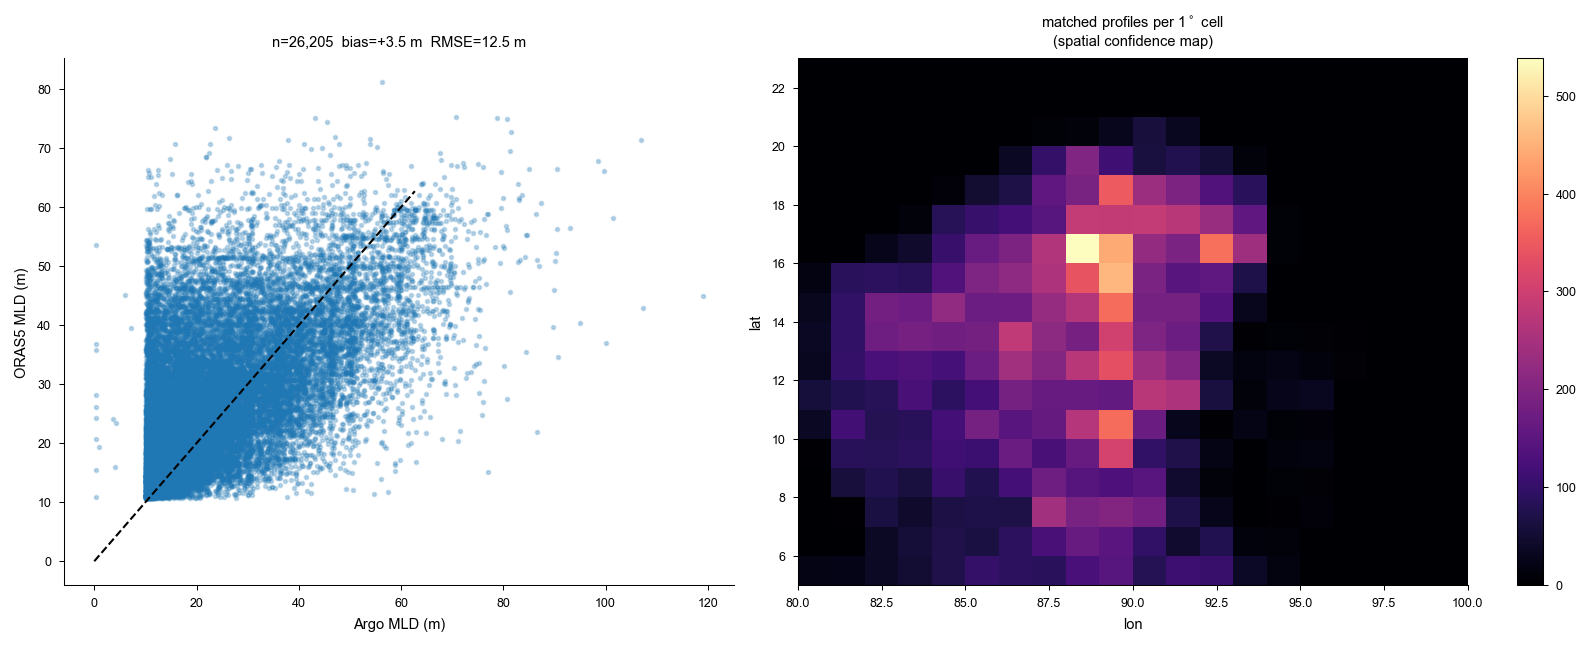


cells with no profiles: 135 of 360
If the northern bay shows both the largest error and the lowest
profile count, that is the quantified spatial caveat for Limitations.


In [206]:
if argo is not None and len(argo):
    argo["time_m"] = pd.PeriodIndex(argo["time"], freq="M").to_timestamp()
    lat_g, lon_g = cube["lat"].values, cube["lon"].values
    argo["lat_g"] = lat_g[np.abs(argo.lat.values[:,None]-lat_g).argmin(axis=1)]
    argo["lon_g"] = lon_g[np.abs(argo.lon.values[:,None]-lon_g).argmin(axis=1)]
    keep = argo.time_m.isin(pd.to_datetime(cube.time.values))
    argo = argo[keep]
    sel = cube["mld"].sel(time=xr.DataArray(argo.time_m.values, dims="obs"),
                          lat=xr.DataArray(argo.lat_g.values, dims="obs"),
                          lon=xr.DataArray(argo.lon_g.values, dims="obs"))
    argo["mld_oras5"] = np.asarray(sel)
    m = argo.dropna(subset=["mld_oras5","mld_argo"])
    m["sub_basin"] = np.where(m.lat_g >= LAT_N_MIN, "north",
                       np.where(m.lat_g >= LAT_C_MIN, "central", "south"))
    m["season"] = m["time"].dt.month.map(SEASONS)
    print(f"  {len(m):,} matched pairs")

    def blk(d, label):
        a_, o_ = d.mld_argo.values, d.mld_oras5.values
        return {"group":label, "n":len(d), "argo_mean":a_.mean(),
                "oras5_mean":o_.mean(), "bias_m":np.mean(o_-a_),
                "rmse_m":np.sqrt(np.mean((o_-a_)**2)),
                "corr":np.corrcoef(a_,o_)[0,1] if len(d)>2 else np.nan}
    rows = [blk(m,"all")]
    for gname in ["north","central","south"]:
        d = m[m.sub_basin==gname]
        if len(d) > 20: rows.append(blk(d, gname))
    for gname in SEASON_ORDER:
        d = m[m.season==gname]
        if len(d) > 20: rows.append(blk(d, gname))
    val = pd.DataFrame(rows)
    val.to_csv(TAB / "argo_validation.csv", index=False)
    print(val.round(2).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
    axes[0].scatter(m.mld_argo, m.mld_oras5, s=3, alpha=.25)
    hi = np.nanpercentile(m[["mld_argo","mld_oras5"]].values, 99)
    axes[0].plot([0,hi],[0,hi],"k--",lw=1)
    axes[0].set(xlabel="Argo MLD (m)", ylabel="ORAS5 MLD (m)",
                title=f"n={len(m):,}  bias={np.mean(m.mld_oras5-m.mld_argo):+.1f} m  "
                      f"RMSE={np.sqrt(np.mean((m.mld_oras5-m.mld_argo)**2)):.1f} m")
    le = np.arange(LAT_MIN, LAT_MAX+1, 1.); lo_ = np.arange(LON_MIN, LON_MAX+1, 1.)
    cnt, _, _ = np.histogram2d(m.lat, m.lon, bins=[le, lo_])
    im = axes[1].pcolormesh(lo_, le, cnt, cmap="magma", shading="auto")
    axes[1].set(xlabel="lon", ylabel="lat",
                title="matched profiles per 1$^\\circ$ cell\n(spatial confidence map)")
    fig.colorbar(im, ax=axes[1])
    fig.savefig(FIG / "argo_validation.png", bbox_inches="tight")
    plt.show()
    print(f"\ncells with no profiles: {int((cnt==0).sum())} of {cnt.size}")
    print("If the northern bay shows both the largest error and the lowest")
    print("profile count, that is the quantified spatial caveat for Limitations.")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 47 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'D', 'E', 'L', 'M', 'O', 'P', 'R', 'S', 'W', 'a', 'b', 'bar', 'c', 'comma', 'e', 'eight', 'equal', 'five', 'four', 'g', 'glyph00001', 'glyph00002', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'o', 'one', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3,

   saved: fig25_argo_validation_groups.png, fig25_argo_validation_groups.eps (3.1 MB)


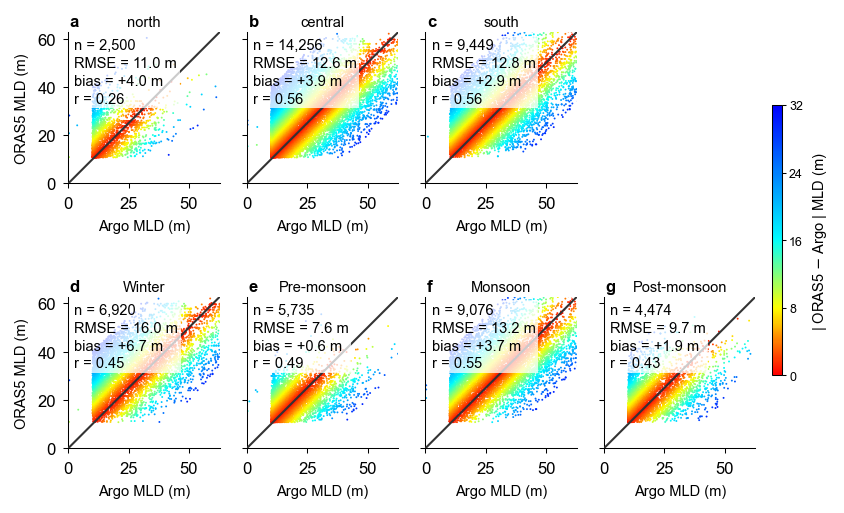

group_type        group     n  bias  rmse    r   mae
 Sub-basin        north  2500  3.98 10.99 0.26  5.65
 Sub-basin      central 14256  3.87 12.55 0.56  7.06
 Sub-basin        south  9449  2.89 12.80 0.56  7.60
    Season       Winter  6920  6.70 15.96 0.45 10.49
    Season  Pre-monsoon  5735  0.63  7.56 0.49  4.15
    Season      Monsoon  9076  3.73 13.21 0.55  8.25
    Season Post-monsoon  4474  1.94  9.73 0.43  5.97


In [223]:
# ===== Objective 5: validation scatter by sub-basin and by season ==========
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

BASIN_GROUPS = ["north", "central", "south"]
SEASON_GROUPS = SEASON_ORDER  # Winter, Pre, Monsoon, Post
MIN_N = 20  # skip groups thinner than this


def _stats(d):
    a, o = d["mld_argo"].values, d["mld_oras5"].values
    return dict(
        n=len(d),
        bias=float(np.mean(o - a)),
        rmse=float(np.sqrt(np.mean((o - a) ** 2))),
        r=float(np.corrcoef(a, o)[0, 1]) if len(d) > 2 else np.nan,
        mae=float(np.median(np.abs(o - a))),
    )


# ---- collect the groups -------------------------------------------------
groups = []
for g in BASIN_GROUPS:
    d = m[m["sub_basin"] == g]
    if len(d) >= MIN_N:
        groups.append(("Sub-basin", g, d, _stats(d)))
for g in SEASON_GROUPS:
    d = m[m["season"] == g]
    if len(d) >= MIN_N:
        groups.append(("Season", g, d, _stats(d)))

if not groups:
    print("no group has enough matched pairs to plot")
else:
    # Set symmetric axis limits for visibility
    hi = float(
        np.nanpercentile(
            np.concatenate([m["mld_argo"].values, m["mld_oras5"].values]), 99
        )
    )
    lo = 0.0

    # Absolute difference starting from zero
    all_res = np.abs(m["mld_oras5"] - m["mld_argo"]).values
    rlim = float(np.nanpercentile(all_res, 98))
    CMAP_SEQ_2 = CMAP_SEQ

    cmap_name = CMAP_SEQ_2.reversed()  # Sequential colormap starting at 0
    norm = Normalize(vmin=0.0, vmax=rlim)
    sm = ScalarMappable(norm=norm, cmap=cmap_name)
    sm.set_array([])

    n_basin = sum(1 for k, *_ in groups if k == "Sub-basin")
    n_seas = len(groups) - n_basin
    ncol = max(n_basin, n_seas, 1)

    fig = plt.figure(figsize=(COL2, COL2 * 0.50))
    gs = GridSpec(2, ncol, figure=fig, hspace=0.75, wspace=0.12)

    letters = "abcdefghij"
    bi = si = 0
    for idx, (kind, name, d, s) in enumerate(groups):
        row, col = (0, bi) if kind == "Sub-basin" else (1, si)
        if kind == "Sub-basin":
            bi += 1
        else:
            si += 1
        ax = fig.add_subplot(gs[row, col])

        # Absolute residual for plotting points
        res = np.abs(d["mld_oras5"] - d["mld_argo"]).values
        mask = res <= 30
        res_filt = res[mask]
        argo_filt = d["mld_argo"].values[mask]
        oras5_filt = d["mld_oras5"].values[mask]
        # Sort so smaller errors draw first and largest errors sit on top
        o = np.argsort(res_filt)
        ax.scatter(
            argo_filt[o],
            oras5_filt[o],
            c=res_filt[o],
            cmap=cmap_name,
            norm=norm,
            s=0.85,
            linewidths=0,
            alpha=1.0,
            rasterized=True,
            zorder=2,
        )

        ax.plot([lo, hi], [lo, hi], color="#333333", lw=1, ls="-", zorder=3)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.tick_params(axis='both', labelsize=8)

        ax.set_title(f"{name}", pad=3)
        ax.text(
            0.04,
            0.96,
            f"n = {s['n']:,}\nRMSE = {s['rmse']:.1f} m\n"
            f"bias = {s['bias']:+.1f} m\nr = {s['r']:.2f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=7,
            linespacing=1.35,
            bbox=dict(facecolor='white', edgecolor="none", pad=1.2, alpha=0.75),
        )

        panel_label(ax, letters[idx])
        if col == 0:
            ax.set_ylabel("ORAS5 MLD (m)")
        else:
            ax.set_yticklabels([])
        ax.set_xlabel("Argo MLD (m)")

    # Hide unused grid cells
    for col in range(bi, ncol):
        fig.add_subplot(gs[0, col]).set_visible(False)
    for col in range(si, ncol):
        fig.add_subplot(gs[1, col]).set_visible(False)

    cb = fig.colorbar(
        sm, ax=fig.axes, orientation="vertical", pad=0.02, shrink=0.65, aspect=28
    )
    tidy_cbar(cb, "| ORAS5 $-$ Argo | MLD (m)")

    save_fig(fig, "fig25_argo_validation_groups")
    plt.show()

    tbl = pd.DataFrame(
        [{"group_type": k, "group": n, **s} for k, n, _, s in groups]
    )
    tbl.to_csv(TAB / "argo_validation_groups.csv", index=False)
    print(tbl.round(2).to_string(index=False))

## 11. Outputs

In [208]:
print("TABLES")
for f in sorted(TAB.glob("*")):
    print(f"  {f.name:<40} {f.stat().st_size/1024:8.1f} KB")
print("\nFIGURES")
for f in sorted(FIG.glob("*")):
    print(f"  {f.name:<40} {f.stat().st_size/1024:8.1f} KB")
print("\nPROCESSED")
for f in sorted(PROCESSED.glob("*")):
    print(f"  {f.name:<40} {f.stat().st_size/2**20:8.1f} MB")

print("""
CHECKLIST BEFORE WRITING UP
  1. Was the 2015 step significant? If yes, restrict trends to pre-2015 or
     document an offset. Section 7.
  2. Quote the BLOCKED cross-validation R2, never the random one.
  3. Note any predictor with VIF > 10 as sharing attribution with its partner.
  4. Report Argo bias and RMSE by sub-basin alongside profile density.
  5. State that ORAS5 assimilates Argo, so validation is not fully independent.
""")

TABLES
  argo_validation.csv                           0.8 KB
  argo_validation_groups.csv                    0.7 KB
  attribution_summary.csv                       0.0 KB
  breakpoint_tests.csv                          1.5 KB
  glm_attribution_summary.csv                   0.5 KB
  glm_coefficients_basin.csv                    1.5 KB
  glm_coefficients_central.csv                  1.5 KB
  glm_coefficients_north.csv                    1.6 KB
  glm_coefficients_south.csv                    1.5 KB
  mld_annual_trends.csv                         0.4 KB
  mld_climatology.nc                          291.4 KB
  mld_eof_maps.npy                            184.9 KB
  mld_eof_pcs.csv                              20.2 KB
  mld_seasonal_cycle.csv                        0.9 KB
  mld_series_by_subbasin.csv                   25.3 KB
  mld_trend_map.nc                            106.5 KB
  parameter_trends.csv                          4.3 KB
  shap_importance_basin.csv                     0.3 KB
  s

## 12. Stydy Area and Argo locations

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 39 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'B', 'C', 'E', 'N', 'S', 'a', 'comma', 'd', 'degree', 'e', 'eight', 'endash', 'f', 'five', 'g', 'glyph00001', 'glyph00002', 'h', 'i', 'k', 'l', 'less', 'm', 'n', 'nine', 'o', 'one', 'period', 'r', 's', 'seven', 'space', 't', 'three', 'two', 'u', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 15, 17, 19, 20, 21, 22, 24, 26, 27, 28, 31, 37, 38, 40, 49, 54

   saved: fig26_study_area.png, fig26_study_area.eps (0.4 MB)


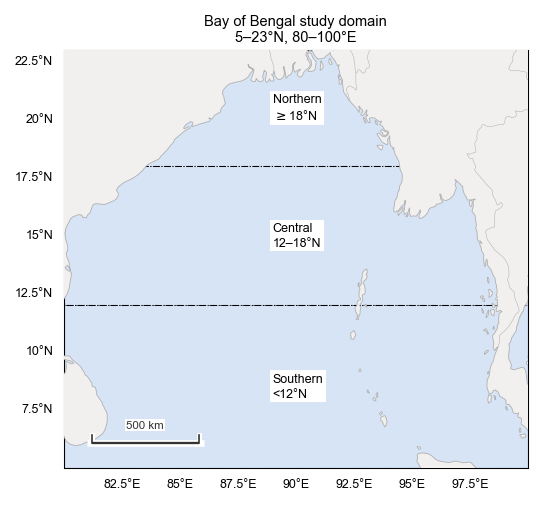

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 39 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'E', 'N', 'Y', 'a', 'c', 'colon', 'comma', 'degree', 'e', 'eight', 'equal', 'f', 'five', 'four', 'g', 'glyph00001', 'glyph00002', 'h', 'i', 'k', 'l', 'm', 'n', 'nine', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 15, 17, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 32, 36, 40, 4

   saved: fig27_argo_locations.png, fig27_argo_locations.eps (2.8 MB)


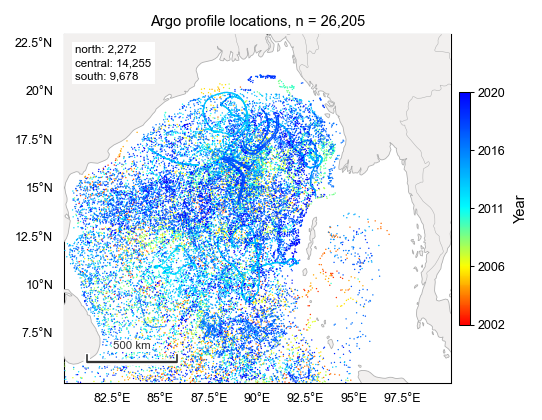

profiles per sub-basin:
  north     2,272  ( 8.7%)
  central  14,255  (54.4%)
  south     9,678  (36.9%)

A small northern share is expected and is the observational basis
for the spatial caveat on the validation and attribution results.


In [175]:
# ================= FINAL MAPS: study area and Argo coverage ===============
# Two standalone figures. The study-area map normally opens the Methods
# chapter; the Argo map belongs with the validation.

from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Light solid tints rather than alpha: PostScript has no alpha channel, so a
# transparent fill would flatten differently in the EPS than in the PNG.
BASIN_TINT = {"north": "#f7d4d4", "central": "#d8ecd8", "south": "#d6e4f5"}
BASIN_EDGE = {"north": "#d62728", "central": "#2ca02c", "south": "#1f77b4"}
BASIN_BOUNDS = {"north":   (LAT_N_MIN, LAT_MAX),
                "central": (LAT_C_MIN, LAT_N_MIN),
                "south":   (LAT_MIN,   LAT_C_MIN)}
BASIN_DESC = {"north":   f"Northern\n$\\geq${LAT_N_MIN:.0f}°N",
              "central": f"Central\n{LAT_C_MIN:.0f}–{LAT_N_MIN:.0f}°N",
              "south":   f"Southern\n<{LAT_C_MIN:.0f}°N"}

# Ganges-Brahmaputra-Meghna mouth, the dominant freshwater source
GBM_MOUTH = (89.6, 21.8)

# ---------------------------------------------------------------- figure 26
fig, axes = map_axes(1, 1, figsize=(COL1, COL1*1.02))
ax = axes[0, 0]
tkw = {"transform": ccrs.PlateCarree()} if HAS_CARTOPY else {}

for name, (y0, y1) in BASIN_BOUNDS.items():
    ax.add_patch(Rectangle((LON_MIN, y0), LON_MAX-LON_MIN, y1-y0,
                           facecolor="#d6e4f5", edgecolor="black",
                           linestyle="-.", linewidth=0.5,
                           zorder=1, **tkw))
    # ax.plot([LON_MIN, LON_MAX], [y0, y0], color="#555555", lw=0.6, ls="--",
    #         zorder=5, **tkw)
    ax.text(LON_MIN+9, 0.5*(y0+y1), BASIN_DESC[name], fontsize=6,
            va="center", ha="left", color="black",
            zorder=6, linespacing=1.3,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.2), **tkw)

# ax.plot(*GBM_MOUTH, marker="s", ms=1, color="#333333", zorder=6, **tkw)
# ax.text(GBM_MOUTH[0]+0.5, GBM_MOUTH[1], "Bangladesh", fontsize=5.5,
#         va="center", ha="left", color="#333333", zorder=6,
#         bbox=dict(facecolor="white", edgecolor="none", pad=0.8), **tkw)

style_map(ax)
annotate_map(ax)
ax.set_title(f"Bay of Bengal study domain\n{LAT_MIN:.0f}–{LAT_MAX:.0f}°N, "
             f"{LON_MIN:.0f}–{LON_MAX:.0f}°E", pad=4)
# ax.legend(handles=[Line2D([0], [0], marker="s", ls="none", ms=5,
#                           markerfacecolor=BASIN_TINT[b],
#                           markeredgecolor=BASIN_EDGE[b], label=b)
#                    for b in ["north", "central", "south"]],
#           loc="lower right", frameon=True, framealpha=1.0,
#           facecolor="white", edgecolor="none", title="Sub-basin",
#           title_fontsize=5.5, fontsize=5.5)
save_fig(fig, "fig26_study_area")
plt.show()

# ---------------------------------------------------------------- figure 27
_src = None
for _cand in ("m", "argo"):
    if _cand in dir() and isinstance(eval(_cand), pd.DataFrame):
        _src = eval(_cand); break

if _src is None or not {"lat", "lon"} <= set(_src.columns):
    print("no Argo table in memory; run the Argo sections first")
else:
    prof = _src.dropna(subset=["lat", "lon"]).copy()
    yrs = pd.to_datetime(prof["time"]).dt.year if "time" in prof else None

    fig, axes = map_axes(1, 1, figsize=(COL1, COL1*1.02))
    ax = axes[0, 0]
    # for name, (y0, y1) in BASIN_BOUNDS.items():
    #     ax.plot([LON_MIN, LON_MAX], [y0, y0], color="#888888", lw=0.5,
    #             ls="--", zorder=5, **tkw)

    if yrs is not None:
        sc = ax.scatter(prof["lon"], prof["lat"], c=yrs, cmap=CMAP_SEQ, s=0.45,
                        linewidths=0, zorder=4, rasterized=True, **tkw)
        cb = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.7, fraction=0.03)
        tidy_cbar(cb, "Year", fmt="%.0f")
    else:
        ax.scatter(prof["lon"], prof["lat"], c="#1f77b4", s=1,
                   linewidths=0, zorder=4, rasterized=True, **tkw)

    style_map(ax)
    annotate_map(ax)
    counts = {b: int(((prof.lat >= y0) & (prof.lat < y1)).sum())
              for b, (y0, y1) in BASIN_BOUNDS.items()}
    ax.set_title(f"Argo profile locations, n = {len(prof):,}", pad=4)
    # upper left: the lower left is taken by the scale bar
    ax.text(0.03, 0.97,
            "\n".join(f"{b}: {c:,}" for b, c in counts.items()),
            transform=ax.transAxes, va="top", ha="left", fontsize=5.5,
            linespacing=1.4, zorder=7,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
    save_fig(fig, "fig27_argo_locations")
    plt.show()

    total = sum(counts.values()) or 1
    print("profiles per sub-basin:")
    for b, c in counts.items():
        print(f"  {b:<8} {c:>6,}  ({100*c/total:4.1f}%)")
    print("\nA small northern share is expected and is the observational basis")
    print("for the spatial caveat on the validation and attribution results.")